## Real-Time Bitcoin Price Analysis
This notebook fetches real-time Bitcoin price data from the internet and shows it in a live dashboard. 

It does the following:

`Cell 1 - Importing Libraries and Setting Plot Style`

In [2]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from matplotlib import rcParams
from datetime import datetime
import time
import statistics
from statsmodels.tsa.arima.model import ARIMA

# Plot styling
plt.style.use('seaborn-v0_8-darkgrid')
rcParams['axes.titlesize'] = 16
rcParams['axes.labelsize'] = 12
rcParams['lines.linewidth'] = 2
rcParams['legend.fontsize'] = 10
rcParams['figure.figsize'] = (14, 8)
rcParams['xtick.labelsize'] = 10
rcParams['ytick.labelsize'] = 10
rcParams['figure.facecolor'] = '#f5f5f5'
rcParams['axes.facecolor'] = '#ffffff'


## Cell 1 : This cell prepares all the tools required for real-time data collection, analysis, visualization, and forecasting.

 What’s imported:

`requests:` For sending HTTP requests to fetch live Bitcoin data from the CoinGecko API.

`pandas:` Used for storing and manipulating time series data (used by ARIMA).

`matplotlib.pyplot:` To create and update live plots (line chart for price, bar chart for volume).

`datetime, time:` To timestamp data and control the 60-second loop delay.

`statistics:` For calculating rolling averages and volatility.

`ARIMA from statsmodels:` A statistical model used for short-term price prediction.

`matplotlib.dates and ticker:` To format the axes in the charts (clean time labels and Y-axis values).

Why style settings?
We configure matplotlib.rcParams and apply a seaborn-darkgrid style to make the visuals cleaner, easier to read, and professional-looking for dashboard-style plots.

In [4]:
# Data buffers
time_marks = []
values_usd = []
volumes_usd = []
price_deltas = []

def retrieve_btc_snapshot():
    """Call CoinGecko API for live BTC price data."""
    endpoint = 'https://api.coingecko.com/api/v3/coins/bitcoin'
    params = {
        'localization': 'false',
        'tickers': 'false',
        'community_data': 'false',
        'developer_data': 'false'
    }
    try:
        reply = requests.get(endpoint, params=params)
        if reply.status_code == 200:
            payload = reply.json()['market_data']
            return {
                'recorded_time': datetime.utcnow(),
                'usd_value': payload['current_price']['usd'],
                'daily_volume': payload['total_volume']['usd'],
                'pct_shift_24h': payload['price_change_percentage_24h']
            }
        else:
            print(f"API Error: {reply.status_code}")
    except Exception as err:
        print("Fetch error:", err)
    return None


## Cell 2 – API Function and Data Buffers`
 Data Buffers:
`time_marks:` Stores the timestamps for each price point.

`values_usd:` Stores the price of Bitcoin in USD.

`volumes_usd:` Stores the 24-hour trading volume.

`price_deltas:` Stores the 24h percentage price change.

These lists grow over time as new data is collected every 60 seconds.

 API Function (retrieve_btc_snapshot()):
This function connects to the CoinGecko API and requests current market data for Bitcoin.

The function returns a dictionary containing:

`recorded_time:` Current timestamp when the data is fetched.

`usd_value:` Current BTC price in USD.

`daily_volume:` Total volume of BTC traded in the past 24 hours (USD value).

`pct_shift_24h:` Percentage change in price over the last 24 hours.

This function is modular and reusable — it isolates the API logic cleanly from the rest of the code.

/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/321638620.py:21: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'recorded_time': datetime.utcnow(),
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:45: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.pause(0.1)
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:45: U

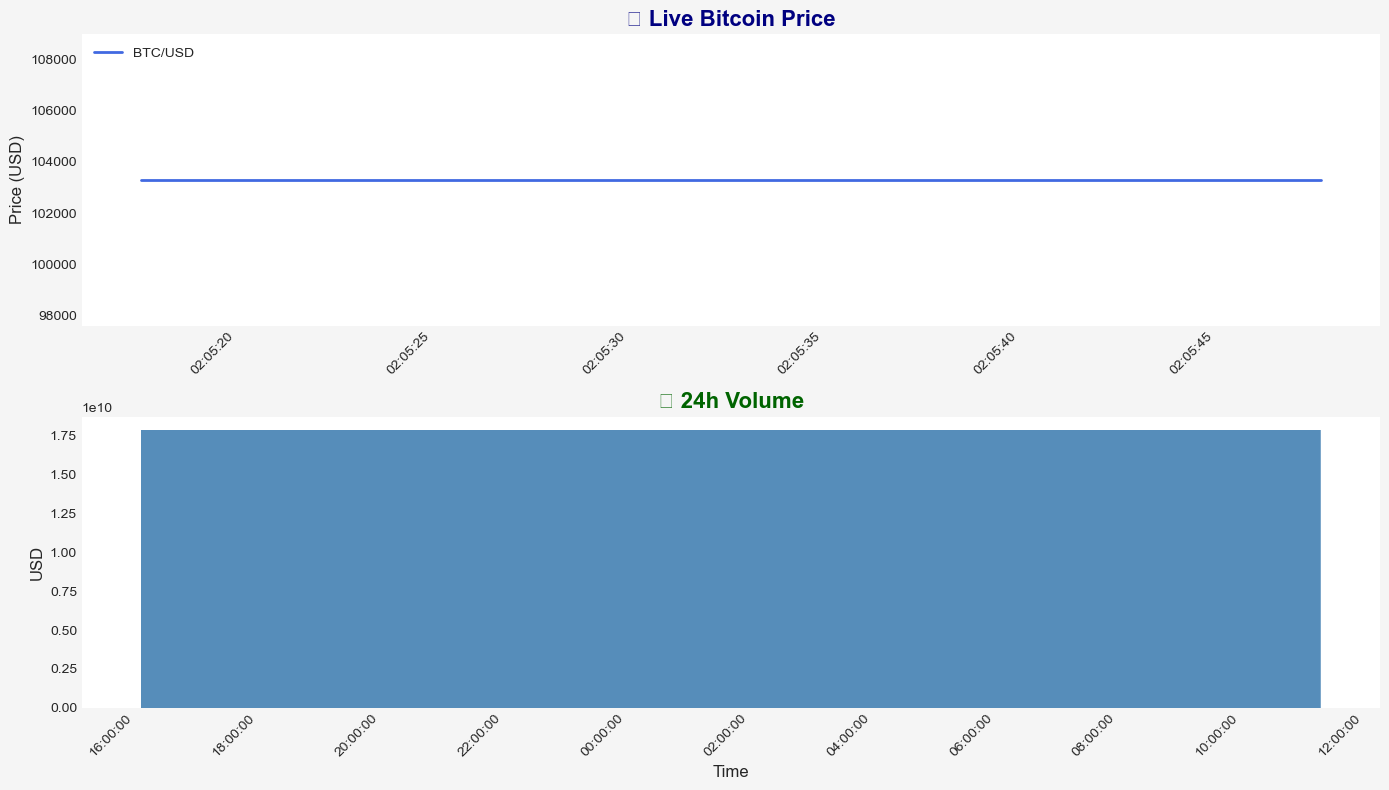


Analysis (2025-05-17 22:05:50)
Current Price: $103,291.00
5-point MA: $103,291.00
15-point MA: $103,291.00
30-point MA: $103,291.00
Volatility: 0.00
[22:05:50] Price: $103,291.00, Volatility: 0.00


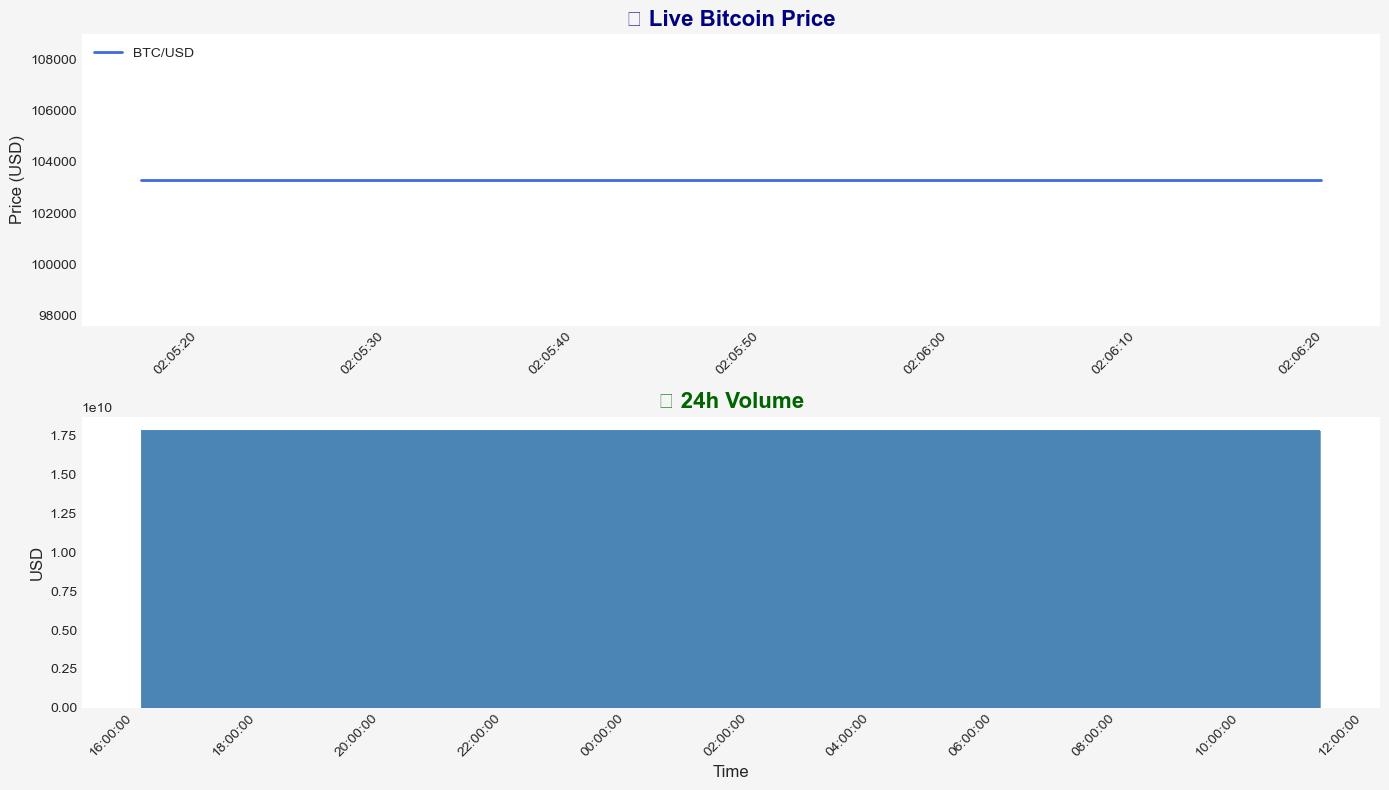


Analysis (2025-05-17 22:06:23)
Current Price: $103,291.00
5-point MA: $103,291.00
15-point MA: $103,291.00
30-point MA: $103,291.00
Volatility: 0.00
[22:06:23] Price: $103,291.00, Volatility: 0.00


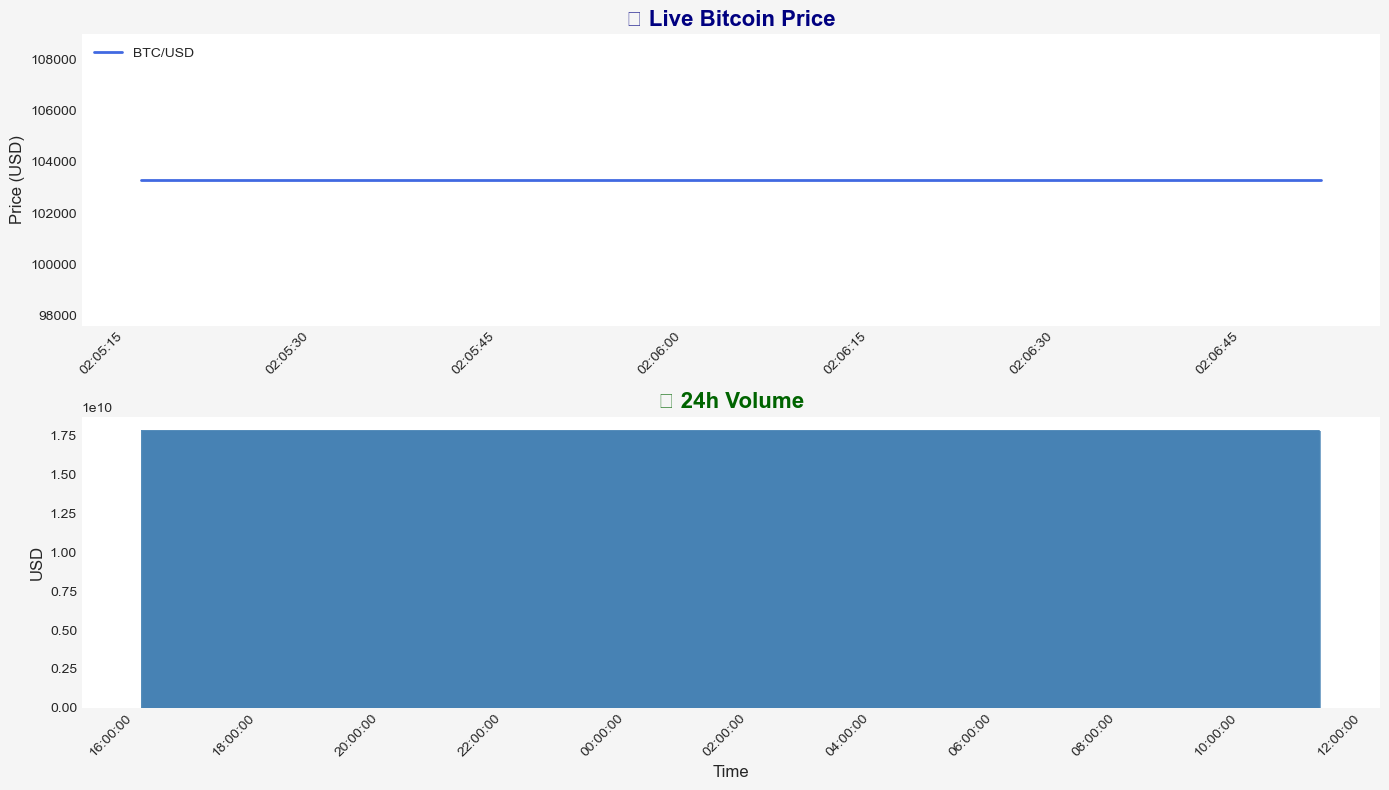


Analysis (2025-05-17 22:06:54)
Current Price: $103,291.00
5-point MA: $103,291.00
15-point MA: $103,291.00
30-point MA: $103,291.00
Volatility: 0.00
[22:06:54] Price: $103,291.00, Volatility: 0.00


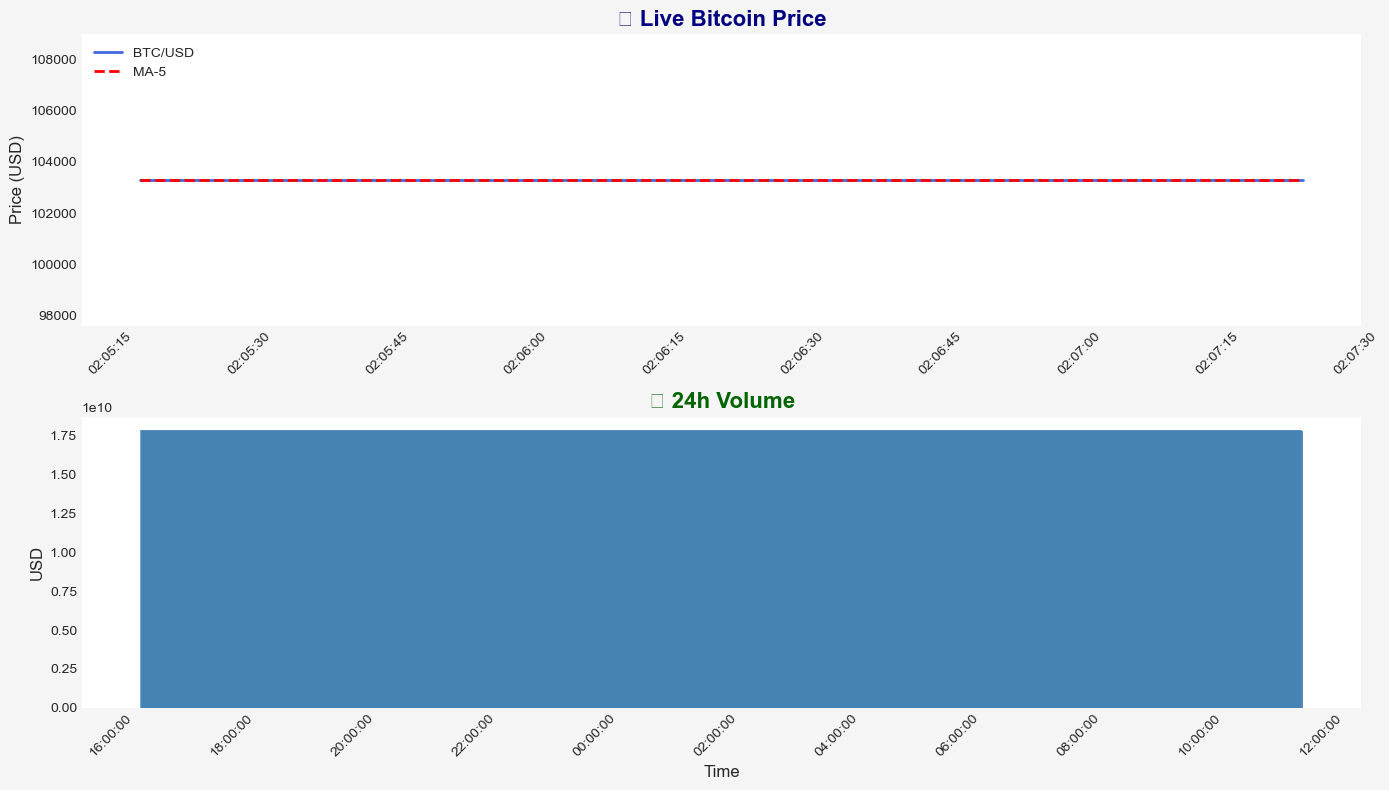


Analysis (2025-05-17 22:07:25)
Current Price: $103,291.00
5-point MA: $103,291.00
15-point MA: $103,291.00
30-point MA: $103,291.00
Volatility: 0.00
[22:07:25] Price: $103,291.00, Volatility: 0.00
[ARIMA Forecast] Next 3 BTC Prices: $103,291.00, $103,291.00, $103,291.00


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/321638620.py:21: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'recorded_time': datetime.utcnow(),
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz8000

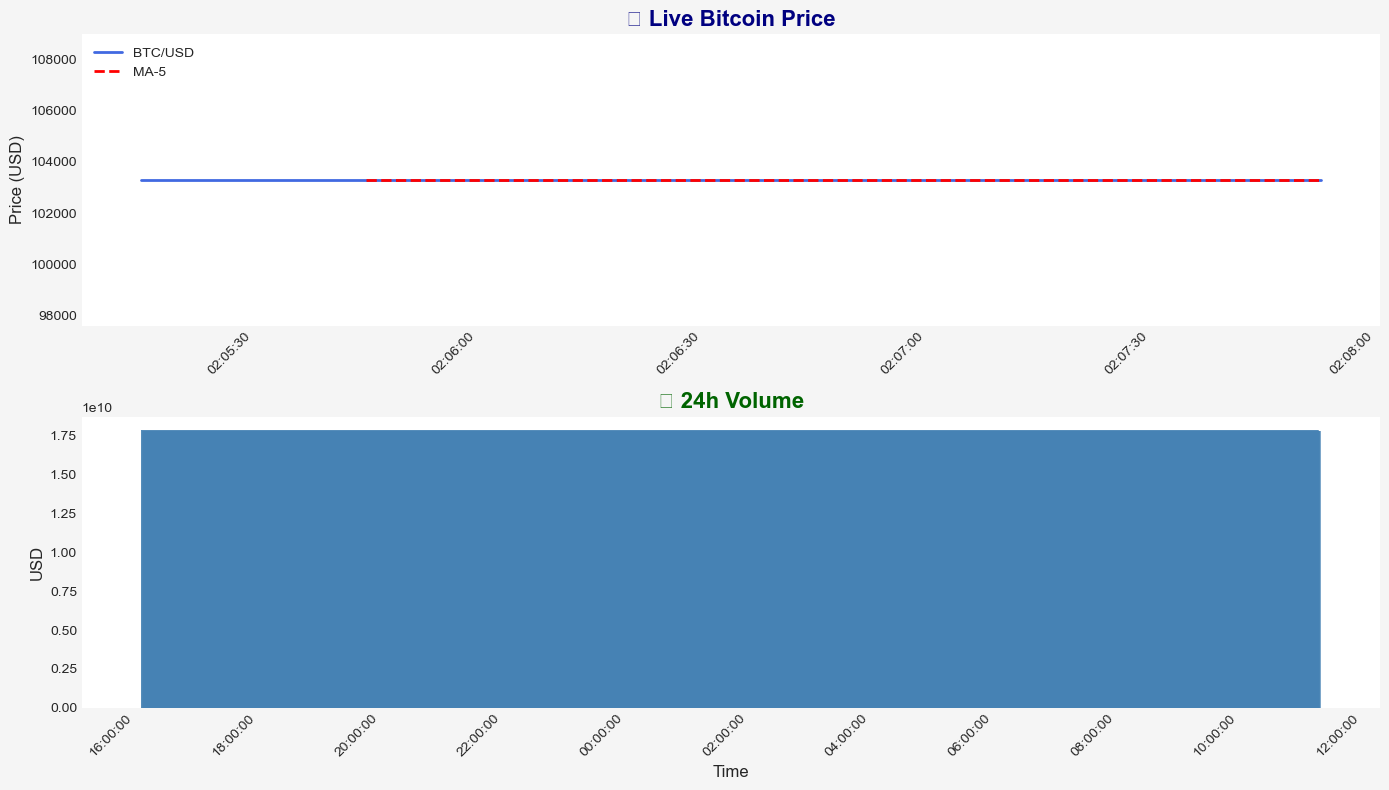


Analysis (2025-05-17 22:07:56)
Current Price: $103,291.00
5-point MA: $103,291.00
15-point MA: $103,291.00
30-point MA: $103,291.00
Volatility: 0.00
[22:07:56] Price: $103,291.00, Volatility: 0.00
[ARIMA Forecast] Next 3 BTC Prices: $103,291.00, $103,291.00, $103,291.00


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/321638620.py:21: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'recorded_time': datetime.utcnow(),
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz8000

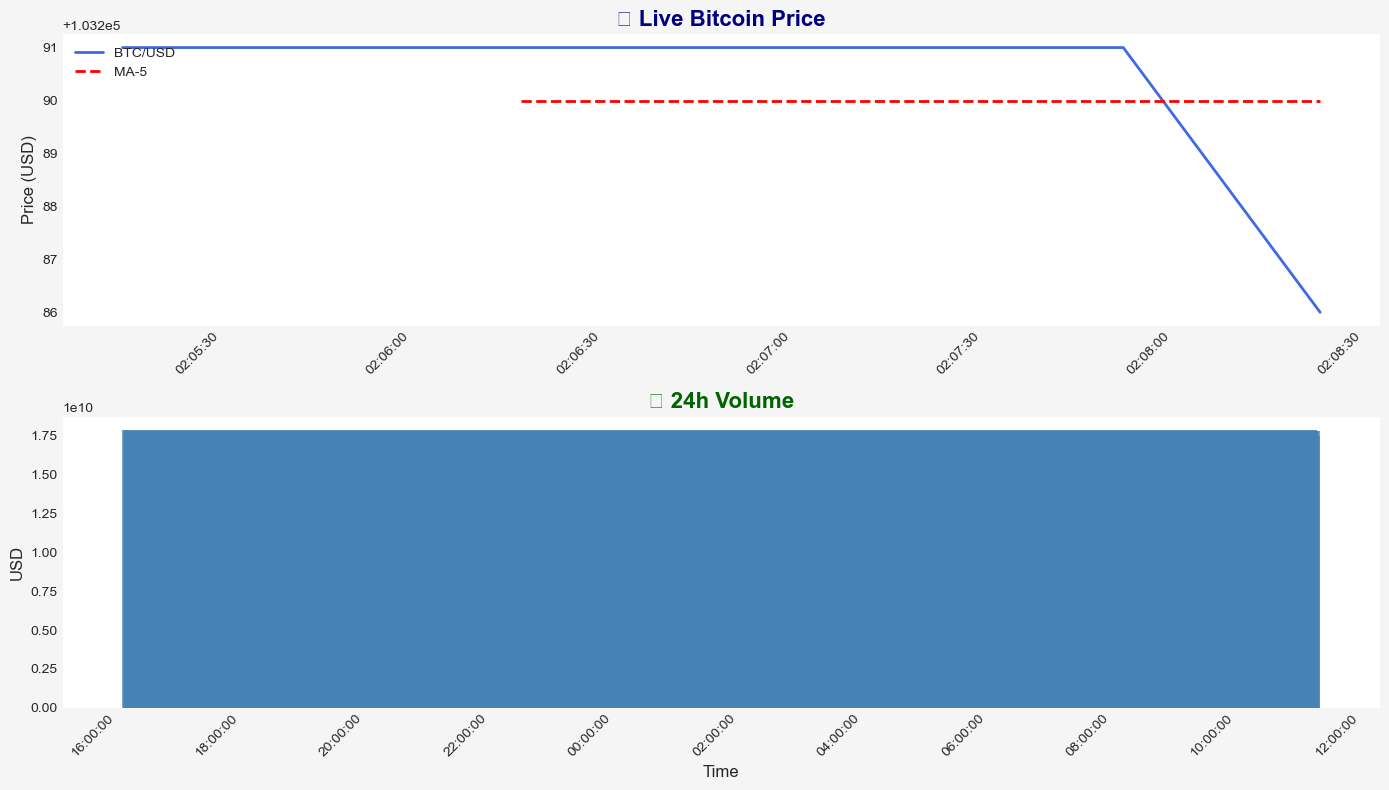


Analysis (2025-05-17 22:08:27)
Current Price: $103,286.00
5-point MA: $103,290.00
15-point MA: $103,286.00
30-point MA: $103,286.00
Volatility: 0.00
[22:08:27] Price: $103,286.00, Volatility: 0.00
[ARIMA Forecast] Next 3 BTC Prices: $103,286.00, $103,286.00, $103,286.00


/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/321638620.py:21: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'recorded_time': datetime.utcnow(),
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:45: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.pause(0.1)
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:45: U

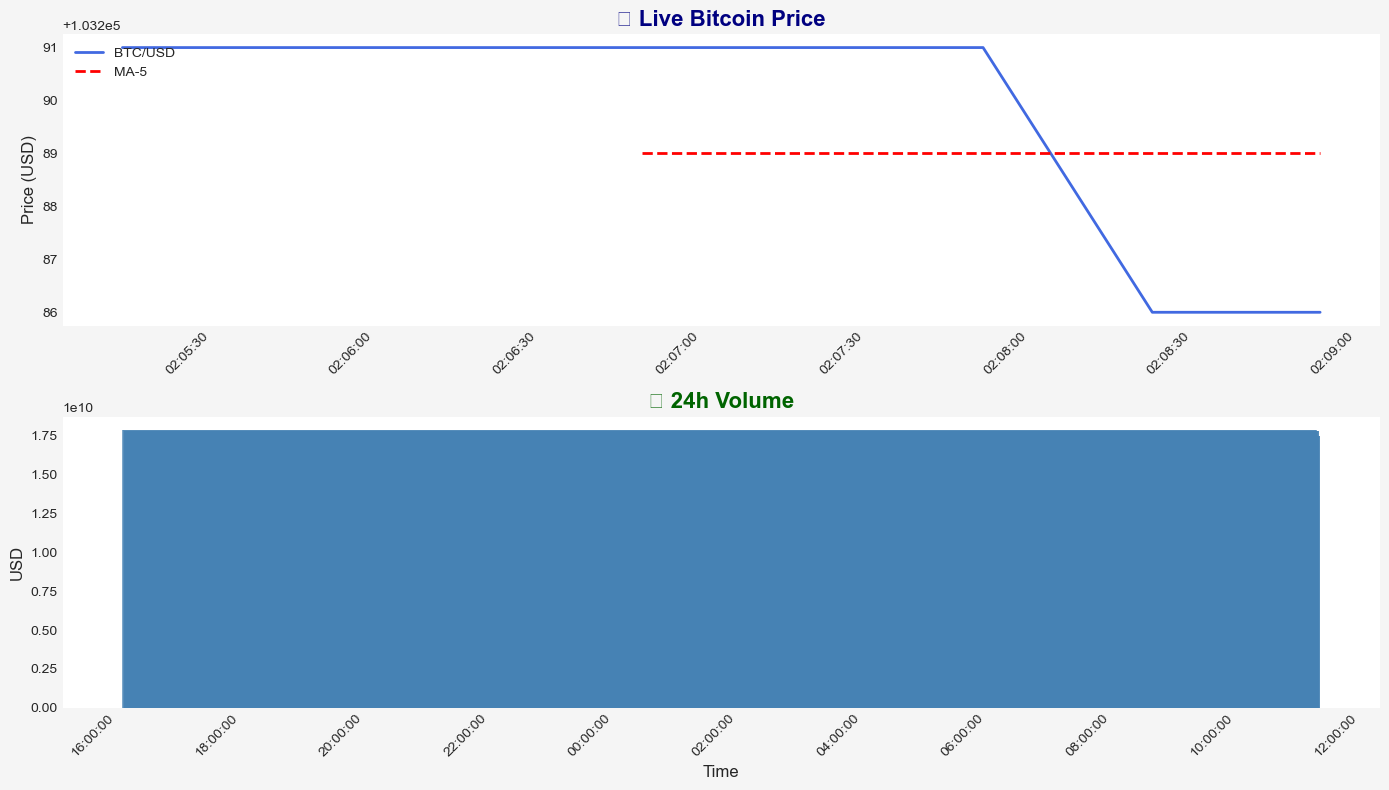


Analysis (2025-05-17 22:08:58)
Current Price: $103,286.00
5-point MA: $103,289.00
15-point MA: $103,286.00
30-point MA: $103,286.00
Volatility: 0.00
[22:08:58] Price: $103,286.00, Volatility: 0.00
[ARIMA Forecast] Next 3 BTC Prices: $103,286.00, $103,286.00, $103,286.00


/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/321638620.py:21: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'recorded_time': datetime.utcnow(),
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:45: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.pause(0.1)
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:45: U

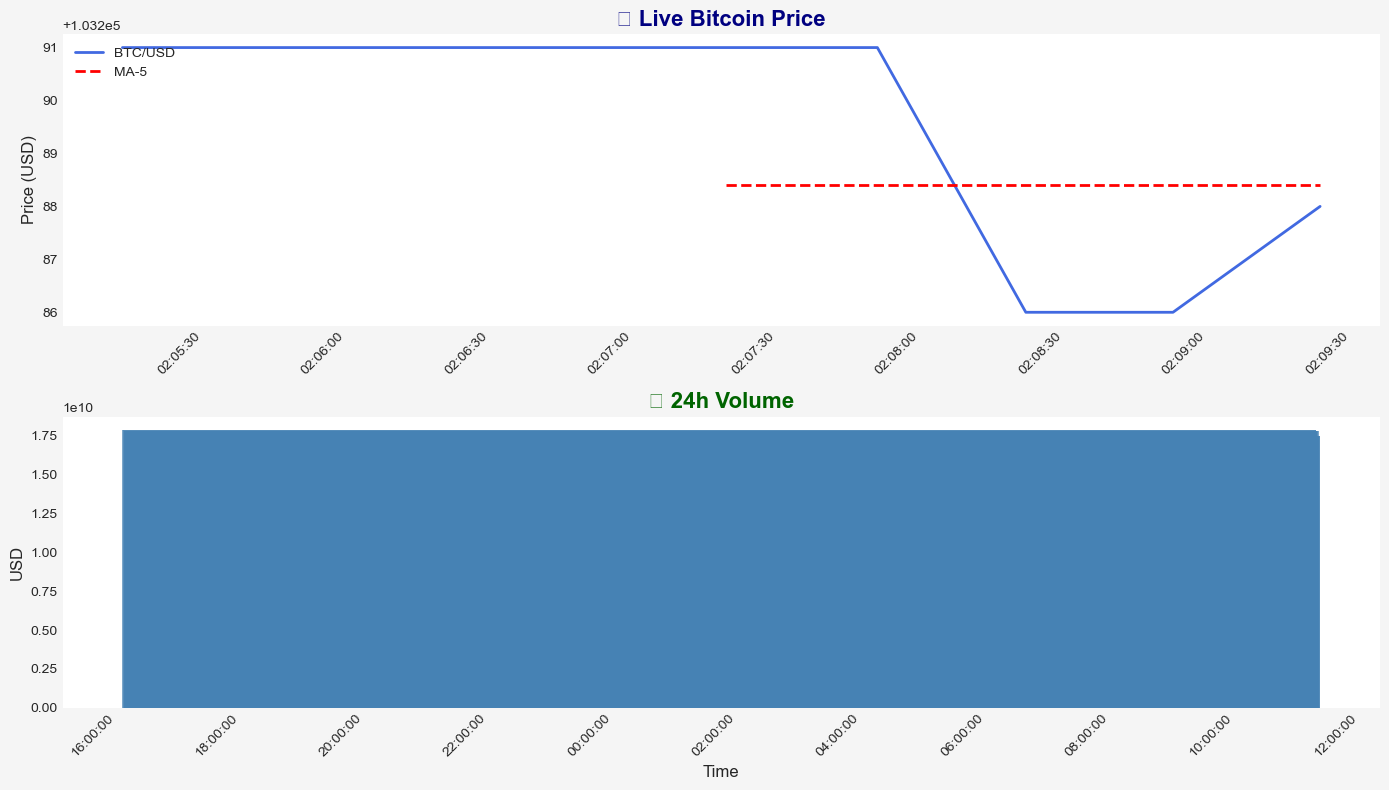


Analysis (2025-05-17 22:09:29)
Current Price: $103,288.00
5-point MA: $103,288.40
15-point MA: $103,288.00
30-point MA: $103,288.00
Volatility: 0.00
[22:09:29] Price: $103,288.00, Volatility: 0.00
[ARIMA Forecast] Next 3 BTC Prices: $103,288.00, $103,288.00, $103,288.00


/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/321638620.py:21: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'recorded_time': datetime.utcnow(),
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:45: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.pause(0.1)
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:45: U

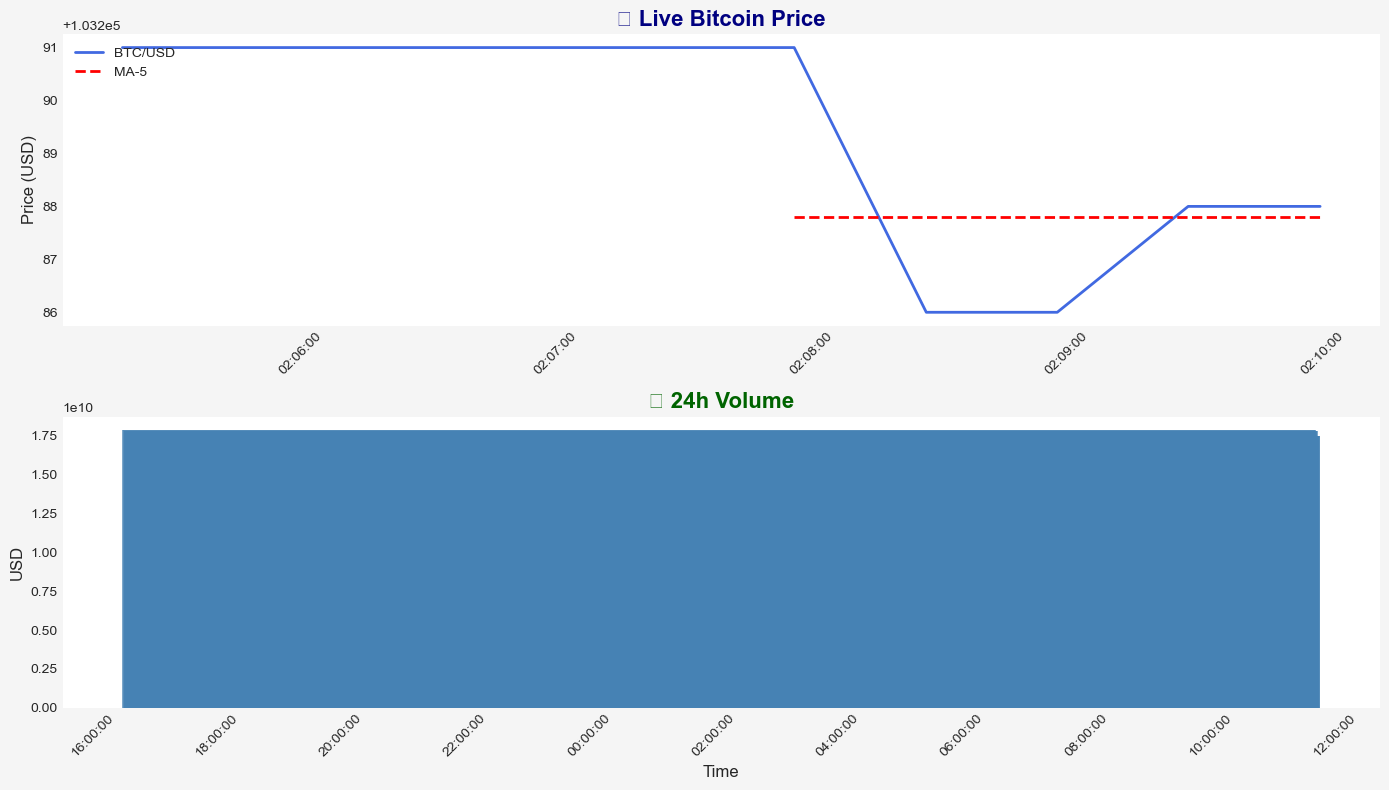


Analysis (2025-05-17 22:10:00)
Current Price: $103,288.00
5-point MA: $103,287.80
15-point MA: $103,288.00
30-point MA: $103,288.00
Volatility: 0.00
[22:10:00] Price: $103,288.00, Volatility: 0.00
[ARIMA Forecast] Next 3 BTC Prices: $103,288.00, $103,288.00, $103,288.00


/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/321638620.py:21: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'recorded_time': datetime.utcnow(),
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:45: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.pause(0.1)
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:45: U

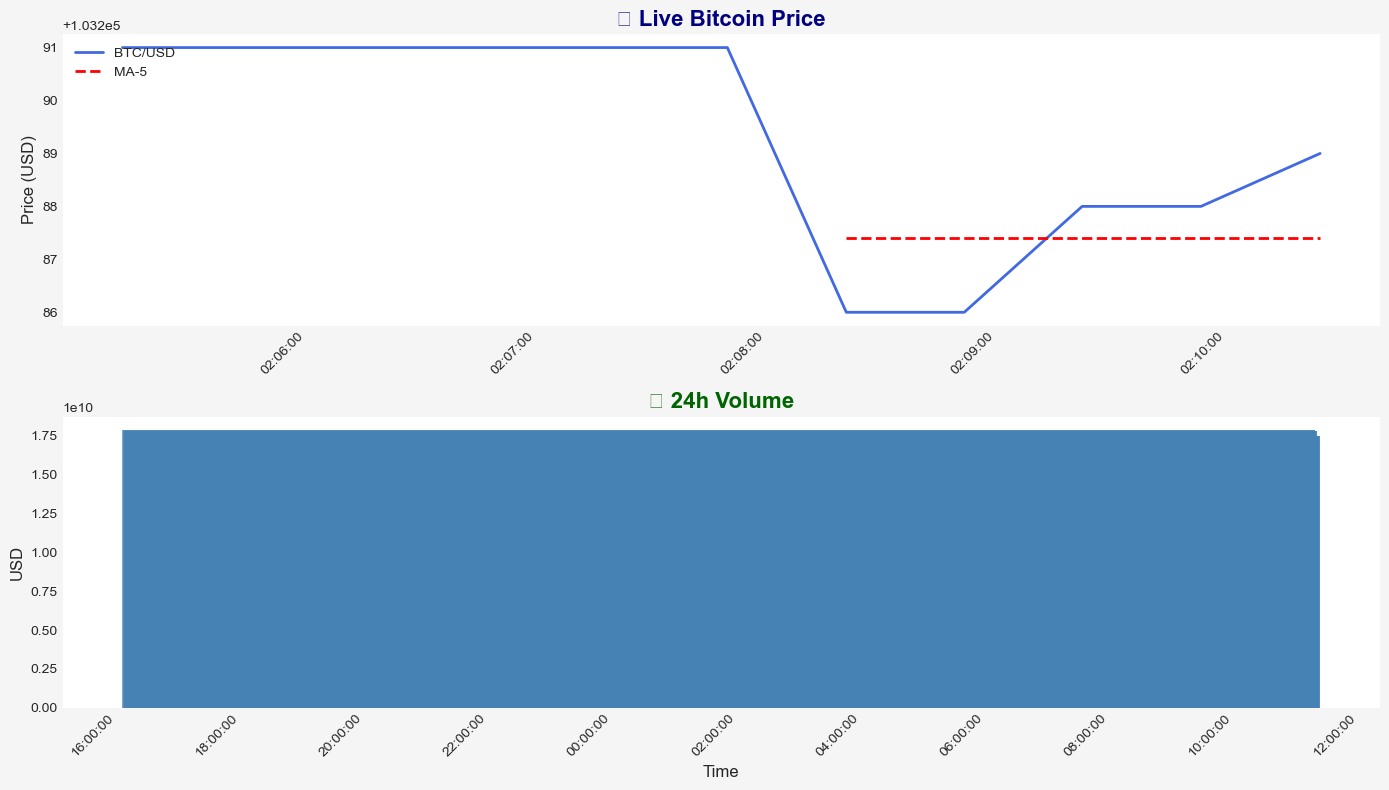


Analysis (2025-05-17 22:10:31)
Current Price: $103,289.00
5-point MA: $103,287.40
15-point MA: $103,289.00
30-point MA: $103,289.00
Volatility: 0.00
[22:10:31] Price: $103,289.00, Volatility: 0.00
[ARIMA Forecast] Next 3 BTC Prices: $103,289.00, $103,289.00, $103,289.00


/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/321638620.py:21: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'recorded_time': datetime.utcnow(),
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:45: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.pause(0.1)
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:45: U

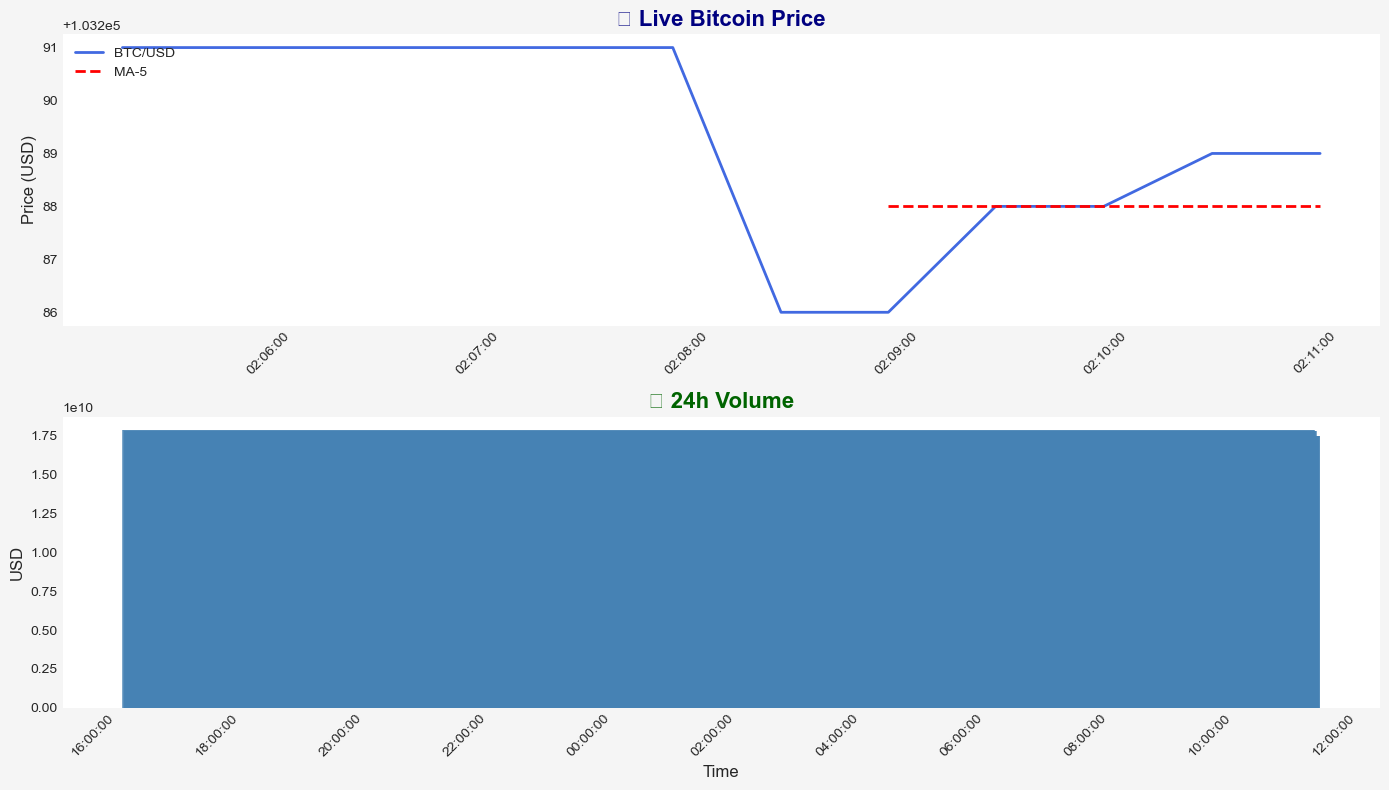


Analysis (2025-05-17 22:11:02)
Current Price: $103,289.00
5-point MA: $103,288.00
15-point MA: $103,289.00
30-point MA: $103,289.00
Volatility: 0.00
[22:11:02] Price: $103,289.00, Volatility: 0.00
[ARIMA Forecast] Next 3 BTC Prices: $103,289.00, $103,289.00, $103,289.00


/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/321638620.py:21: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'recorded_time': datetime.utcnow(),
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:45: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.pause(0.1)
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:45: U

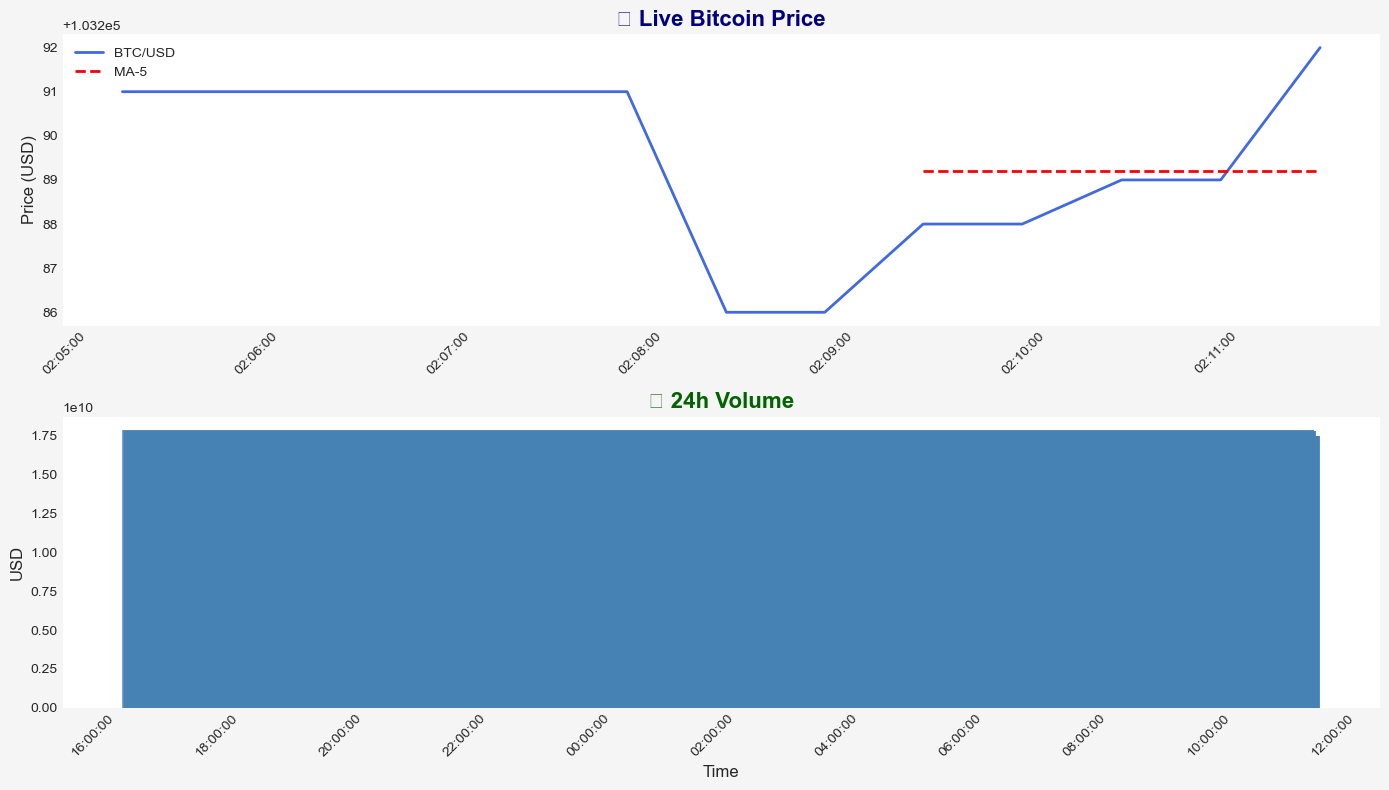


Analysis (2025-05-17 22:11:33)
Current Price: $103,292.00
5-point MA: $103,289.20
15-point MA: $103,292.00
30-point MA: $103,292.00
Volatility: 0.00
[22:11:33] Price: $103,292.00, Volatility: 0.00
[ARIMA Forecast] Next 3 BTC Prices: $103,292.00, $103,292.00, $103,292.00


/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/321638620.py:21: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'recorded_time': datetime.utcnow(),
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:45: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.pause(0.1)
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:45: U

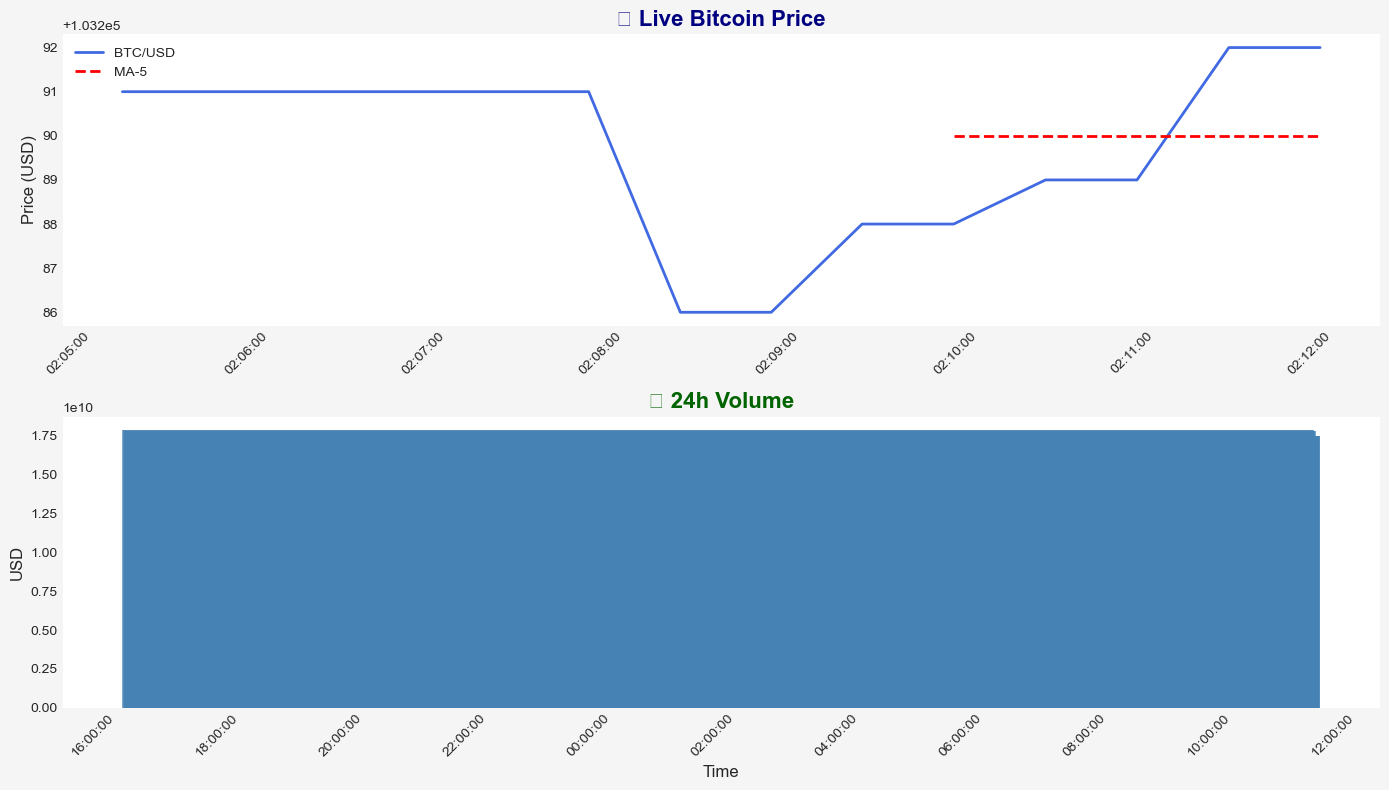


Analysis (2025-05-17 22:12:04)
Current Price: $103,292.00
5-point MA: $103,290.00
15-point MA: $103,292.00
30-point MA: $103,292.00
Volatility: 0.00
[22:12:04] Price: $103,292.00, Volatility: 0.00
[ARIMA Forecast] Next 3 BTC Prices: $103,292.00, $103,292.00, $103,292.00


/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/321638620.py:21: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'recorded_time': datetime.utcnow(),
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:45: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.pause(0.1)
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:45: U

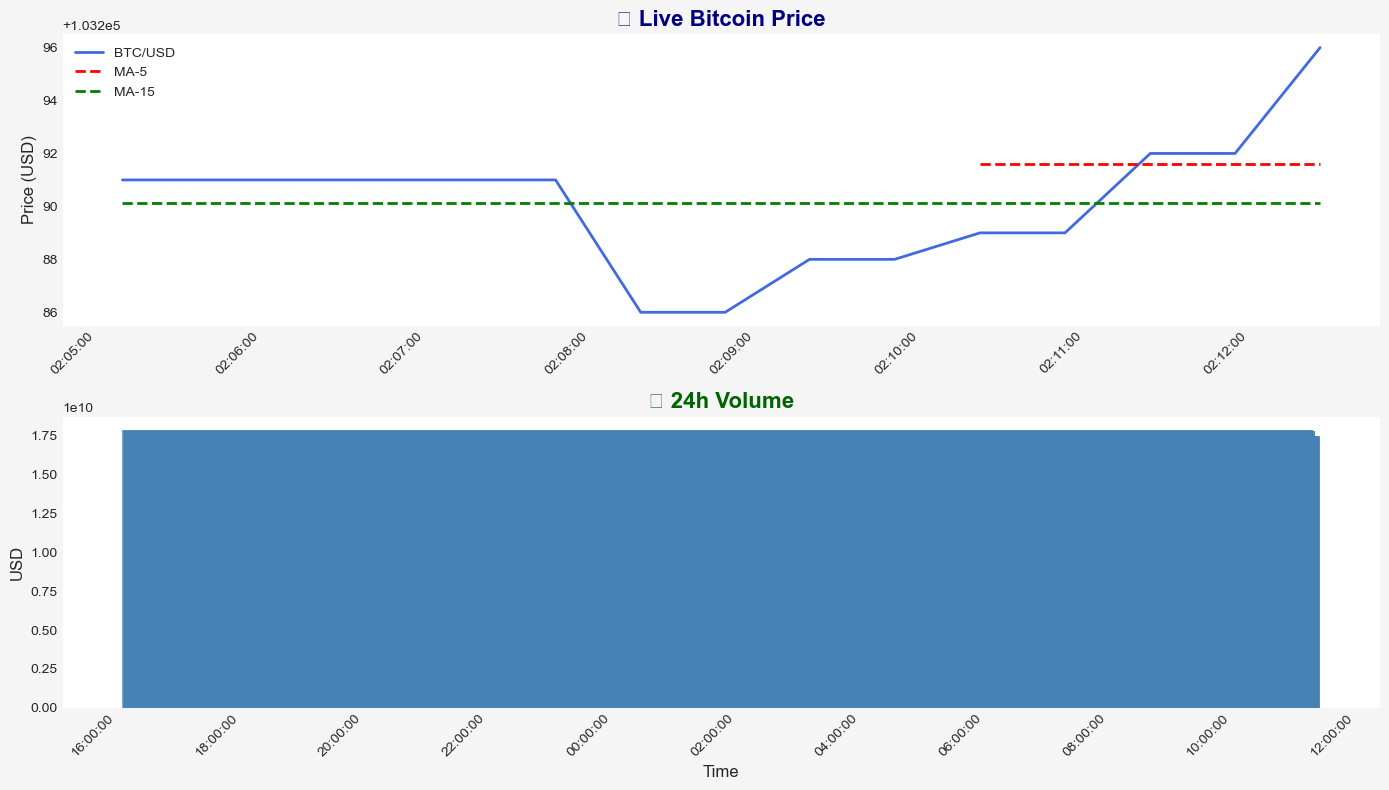


Analysis (2025-05-17 22:12:35)
Current Price: $103,296.00
5-point MA: $103,291.60
15-point MA: $103,290.13
30-point MA: $103,296.00
Volatility: 0.00
[22:12:35] Price: $103,296.00, Volatility: 0.00
[ARIMA Forecast] Next 3 BTC Prices: $103,296.00, $103,296.00, $103,296.00


/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/321638620.py:21: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'recorded_time': datetime.utcnow(),
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:45: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.pause(0.1)
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:45: U

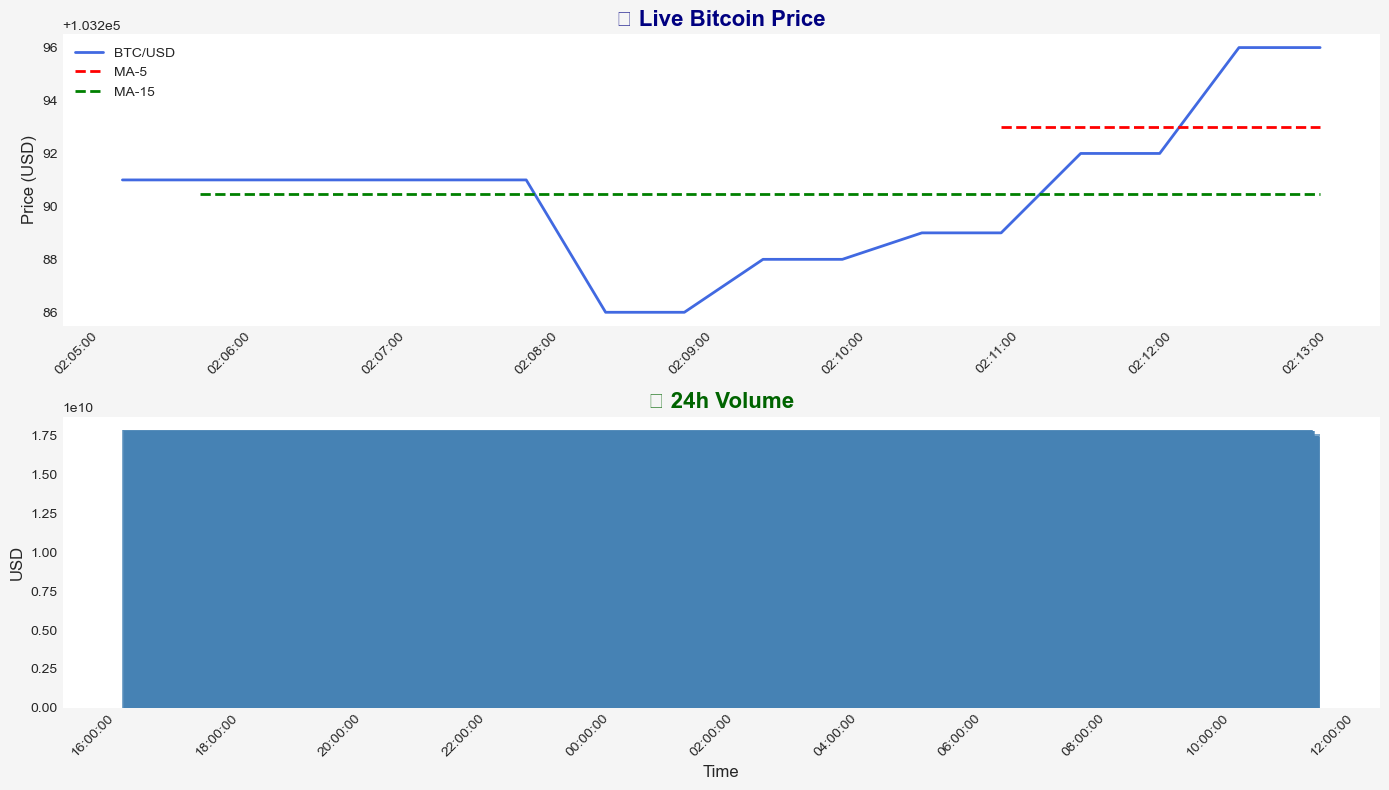


Analysis (2025-05-17 22:13:09)
Current Price: $103,296.00
5-point MA: $103,293.00
15-point MA: $103,290.47
30-point MA: $103,296.00
Volatility: 0.00
[22:13:09] Price: $103,296.00, Volatility: 0.00
[ARIMA Forecast] Next 3 BTC Prices: $103,296.00, $103,296.00, $103,296.00


/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/321638620.py:21: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'recorded_time': datetime.utcnow(),
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:45: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.pause(0.1)
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:45: U

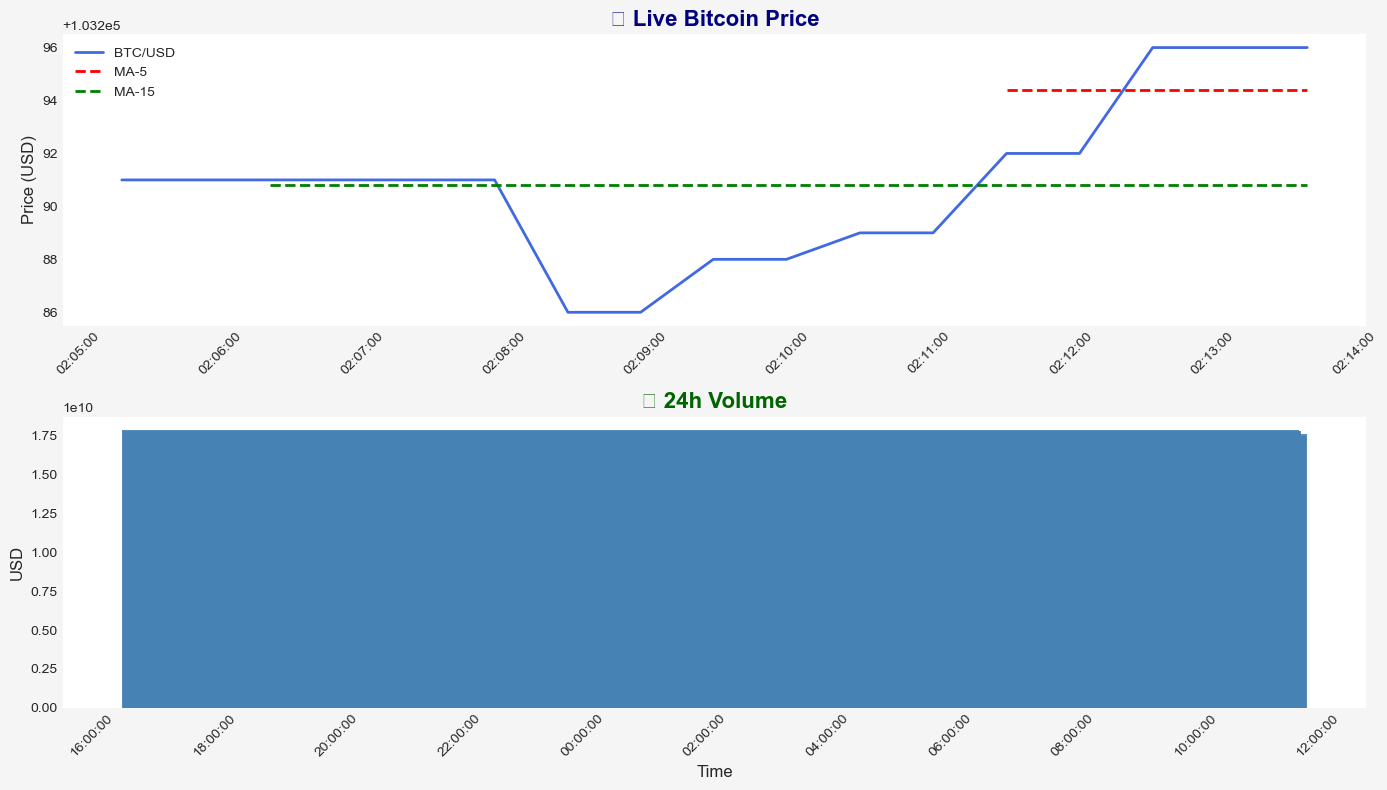


Analysis (2025-05-17 22:13:42)
Current Price: $103,296.00
5-point MA: $103,294.40
15-point MA: $103,290.80
30-point MA: $103,296.00
Volatility: 0.00
[22:13:42] Price: $103,296.00, Volatility: 0.00
[ARIMA Forecast] Next 3 BTC Prices: $103,296.00, $103,296.00, $103,296.00


/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/321638620.py:21: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'recorded_time': datetime.utcnow(),
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:45: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.pause(0.1)
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:45: U

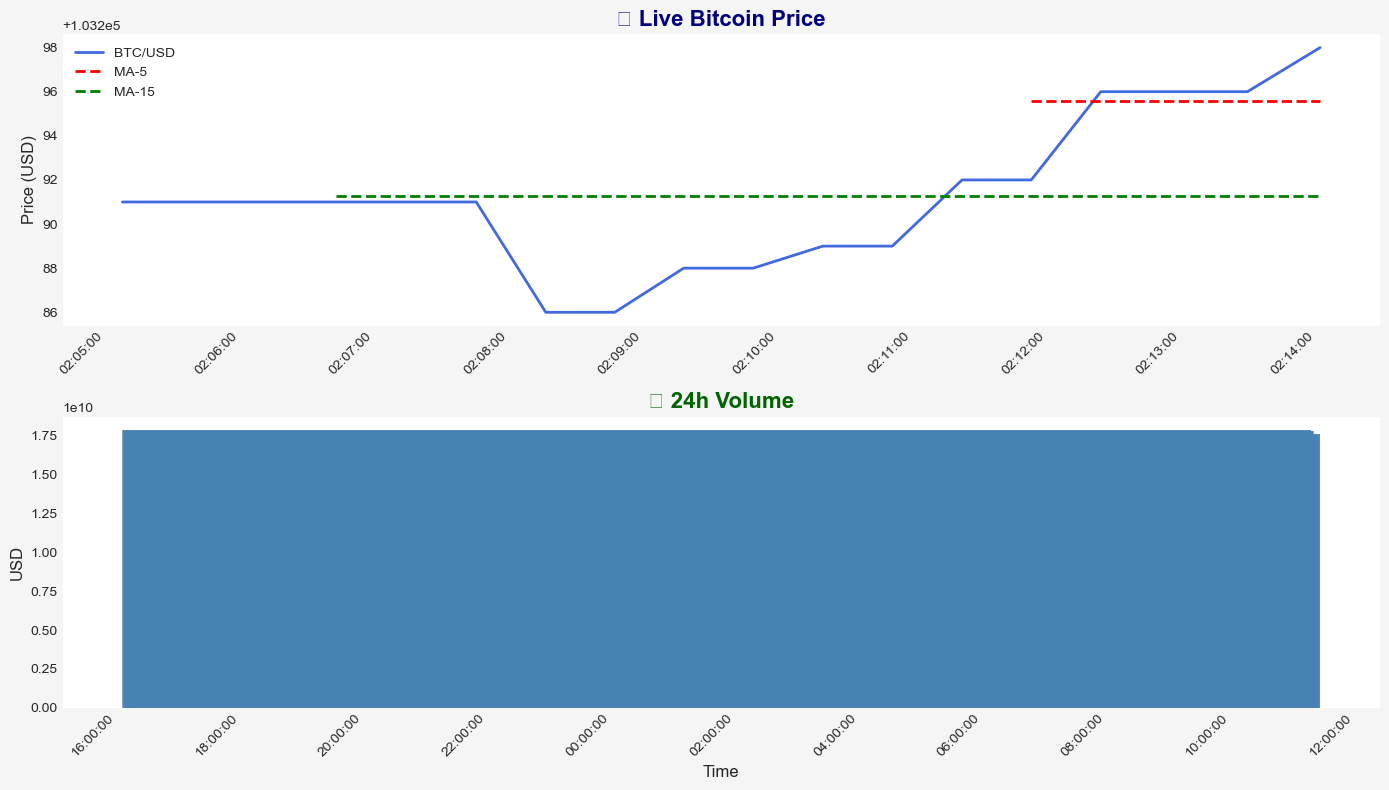


Analysis (2025-05-17 22:14:15)
Current Price: $103,298.00
5-point MA: $103,295.60
15-point MA: $103,291.27
30-point MA: $103,298.00
Volatility: 0.00
[22:14:15] Price: $103,298.00, Volatility: 0.00
[ARIMA Forecast] Next 3 BTC Prices: $103,298.00, $103,298.00, $103,298.00


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/321638620.py:21: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'recorded_time': datetime.utcnow(),
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
/

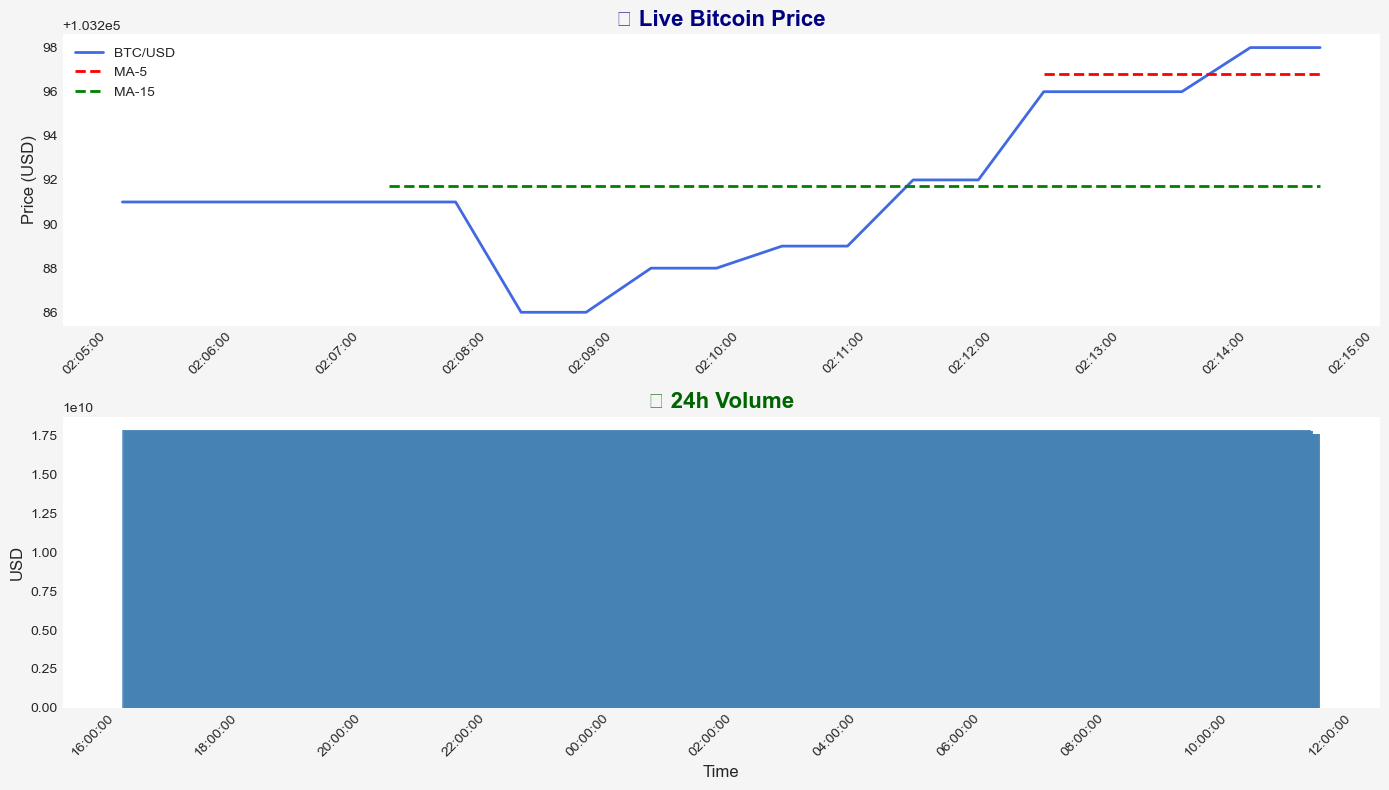


Analysis (2025-05-17 22:14:47)
Current Price: $103,298.00
5-point MA: $103,296.80
15-point MA: $103,291.73
30-point MA: $103,298.00
Volatility: 0.00
[22:14:47] Price: $103,298.00, Volatility: 0.00
[ARIMA Forecast] Next 3 BTC Prices: $103,298.00, $103,298.00, $103,298.00


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/321638620.py:21: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'recorded_time': datetime.utcnow(),
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
/

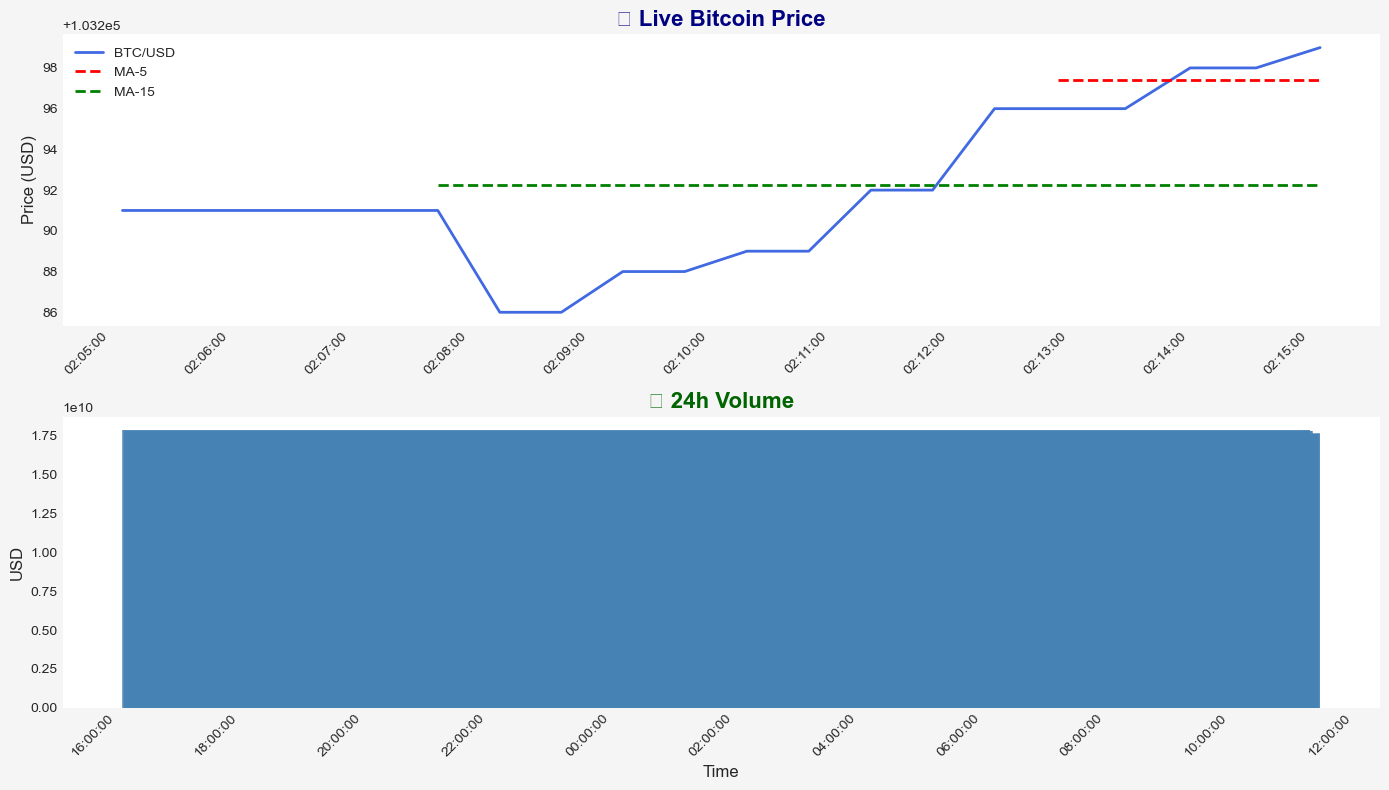


Analysis (2025-05-17 22:15:20)
Current Price: $103,299.00
5-point MA: $103,297.40
15-point MA: $103,292.27
30-point MA: $103,299.00
Volatility: 0.00
[22:15:20] Price: $103,299.00, Volatility: 0.00
[ARIMA Forecast] Next 3 BTC Prices: $103,299.24, $103,299.42, $103,299.57


/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/321638620.py:21: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'recorded_time': datetime.utcnow(),
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:45: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.pause(0.1)
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:45: U

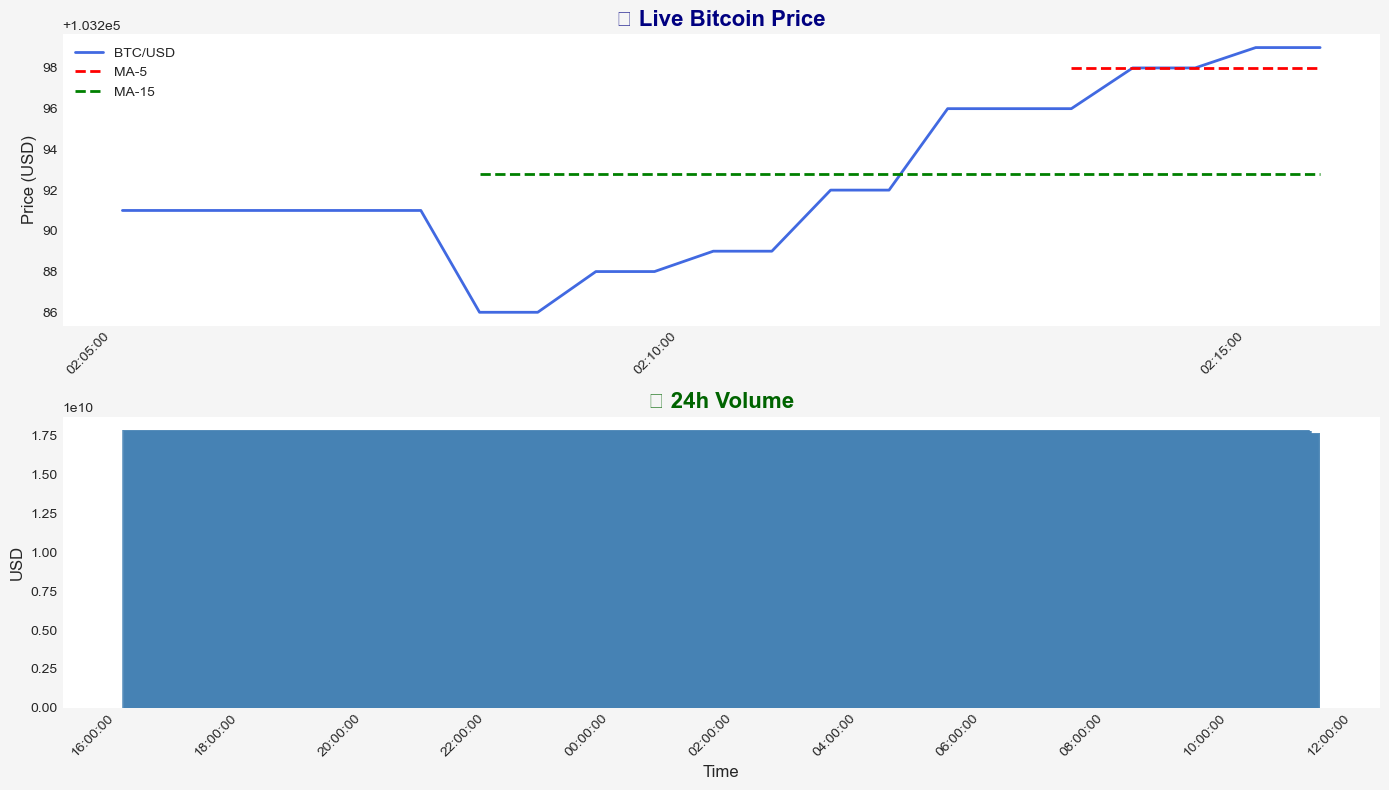


Analysis (2025-05-17 22:15:55)
Current Price: $103,299.00
5-point MA: $103,298.00
15-point MA: $103,292.80
30-point MA: $103,299.00
Volatility: 0.00
[22:15:55] Price: $103,299.00, Volatility: 0.00
[ARIMA Forecast] Next 3 BTC Prices: $103,299.16, $103,299.28, $103,299.37


/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/321638620.py:21: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'recorded_time': datetime.utcnow(),
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:45: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.pause(0.1)
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:45: U

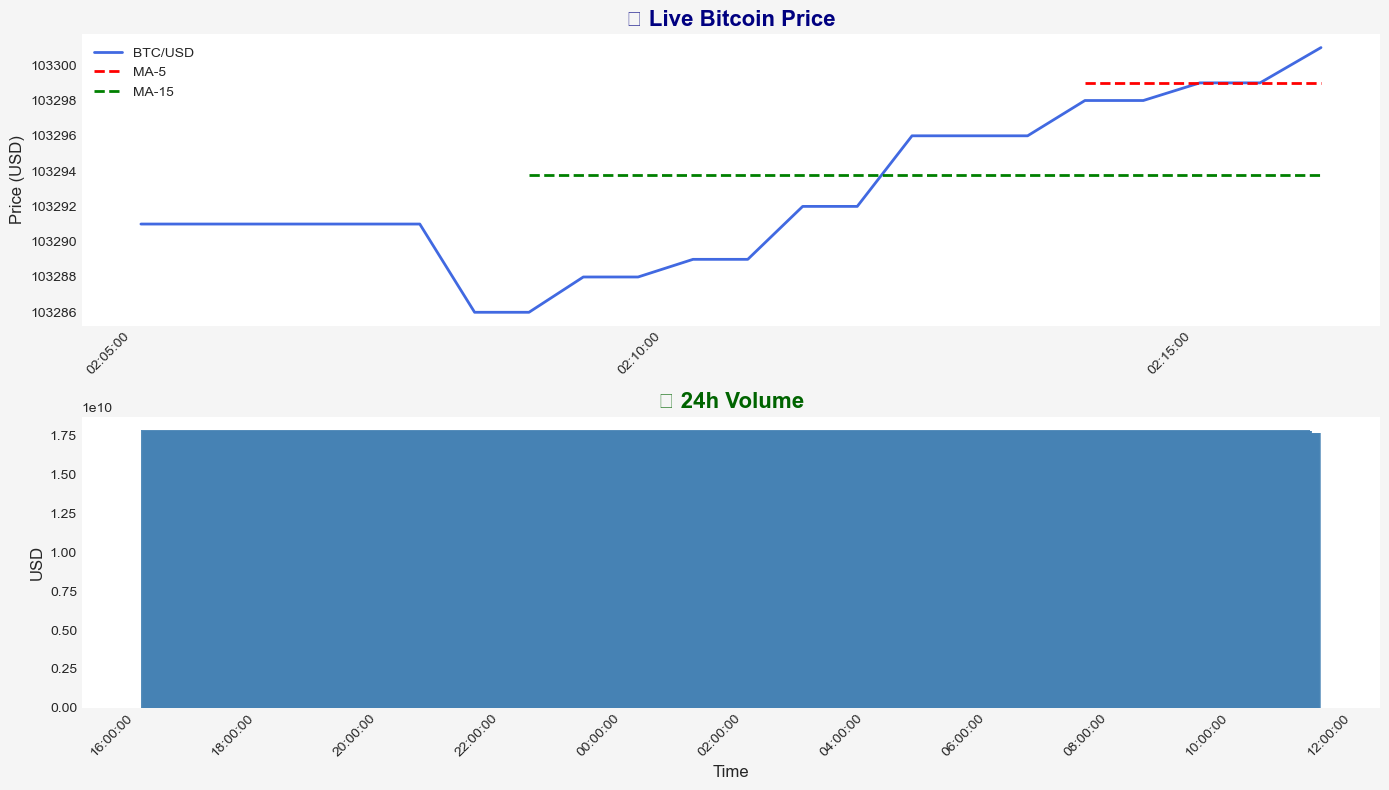


Analysis (2025-05-17 22:16:26)
Current Price: $103,301.00
5-point MA: $103,299.00
15-point MA: $103,293.80
30-point MA: $103,301.00
Volatility: 0.00
[22:16:26] Price: $103,301.00, Volatility: 0.00
[ARIMA Forecast] Next 3 BTC Prices: $103,301.37, $103,301.68, $103,301.95


/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/321638620.py:21: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'recorded_time': datetime.utcnow(),
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:45: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.pause(0.1)
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:45: U

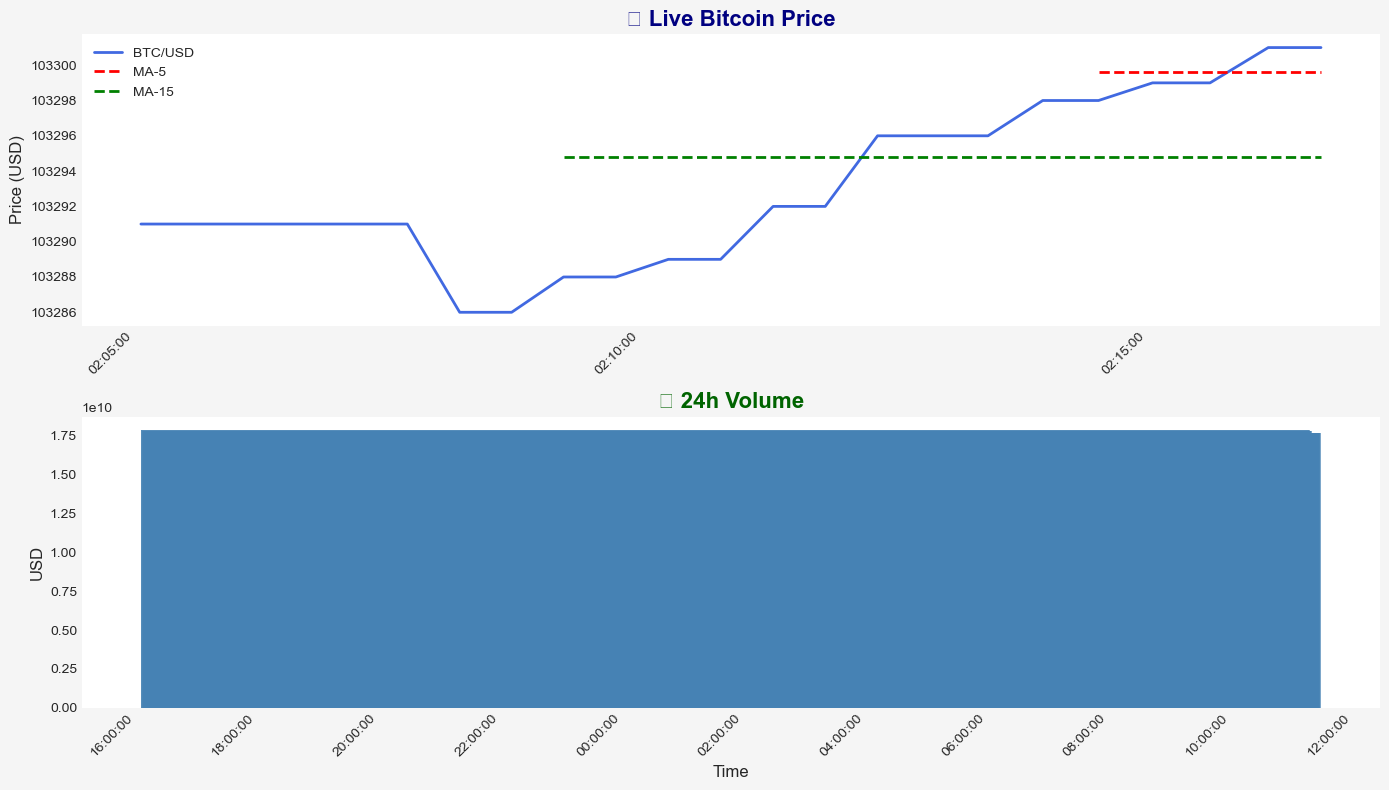


Analysis (2025-05-17 22:16:58)
Current Price: $103,301.00
5-point MA: $103,299.60
15-point MA: $103,294.80
30-point MA: $103,301.00
Volatility: 0.00
[22:16:58] Price: $103,301.00, Volatility: 0.00
[ARIMA Forecast] Next 3 BTC Prices: $103,301.26, $103,301.48, $103,301.67


/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/321638620.py:21: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'recorded_time': datetime.utcnow(),
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:45: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.pause(0.1)
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:45: U

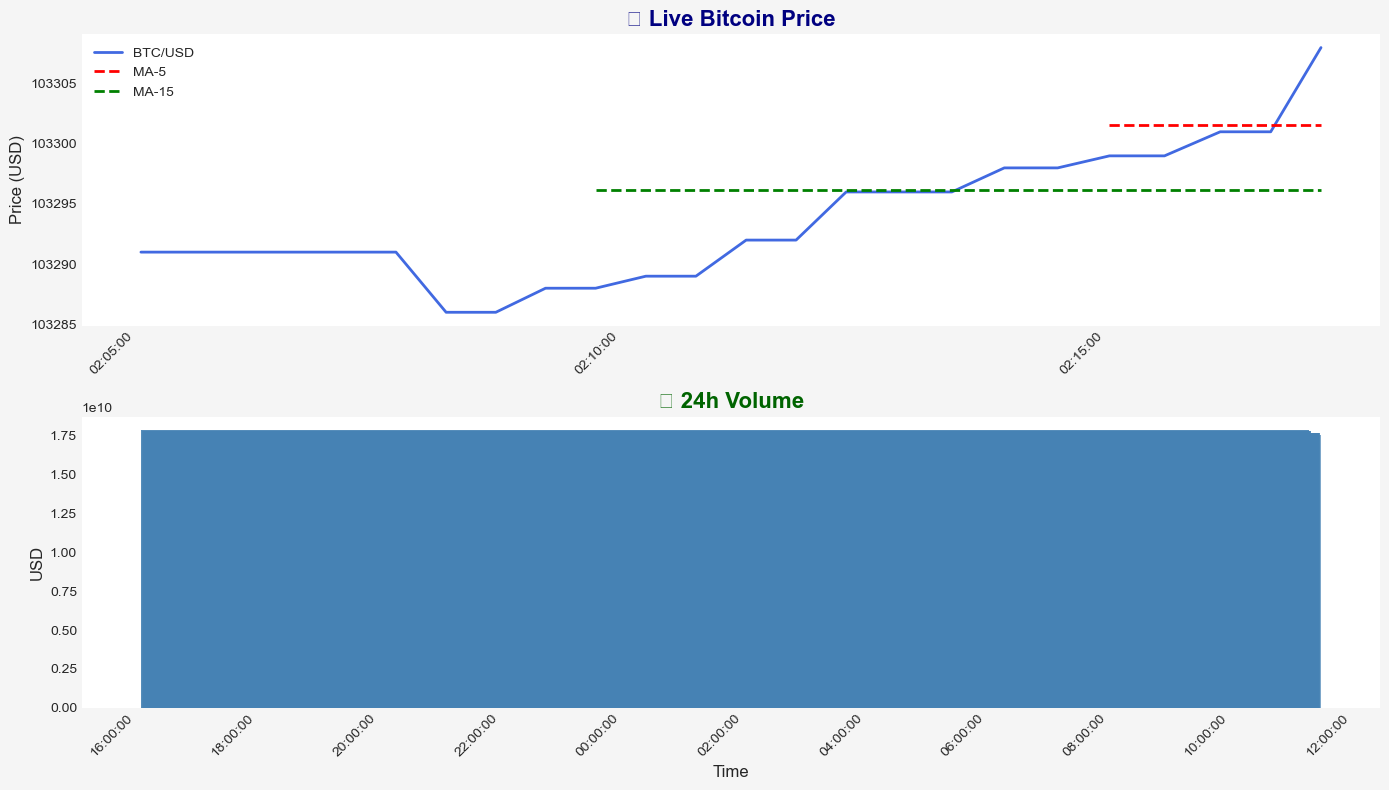


Analysis (2025-05-17 22:17:31)
Current Price: $103,308.00
5-point MA: $103,301.60
15-point MA: $103,296.13
30-point MA: $103,308.00
Volatility: 0.00
[22:17:31] Price: $103,308.00, Volatility: 0.00
[ARIMA Forecast] Next 3 BTC Prices: $103,309.10, $103,310.14, $103,311.13


/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/321638620.py:21: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'recorded_time': datetime.utcnow(),
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:45: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.pause(0.1)
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:45: U

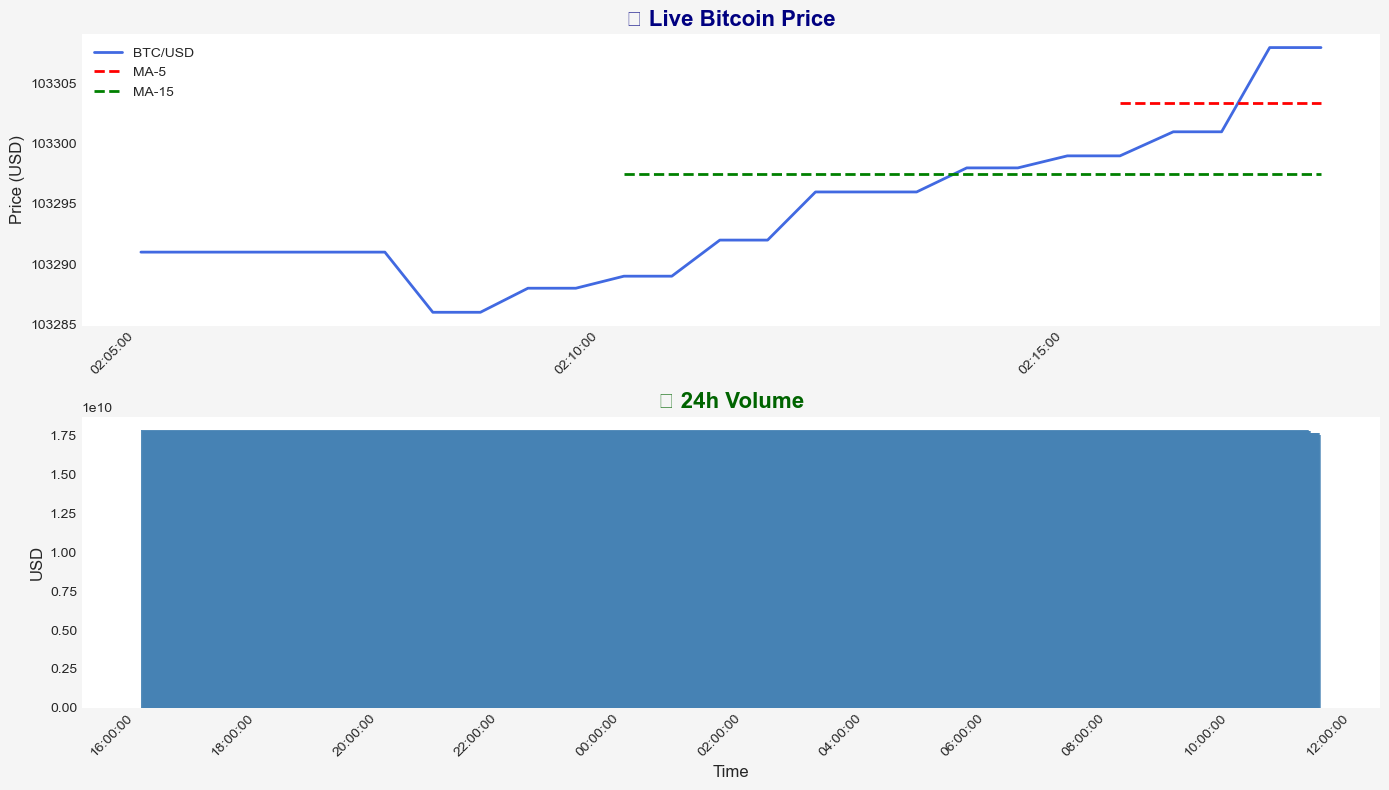


Analysis (2025-05-17 22:18:03)
Current Price: $103,308.00
5-point MA: $103,303.40
15-point MA: $103,297.47
30-point MA: $103,308.00
Volatility: 0.00
[22:18:03] Price: $103,308.00, Volatility: 0.00
[ARIMA Forecast] Next 3 BTC Prices: $103,308.80, $103,309.55, $103,310.28


/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/321638620.py:21: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'recorded_time': datetime.utcnow(),
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:45: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.pause(0.1)
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:45: U

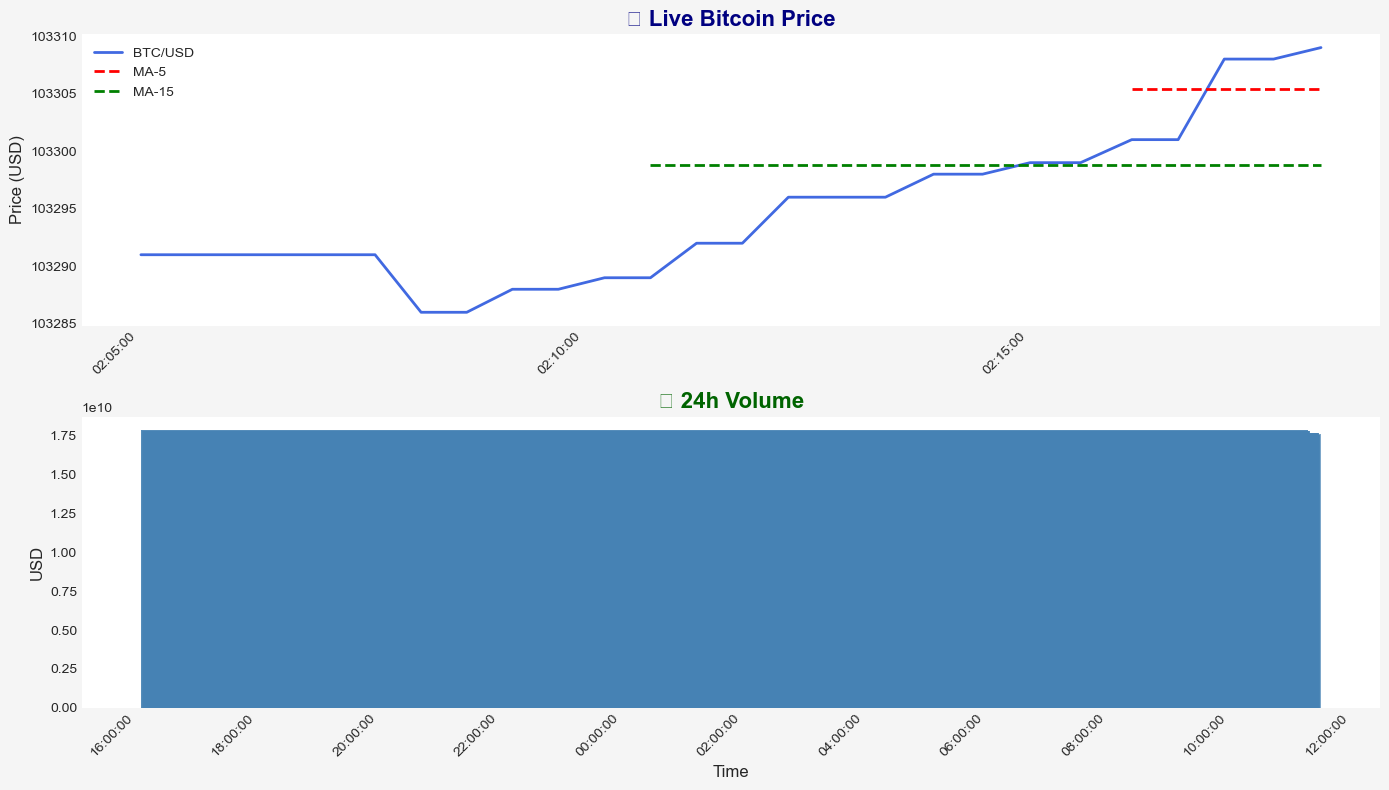


Analysis (2025-05-17 22:18:36)
Current Price: $103,309.00
5-point MA: $103,305.40
15-point MA: $103,298.80
30-point MA: $103,309.00
Volatility: 0.00
[22:18:36] Price: $103,309.00, Volatility: 0.00
[ARIMA Forecast] Next 3 BTC Prices: $103,310.08, $103,311.16, $103,312.24


/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/321638620.py:21: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'recorded_time': datetime.utcnow(),
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:45: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.pause(0.1)
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:45: U

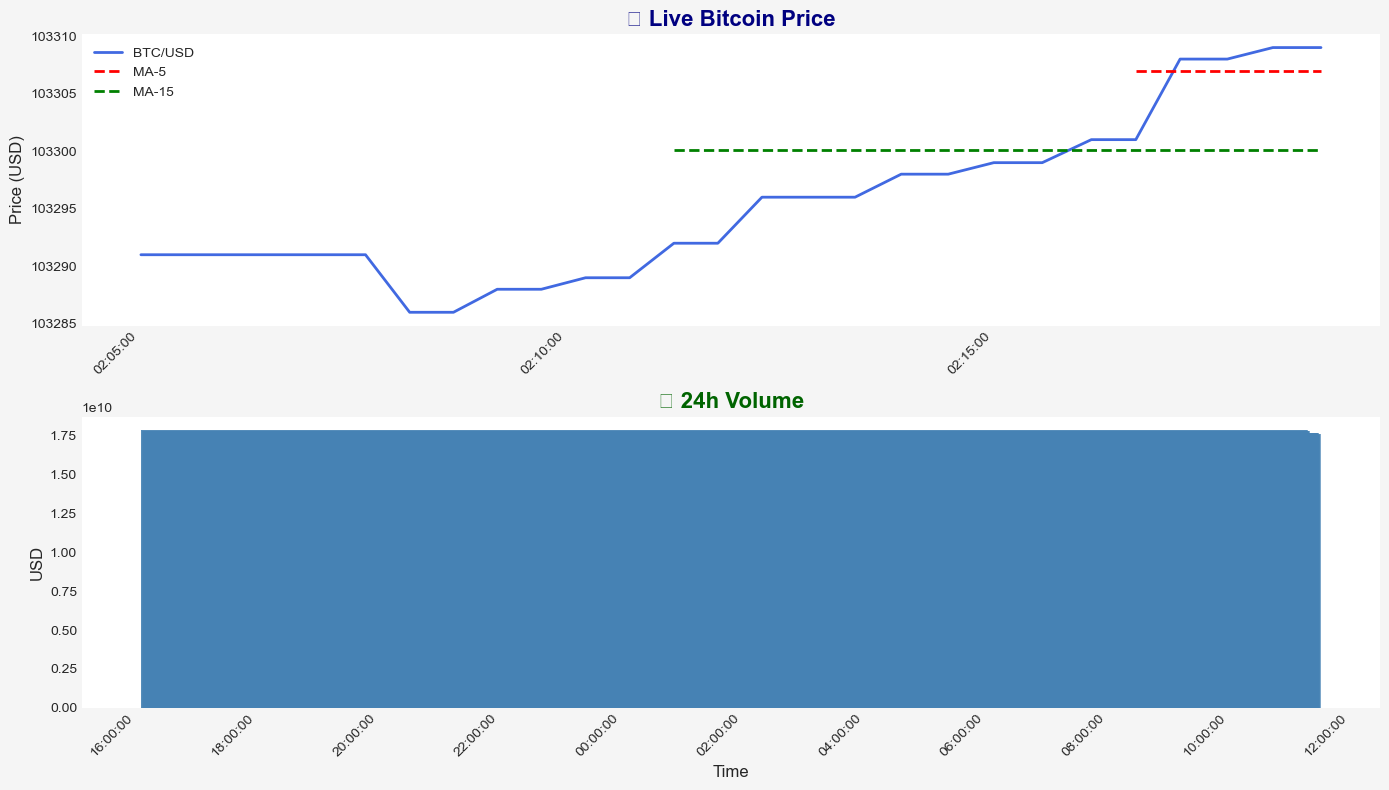


Analysis (2025-05-17 22:19:08)
Current Price: $103,309.00
5-point MA: $103,307.00
15-point MA: $103,300.13
30-point MA: $103,309.00
Volatility: 0.00
[22:19:08] Price: $103,309.00, Volatility: 0.00
[ARIMA Forecast] Next 3 BTC Prices: $103,310.08, $103,311.16, $103,312.24


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/321638620.py:21: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'recorded_time': datetime.utcnow(),
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz8000

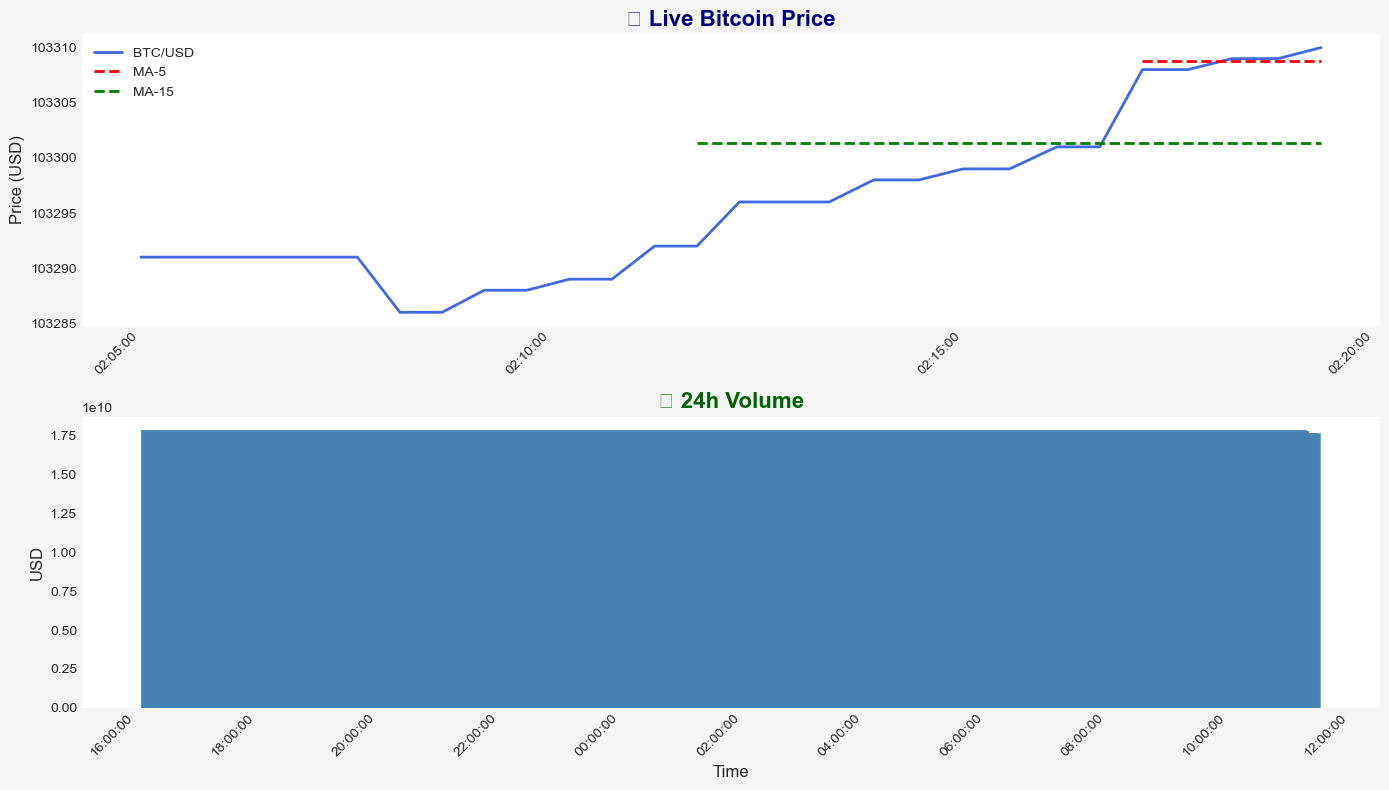


Analysis (2025-05-17 22:19:41)
Current Price: $103,310.00
5-point MA: $103,308.80
15-point MA: $103,301.33
30-point MA: $103,310.00
Volatility: 0.00
[22:19:41] Price: $103,310.00, Volatility: 0.00


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


[ARIMA Forecast] Next 3 BTC Prices: $103,311.02, $103,312.05, $103,313.07


/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/321638620.py:21: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'recorded_time': datetime.utcnow(),
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:45: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.pause(0.1)
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:45: U

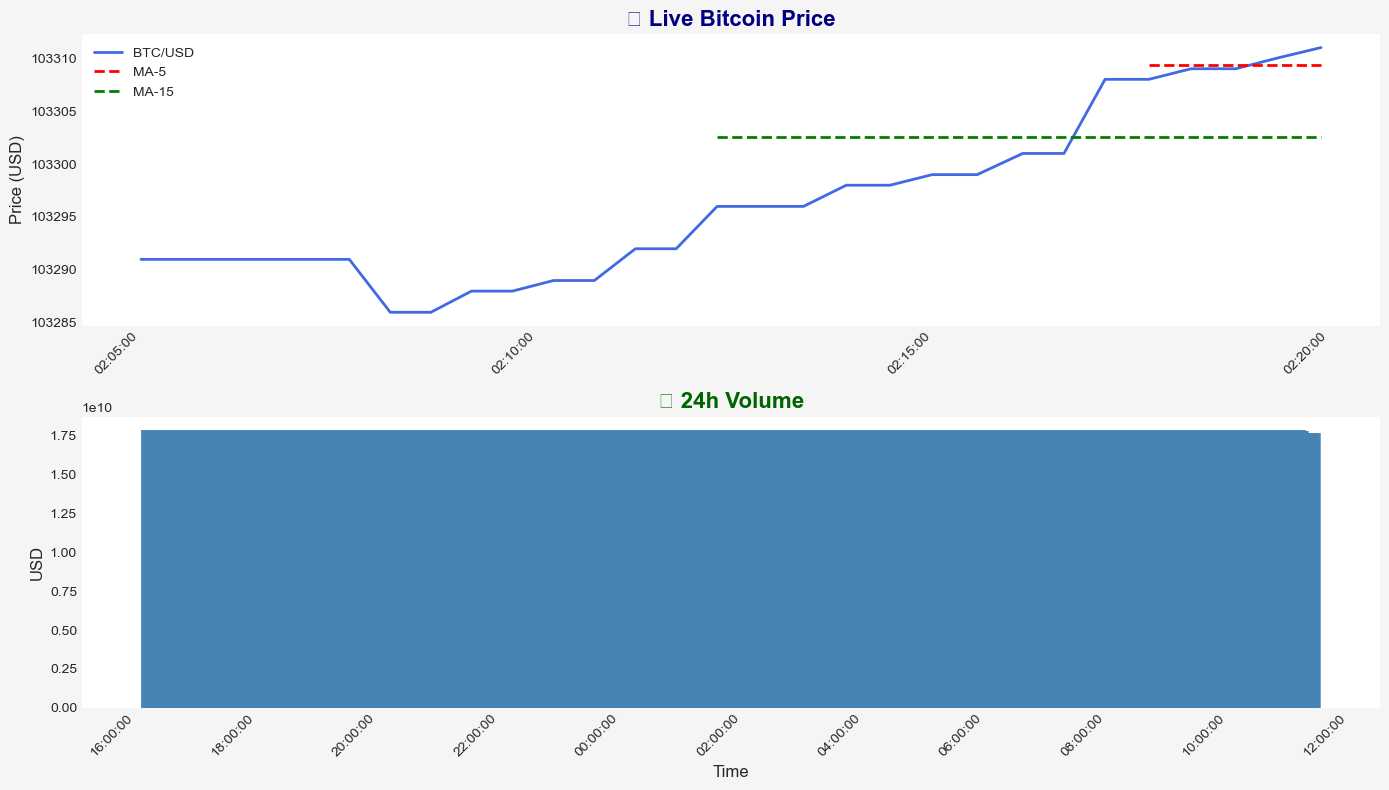


Analysis (2025-05-17 22:20:15)
Current Price: $103,311.00
5-point MA: $103,309.40
15-point MA: $103,302.60
30-point MA: $103,311.00
Volatility: 0.00
[22:20:15] Price: $103,311.00, Volatility: 0.00
[ARIMA Forecast] Next 3 BTC Prices: $103,312.09, $103,313.17, $103,314.26


/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/321638620.py:21: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'recorded_time': datetime.utcnow(),
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:45: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.pause(0.1)
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:45: U

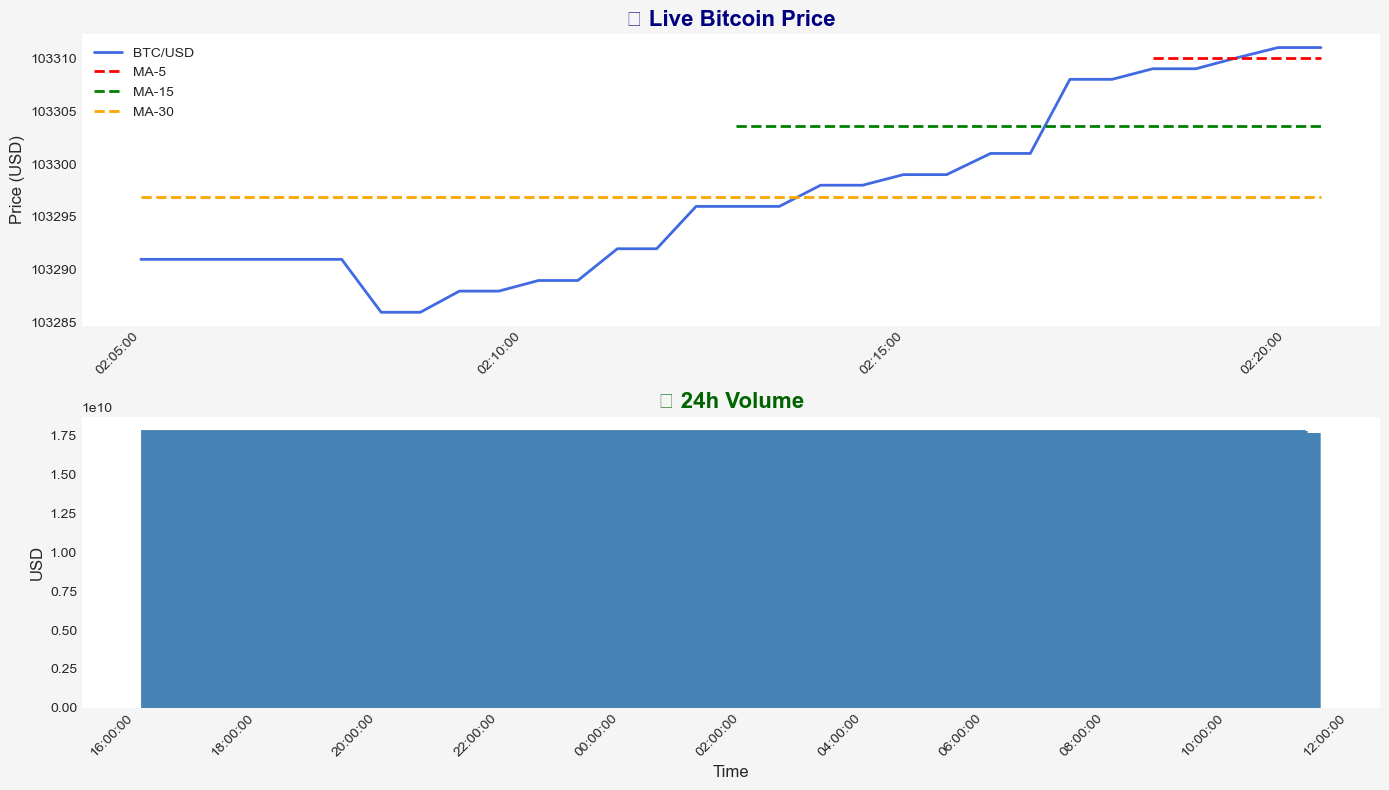


Analysis (2025-05-17 22:20:46)
Current Price: $103,311.00
5-point MA: $103,310.00
15-point MA: $103,303.60
30-point MA: $103,296.87
Volatility: 8.17
[22:20:46] Price: $103,311.00, Volatility: 8.17
[ARIMA Forecast] Next 3 BTC Prices: $103,312.02, $103,313.05, $103,314.07


/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/321638620.py:21: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'recorded_time': datetime.utcnow(),
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:45: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.pause(0.1)
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:45: U

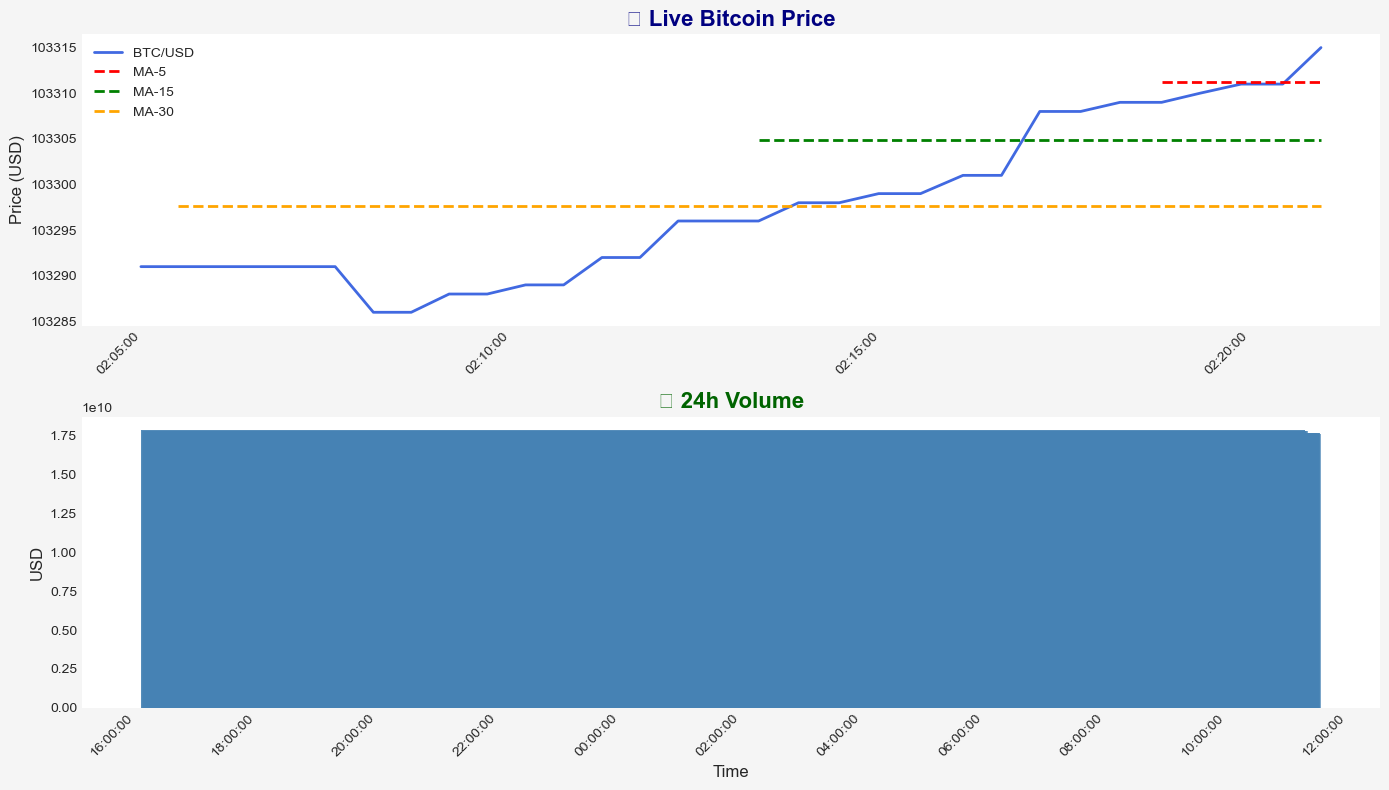


Analysis (2025-05-17 22:21:17)
Current Price: $103,315.00
5-point MA: $103,311.20
15-point MA: $103,304.87
30-point MA: $103,297.67
Volatility: 8.73
[22:21:17] Price: $103,315.00, Volatility: 8.73
[ARIMA Forecast] Next 3 BTC Prices: $103,316.25, $103,317.49, $103,318.74


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/321638620.py:21: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'recorded_time': datetime.utcnow(),
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz8000

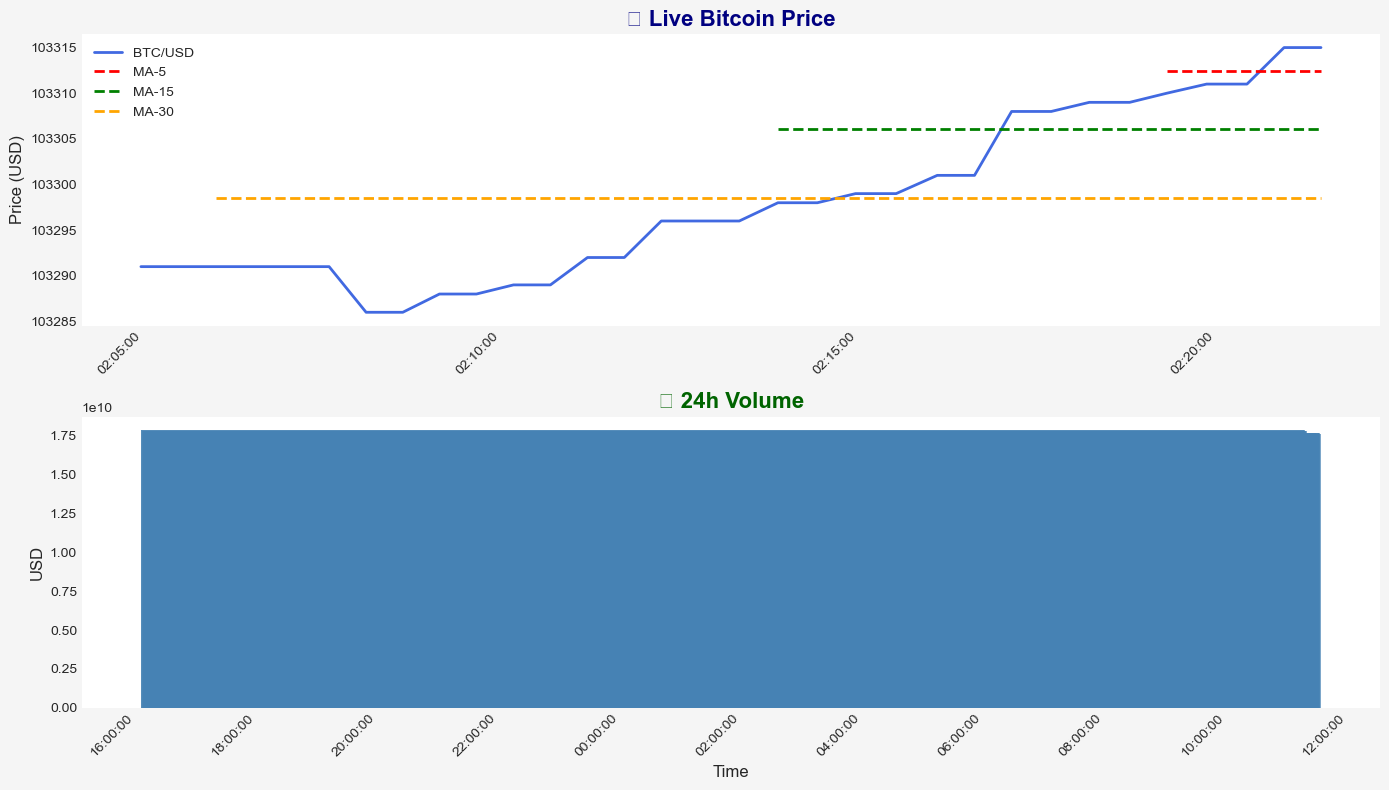


Analysis (2025-05-17 22:21:48)
Current Price: $103,315.00
5-point MA: $103,312.40
15-point MA: $103,306.13
30-point MA: $103,298.47
Volatility: 9.18
[22:21:48] Price: $103,315.00, Volatility: 9.18


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


[ARIMA Forecast] Next 3 BTC Prices: $103,316.07, $103,317.15, $103,318.22


/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/321638620.py:21: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'recorded_time': datetime.utcnow(),
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:45: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.pause(0.1)
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:45: U

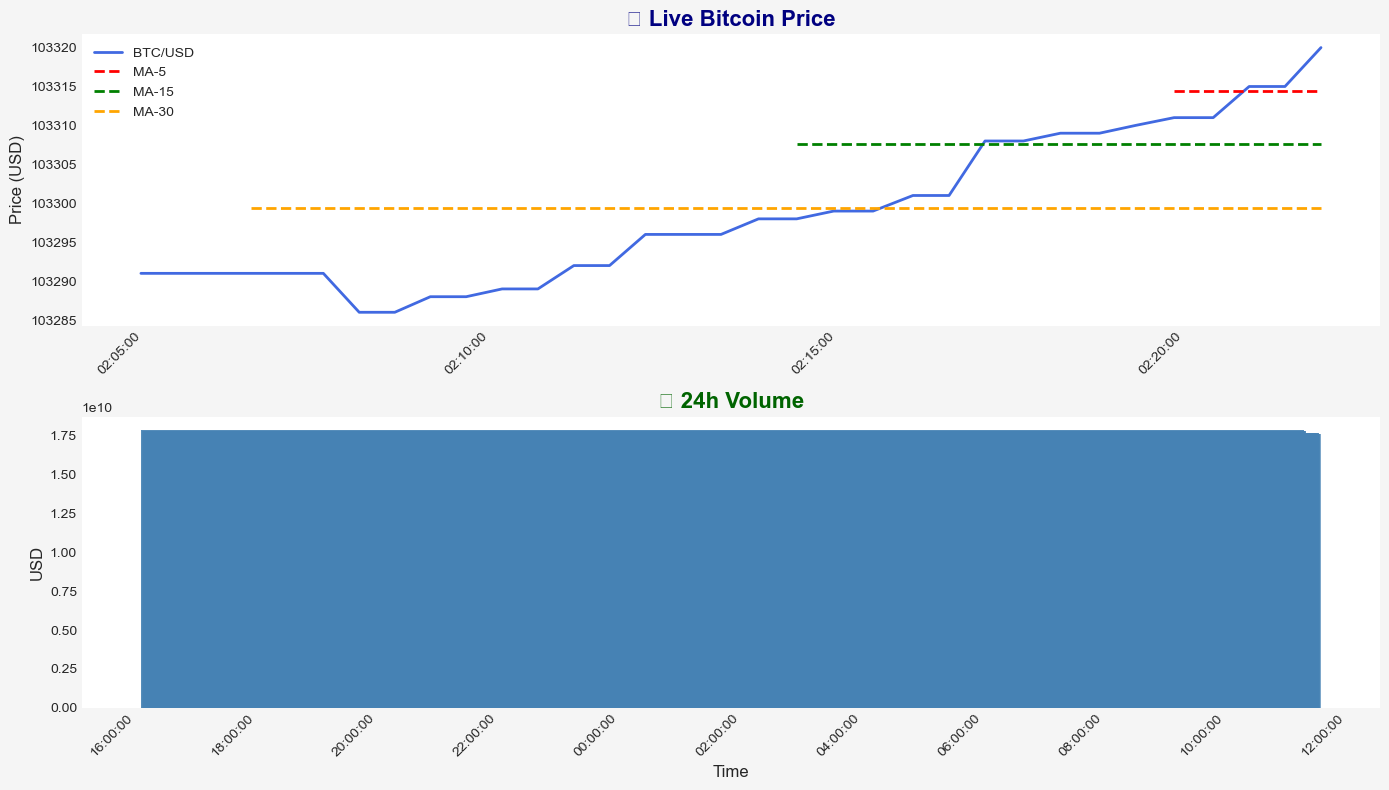


Analysis (2025-05-17 22:22:19)
Current Price: $103,320.00
5-point MA: $103,314.40
15-point MA: $103,307.60
30-point MA: $103,299.43
Volatility: 9.87
[22:22:19] Price: $103,320.00, Volatility: 9.87
[ARIMA Forecast] Next 3 BTC Prices: $103,321.34, $103,322.69, $103,324.03


/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/321638620.py:21: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'recorded_time': datetime.utcnow(),
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:45: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.pause(0.1)
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:45: U

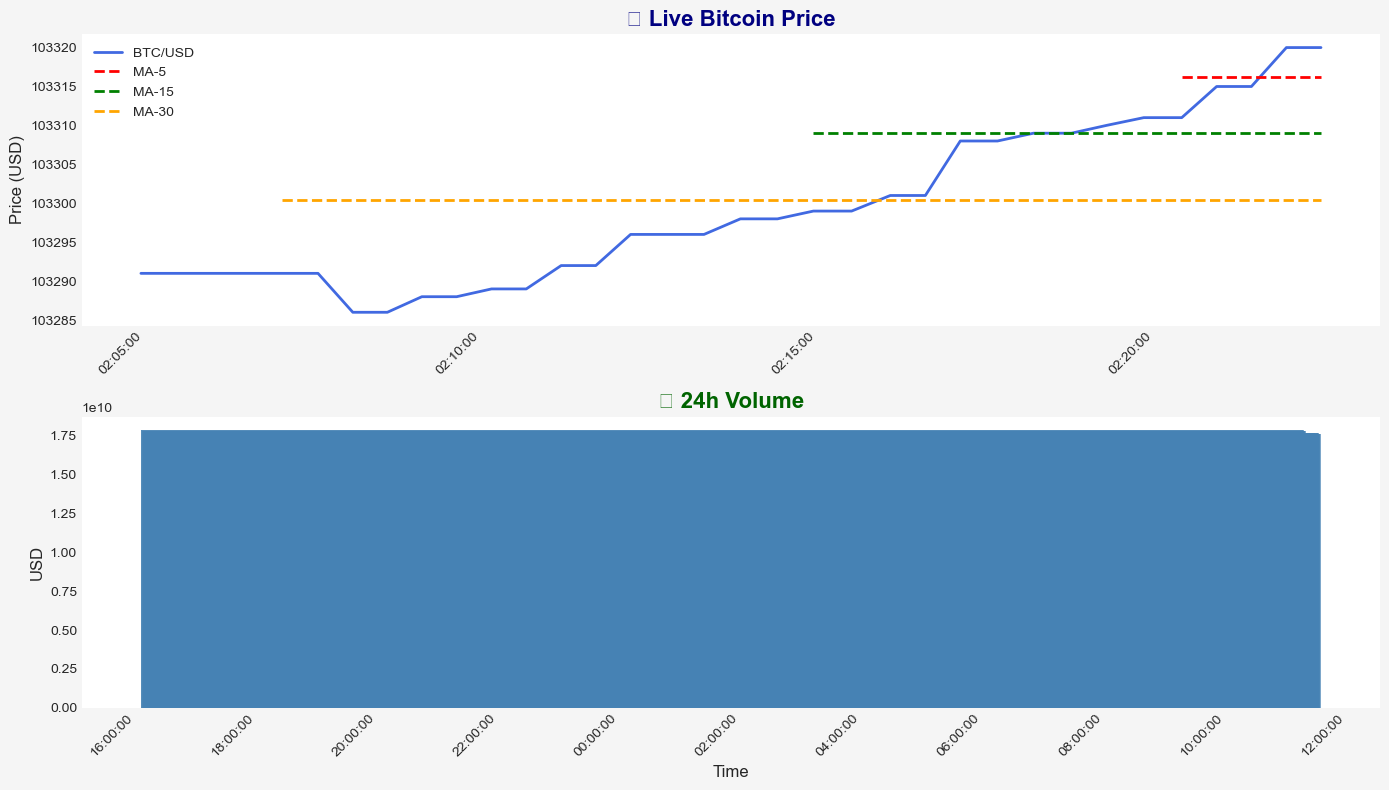


Analysis (2025-05-17 22:22:50)
Current Price: $103,320.00
5-point MA: $103,316.20
15-point MA: $103,309.07
30-point MA: $103,300.40
Volatility: 10.42
[22:22:50] Price: $103,320.00, Volatility: 10.42
[ARIMA Forecast] Next 3 BTC Prices: $103,321.12, $103,322.24, $103,323.36


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/321638620.py:21: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'recorded_time': datetime.utcnow(),
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz8000

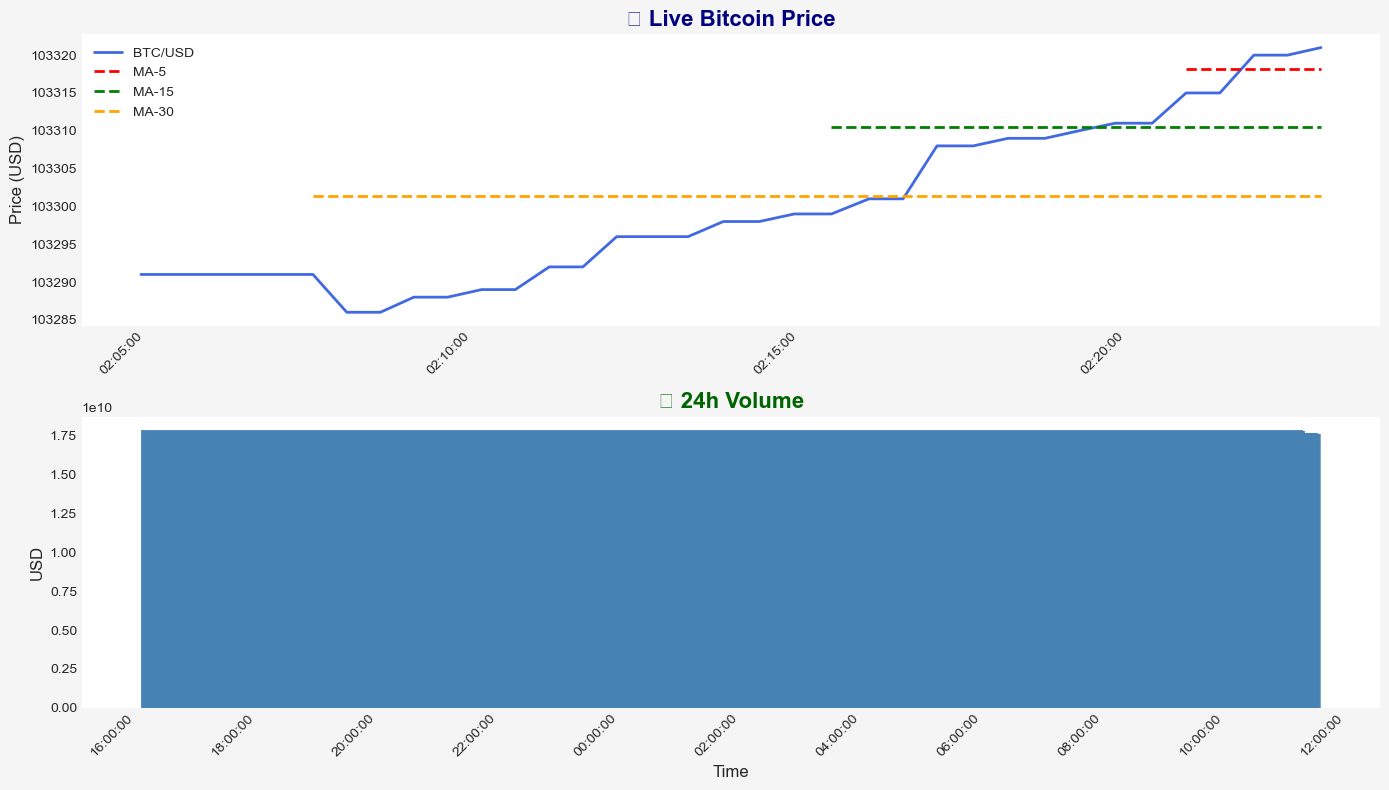


Analysis (2025-05-17 22:23:21)
Current Price: $103,321.00
5-point MA: $103,318.20
15-point MA: $103,310.53
30-point MA: $103,301.40
Volatility: 10.92
[22:23:21] Price: $103,321.00, Volatility: 10.92
[ARIMA Forecast] Next 3 BTC Prices: $103,322.18, $103,323.36, $103,324.54


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/321638620.py:21: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'recorded_time': datetime.utcnow(),
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz8000

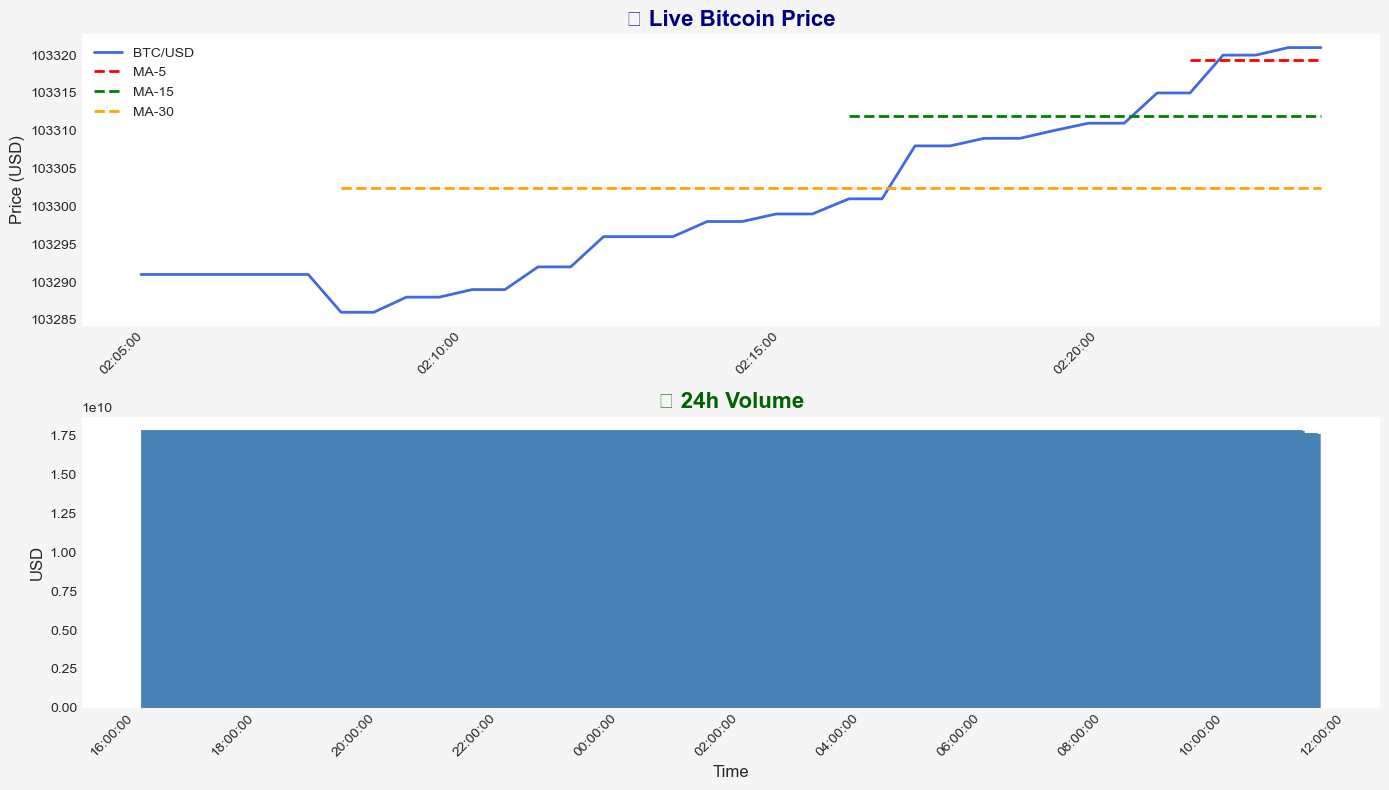


Analysis (2025-05-17 22:23:51)
Current Price: $103,321.00
5-point MA: $103,319.40
15-point MA: $103,312.00
30-point MA: $103,302.40
Volatility: 11.30
[22:23:51] Price: $103,321.00, Volatility: 11.30
[ARIMA Forecast] Next 3 BTC Prices: $103,322.18, $103,323.36, $103,324.54


/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/321638620.py:21: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'recorded_time': datetime.utcnow(),
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:45: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.pause(0.1)
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:45: U

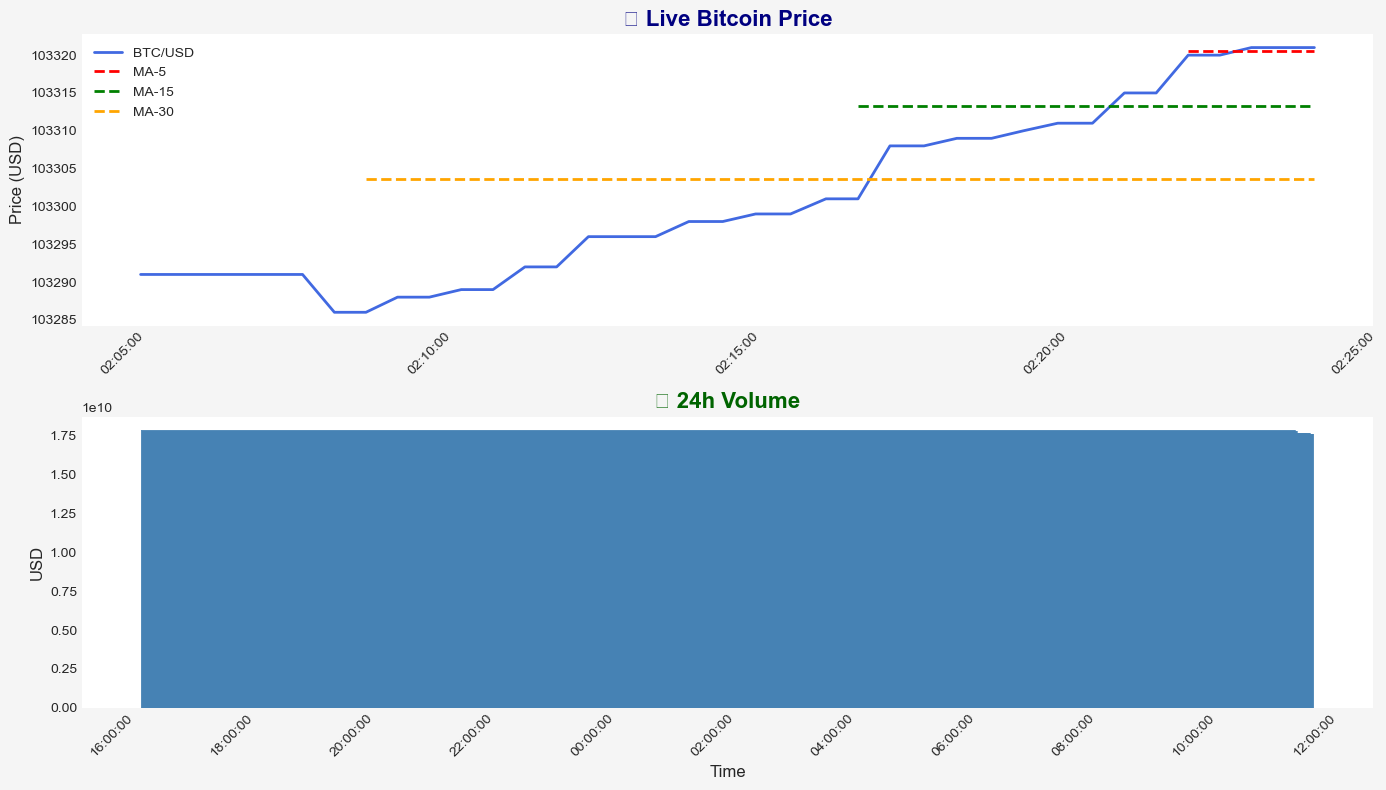


Analysis (2025-05-17 22:24:22)
Current Price: $103,321.00
5-point MA: $103,320.60
15-point MA: $103,313.33
30-point MA: $103,303.57
Volatility: 11.35
[22:24:22] Price: $103,321.00, Volatility: 11.35
[ARIMA Forecast] Next 3 BTC Prices: $103,322.06, $103,323.12, $103,324.18


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/321638620.py:21: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'recorded_time': datetime.utcnow(),
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz8000

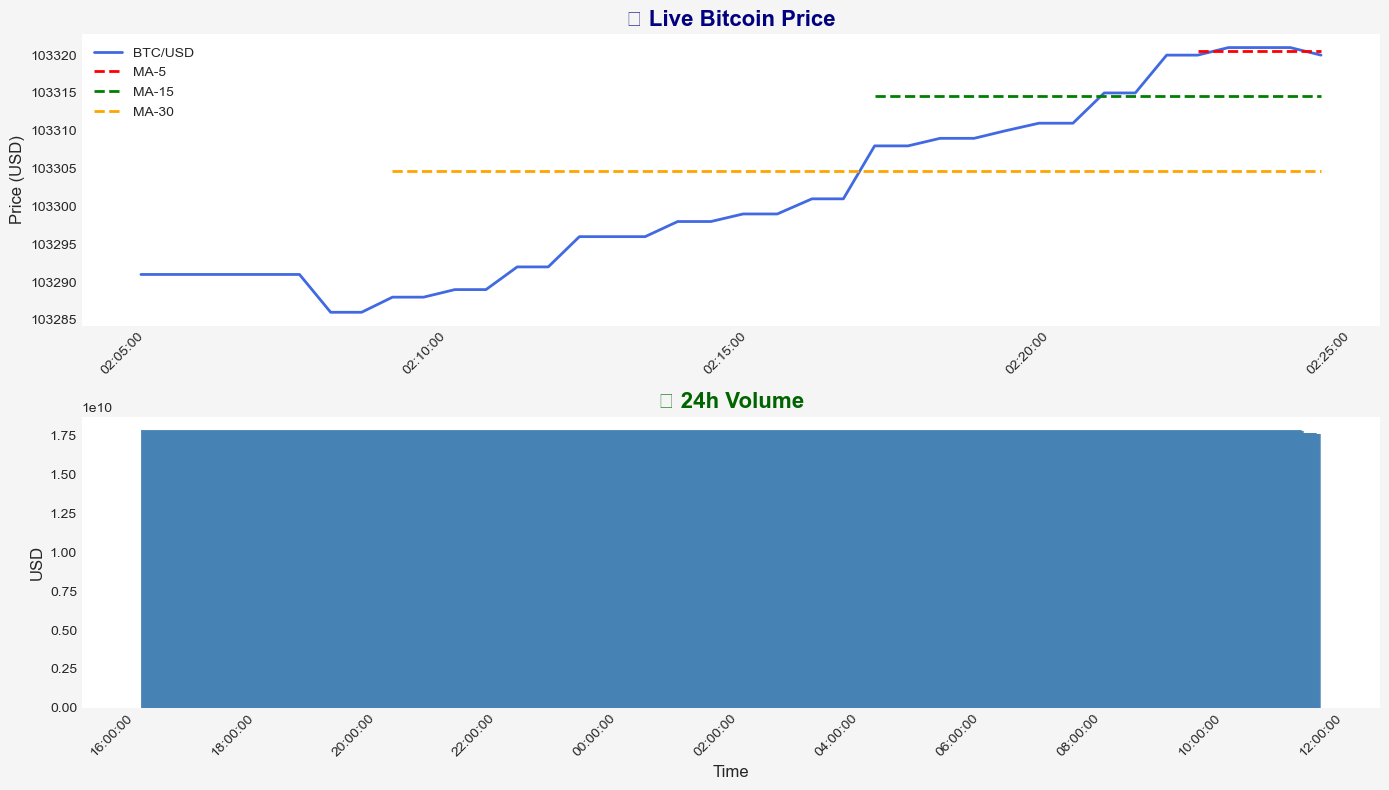


Analysis (2025-05-17 22:24:53)
Current Price: $103,320.00
5-point MA: $103,320.60
15-point MA: $103,314.60
30-point MA: $103,304.70
Volatility: 11.23
[22:24:53] Price: $103,320.00, Volatility: 11.23
[ARIMA Forecast] Next 3 BTC Prices: $103,320.99, $103,321.98, $103,322.98


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/321638620.py:21: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'recorded_time': datetime.utcnow(),
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz8000

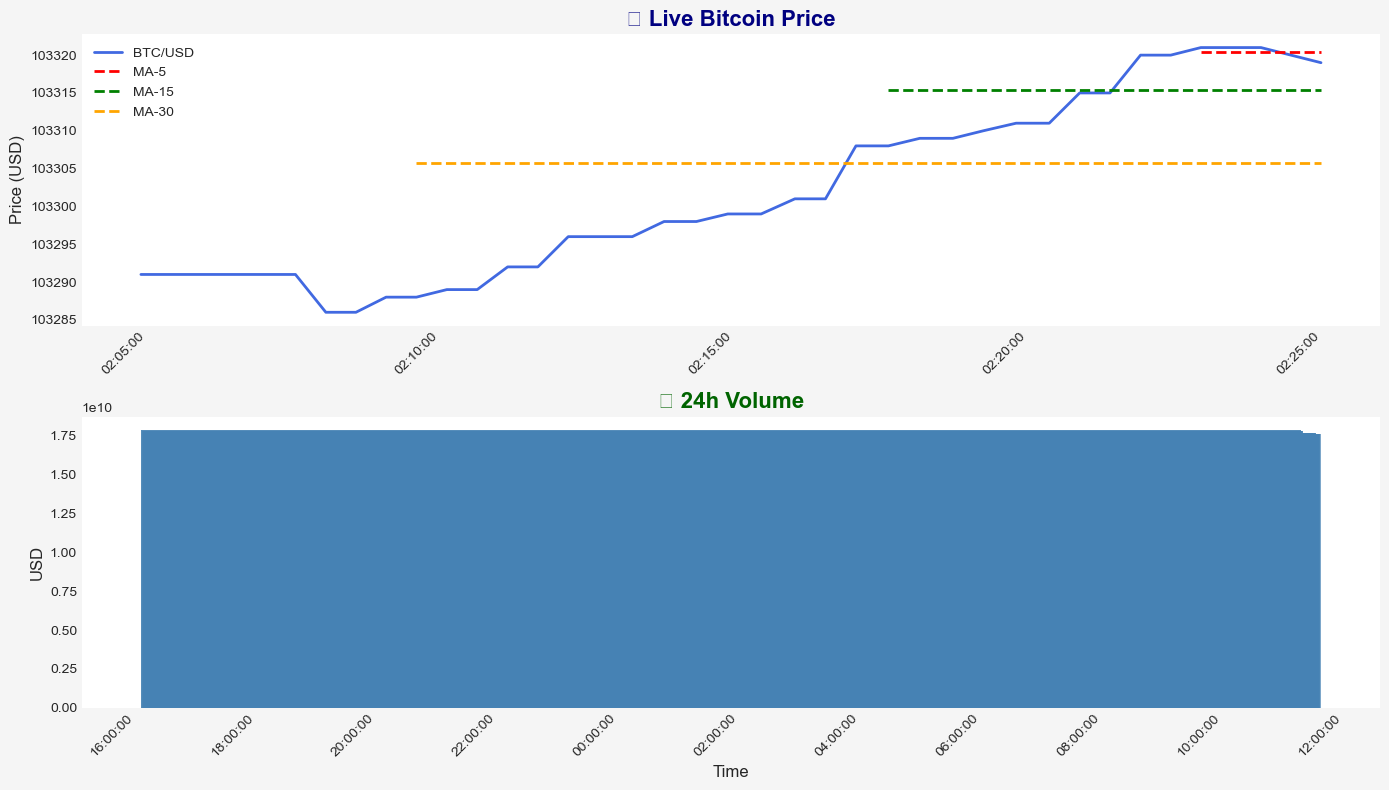


Analysis (2025-05-17 22:25:23)
Current Price: $103,319.00
5-point MA: $103,320.40
15-point MA: $103,315.33
30-point MA: $103,305.73
Volatility: 11.07
[22:25:23] Price: $103,319.00, Volatility: 11.07
[ARIMA Forecast] Next 3 BTC Prices: $103,319.44, $103,319.86, $103,320.28


/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/321638620.py:21: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'recorded_time': datetime.utcnow(),
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:45: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.pause(0.1)
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:45: U

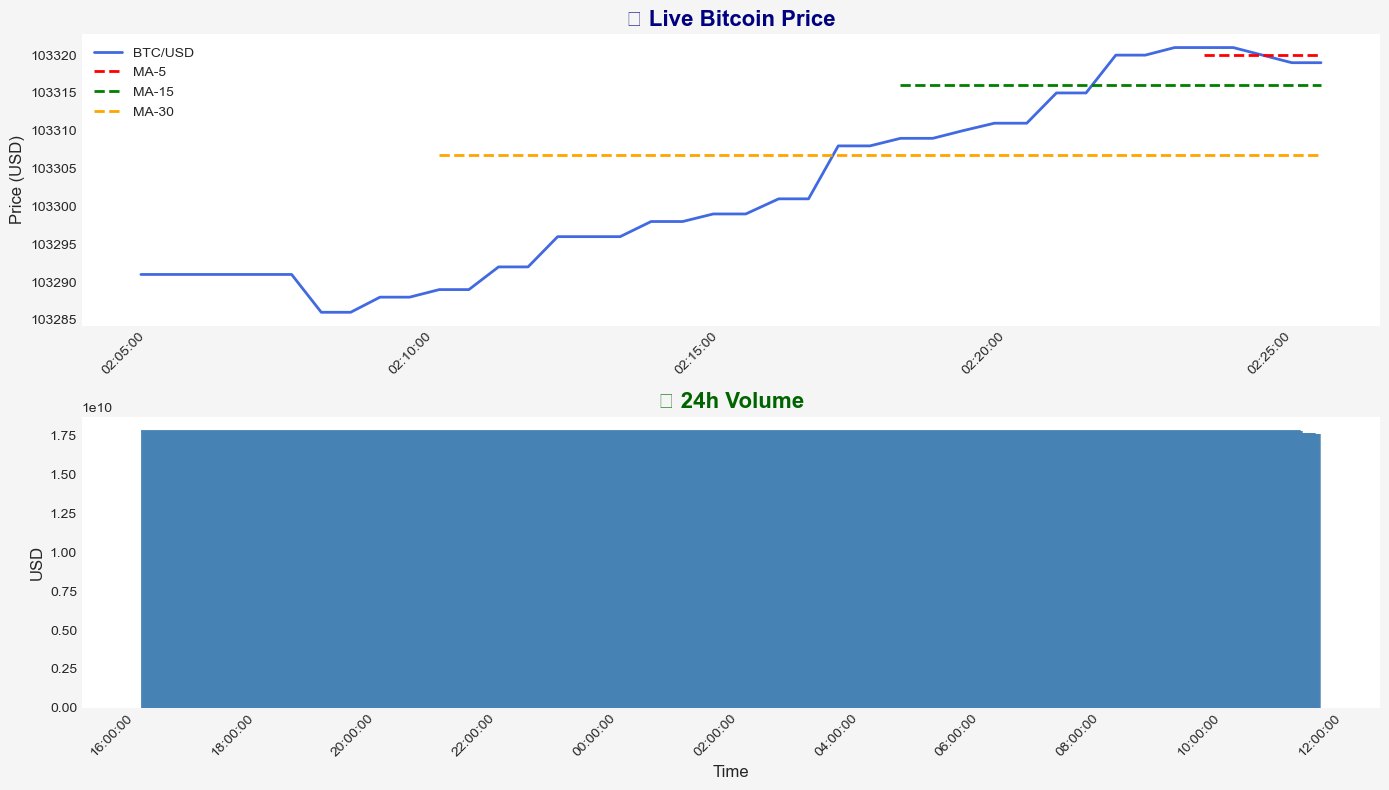


Analysis (2025-05-17 22:25:54)
Current Price: $103,319.00
5-point MA: $103,320.00
15-point MA: $103,316.07
30-point MA: $103,306.77
Volatility: 10.80
[22:25:54] Price: $103,319.00, Volatility: 10.80
[ARIMA Forecast] Next 3 BTC Prices: $103,319.27, $103,319.54, $103,319.79


/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/321638620.py:21: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'recorded_time': datetime.utcnow(),
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:45: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.pause(0.1)
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:45: U

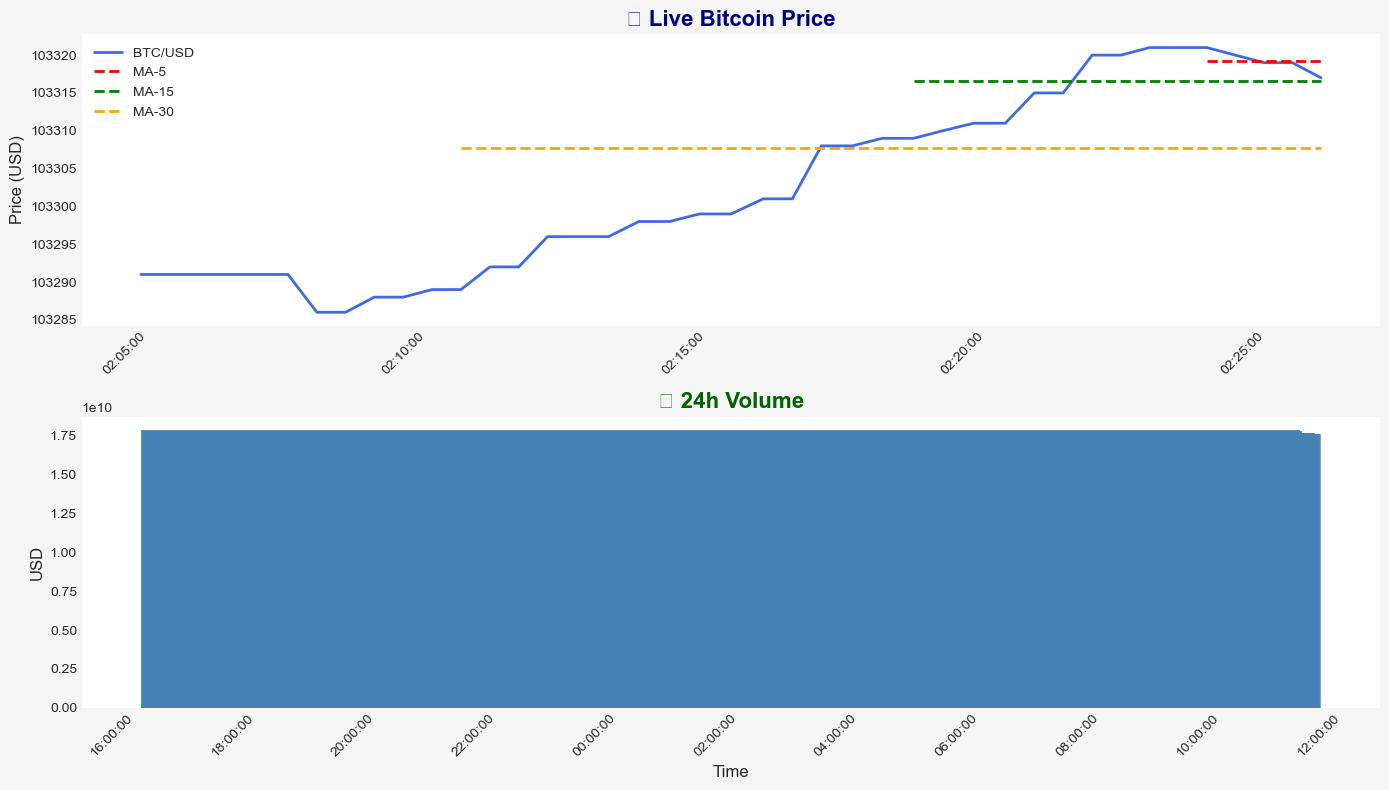


Analysis (2025-05-17 22:26:25)
Current Price: $103,317.00
5-point MA: $103,319.20
15-point MA: $103,316.60
30-point MA: $103,307.70
Volatility: 10.42
[22:26:25] Price: $103,317.00, Volatility: 10.42
[ARIMA Forecast] Next 3 BTC Prices: $103,316.79, $103,316.59, $103,316.42


/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/321638620.py:21: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'recorded_time': datetime.utcnow(),
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:45: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.pause(0.1)
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:45: U

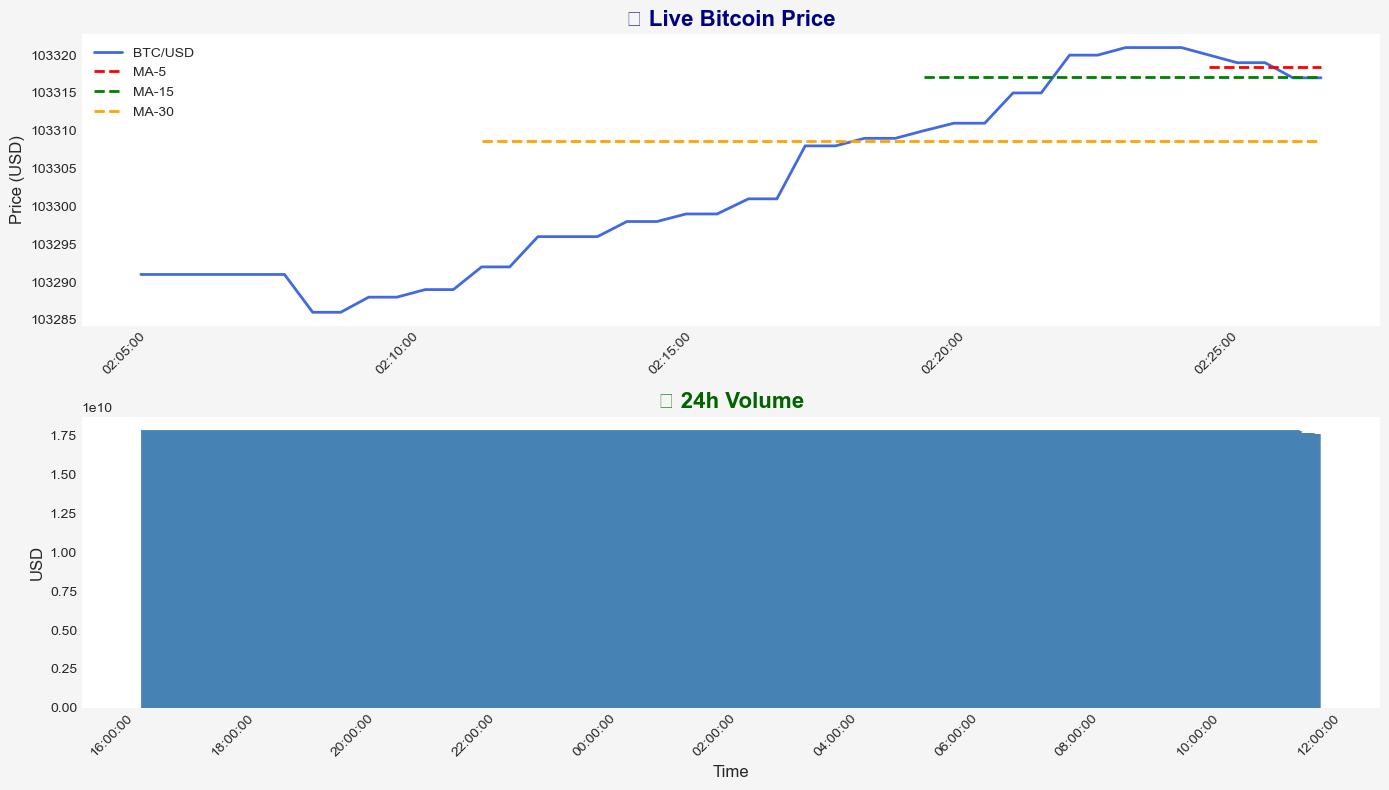


Analysis (2025-05-17 22:26:55)
Current Price: $103,317.00
5-point MA: $103,318.40
15-point MA: $103,317.13
30-point MA: $103,308.63
Volatility: 9.93
[22:26:55] Price: $103,317.00, Volatility: 9.93
[ARIMA Forecast] Next 3 BTC Prices: $103,316.74, $103,316.49, $103,316.27


/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/321638620.py:21: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'recorded_time': datetime.utcnow(),
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:45: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.pause(0.1)
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:45: U

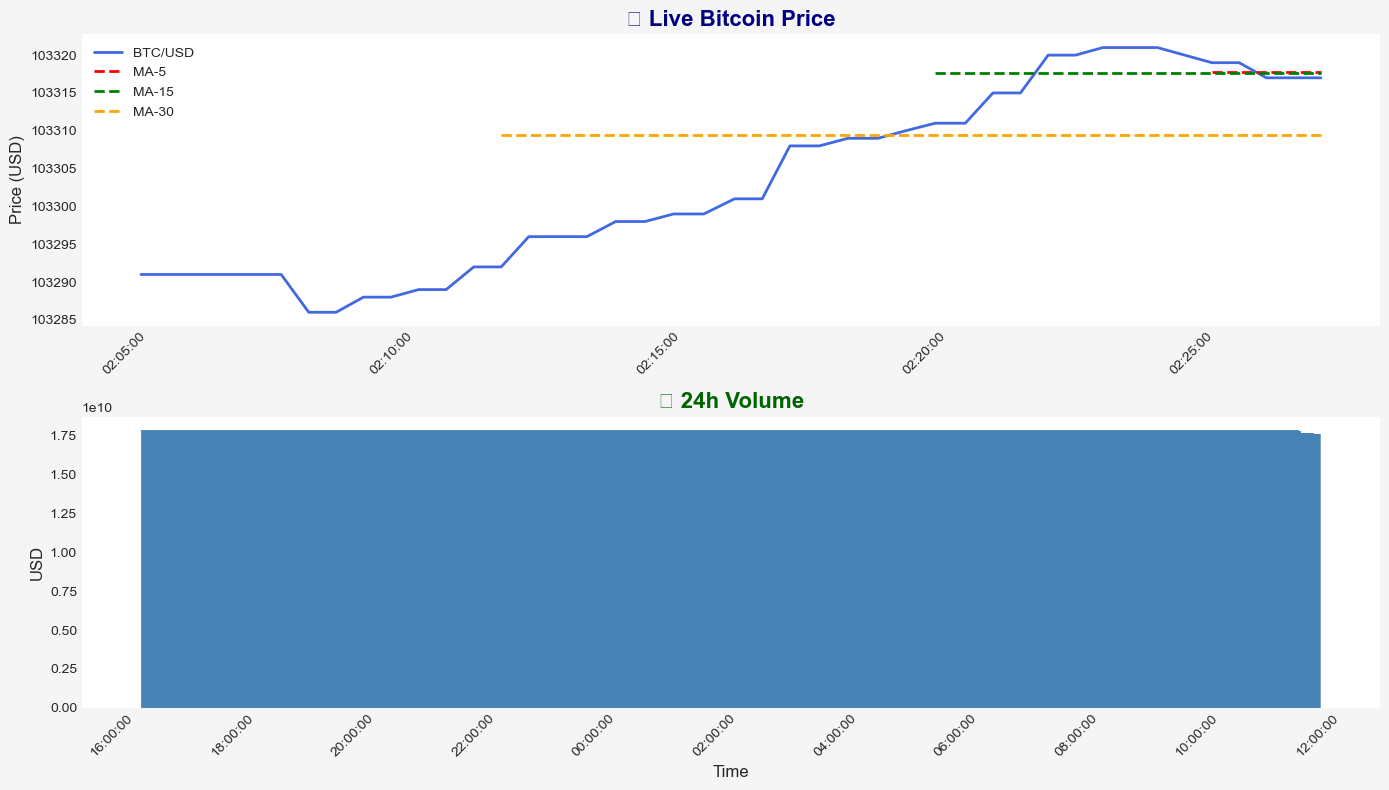


Analysis (2025-05-17 22:27:26)
Current Price: $103,317.00
5-point MA: $103,317.80
15-point MA: $103,317.60
30-point MA: $103,309.47
Volatility: 9.52
[22:27:26] Price: $103,317.00, Volatility: 9.52
[ARIMA Forecast] Next 3 BTC Prices: $103,316.83, $103,316.69, $103,316.58


/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/321638620.py:21: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'recorded_time': datetime.utcnow(),
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:45: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.pause(0.1)
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:45: U

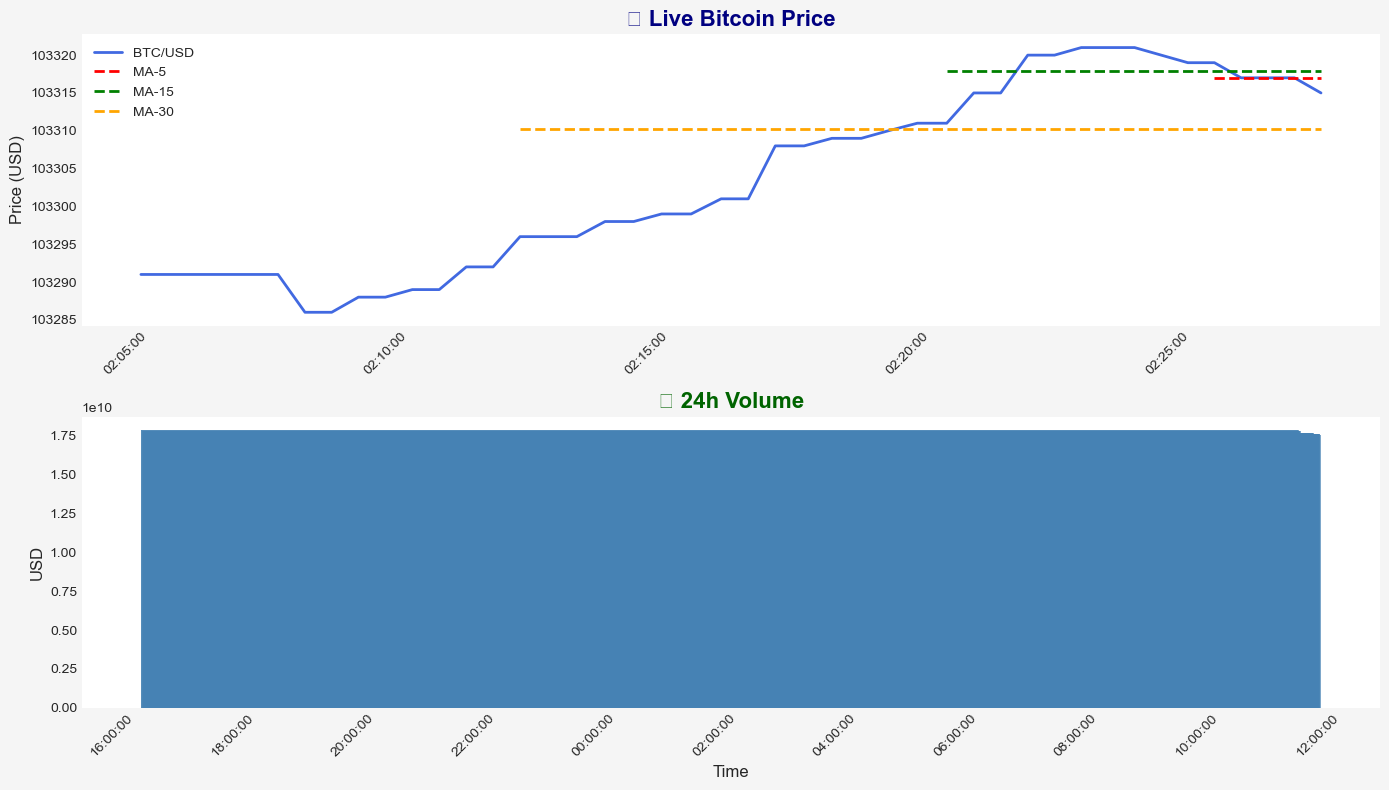


Analysis (2025-05-17 22:27:57)
Current Price: $103,315.00
5-point MA: $103,317.00
15-point MA: $103,317.87
30-point MA: $103,310.23
Volatility: 8.98
[22:27:57] Price: $103,315.00, Volatility: 8.98
[ARIMA Forecast] Next 3 BTC Prices: $103,314.50, $103,314.08, $103,313.74


/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/321638620.py:21: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'recorded_time': datetime.utcnow(),
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:45: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.pause(0.1)
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:45: U

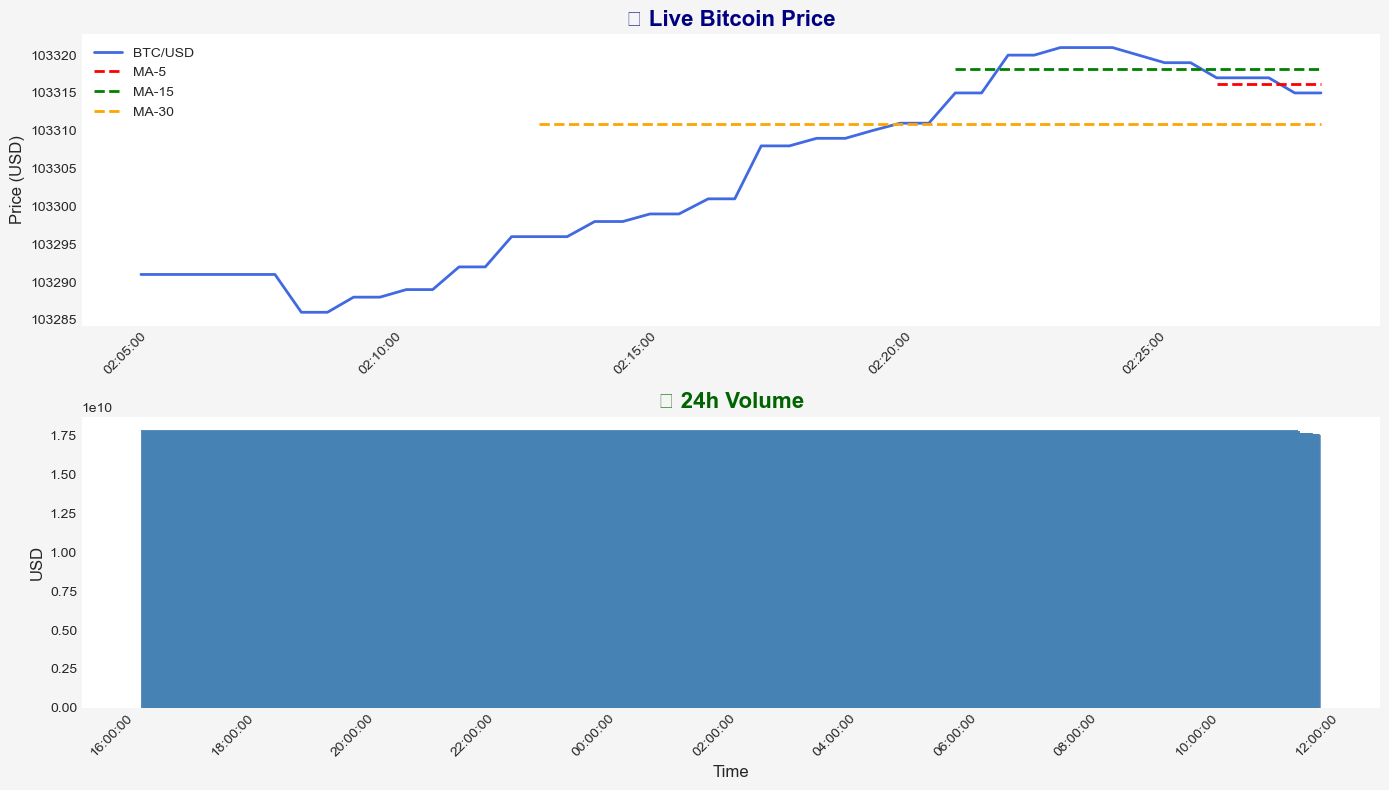


Analysis (2025-05-17 22:28:27)
Current Price: $103,315.00
5-point MA: $103,316.20
15-point MA: $103,318.13
30-point MA: $103,310.87
Volatility: 8.60
[22:28:27] Price: $103,315.00, Volatility: 8.60
[ARIMA Forecast] Next 3 BTC Prices: $103,314.71, $103,314.47, $103,314.27


/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/321638620.py:21: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'recorded_time': datetime.utcnow(),
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:45: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.pause(0.1)
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:45: U

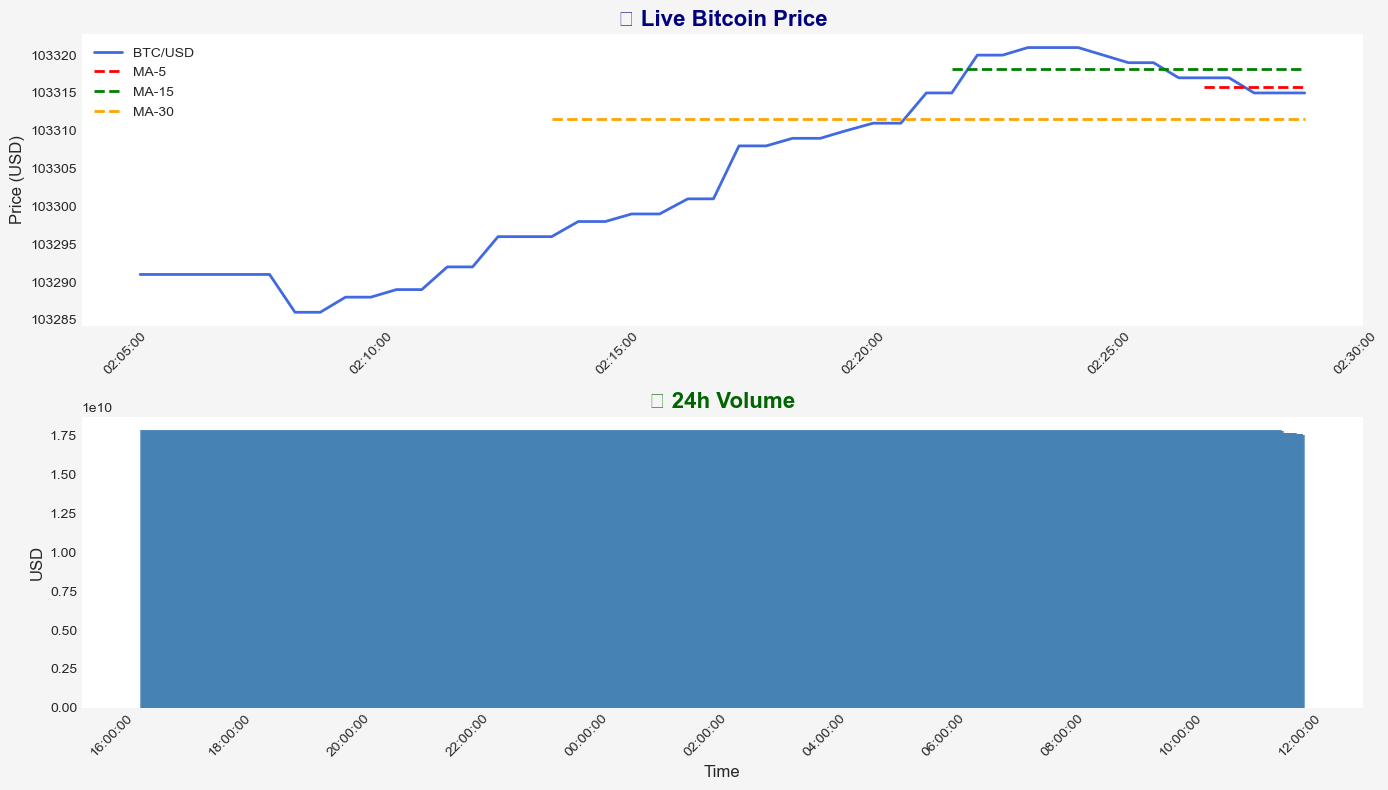


Analysis (2025-05-17 22:28:58)
Current Price: $103,315.00
5-point MA: $103,315.80
15-point MA: $103,318.13
30-point MA: $103,311.50
Volatility: 8.16
[22:28:58] Price: $103,315.00, Volatility: 8.16
[ARIMA Forecast] Next 3 BTC Prices: $103,314.80, $103,314.63, $103,314.49


/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/321638620.py:21: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'recorded_time': datetime.utcnow(),
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:45: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.pause(0.1)
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:45: U

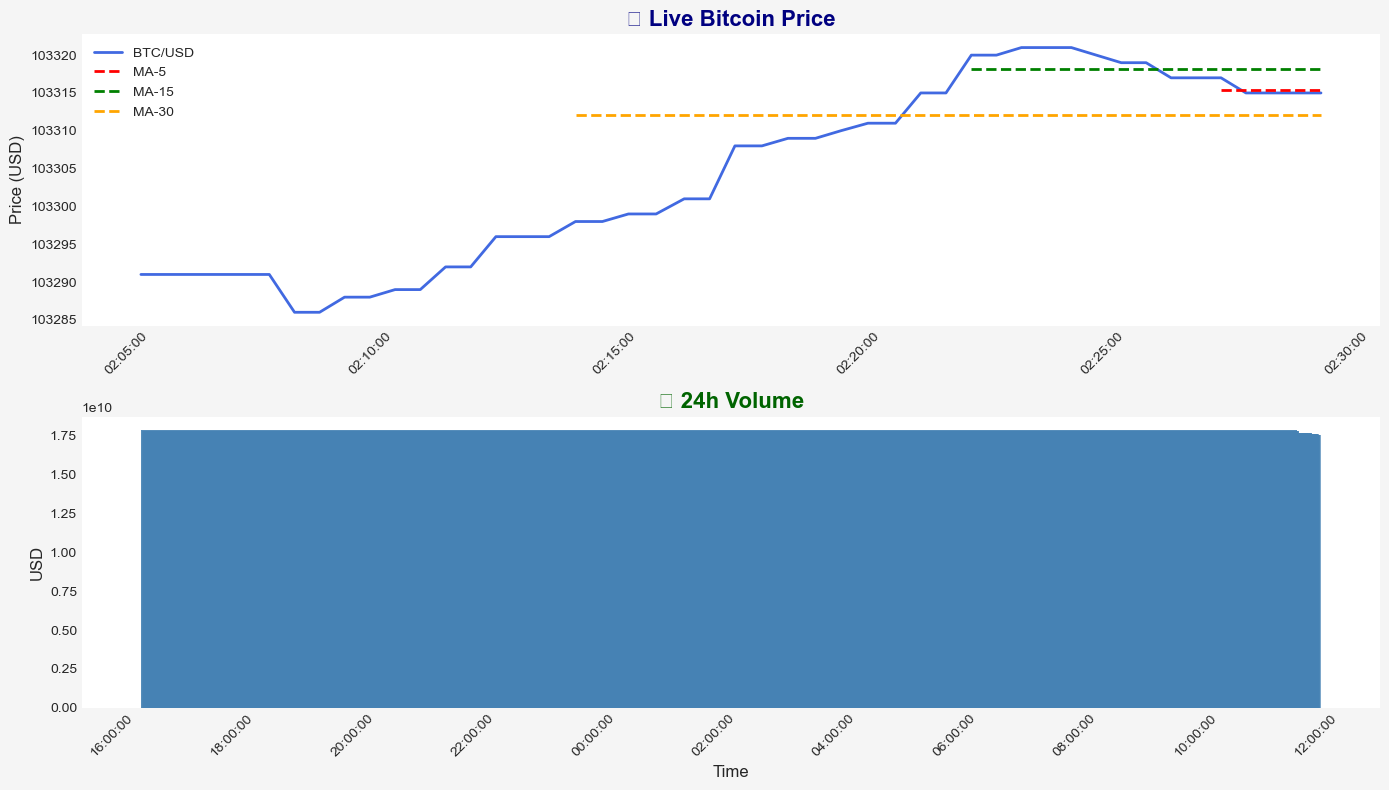


Analysis (2025-05-17 22:29:29)
Current Price: $103,315.00
5-point MA: $103,315.40
15-point MA: $103,318.13
30-point MA: $103,312.13
Volatility: 7.63
[22:29:29] Price: $103,315.00, Volatility: 7.63
[ARIMA Forecast] Next 3 BTC Prices: $103,314.88, $103,314.79, $103,314.71


/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/321638620.py:21: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'recorded_time': datetime.utcnow(),
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:45: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.pause(0.1)
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:45: U

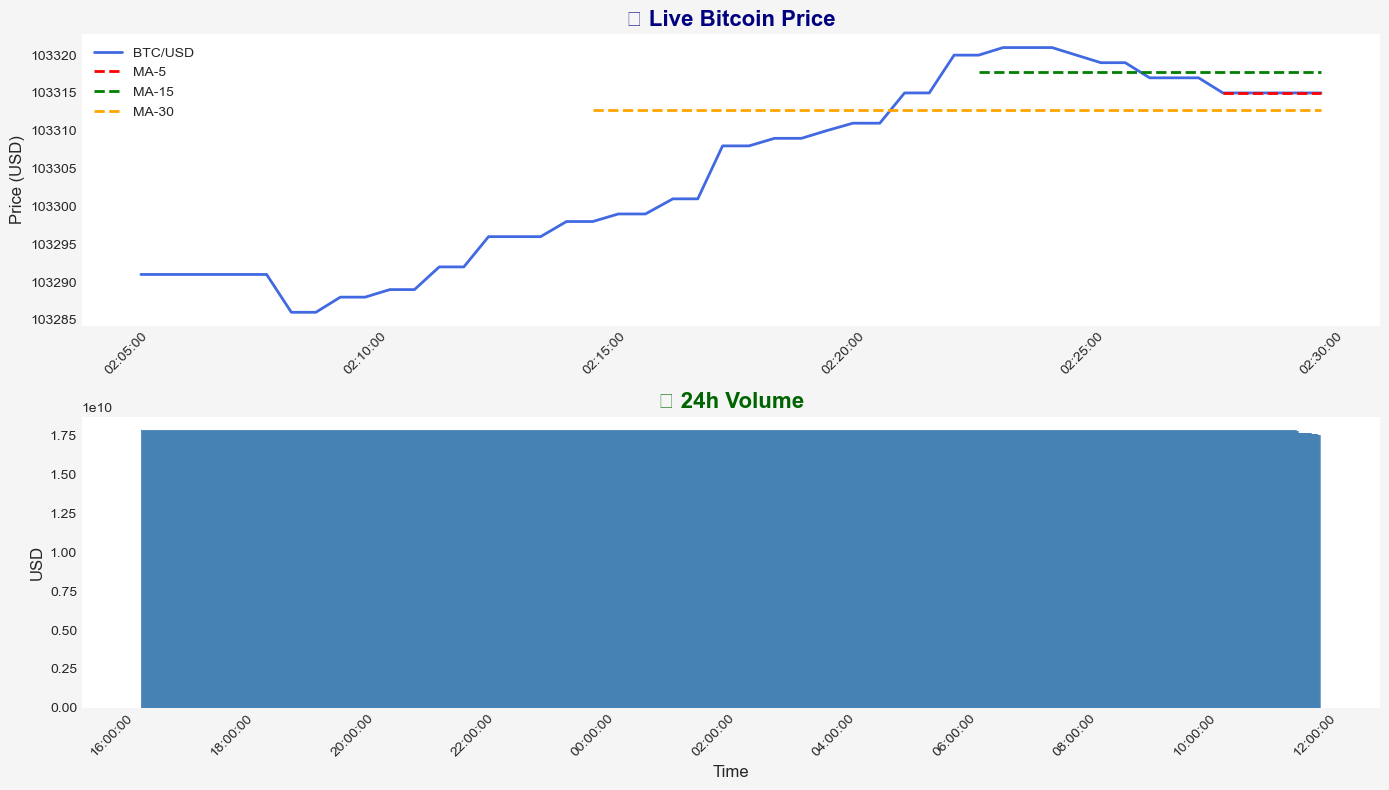


Analysis (2025-05-17 22:30:00)
Current Price: $103,315.00
5-point MA: $103,315.00
15-point MA: $103,317.80
30-point MA: $103,312.70
Volatility: 7.16
[22:30:00] Price: $103,315.00, Volatility: 7.16
[ARIMA Forecast] Next 3 BTC Prices: $103,314.93, $103,314.88, $103,314.84


/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/321638620.py:21: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'recorded_time': datetime.utcnow(),
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:45: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.pause(0.1)
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:45: U

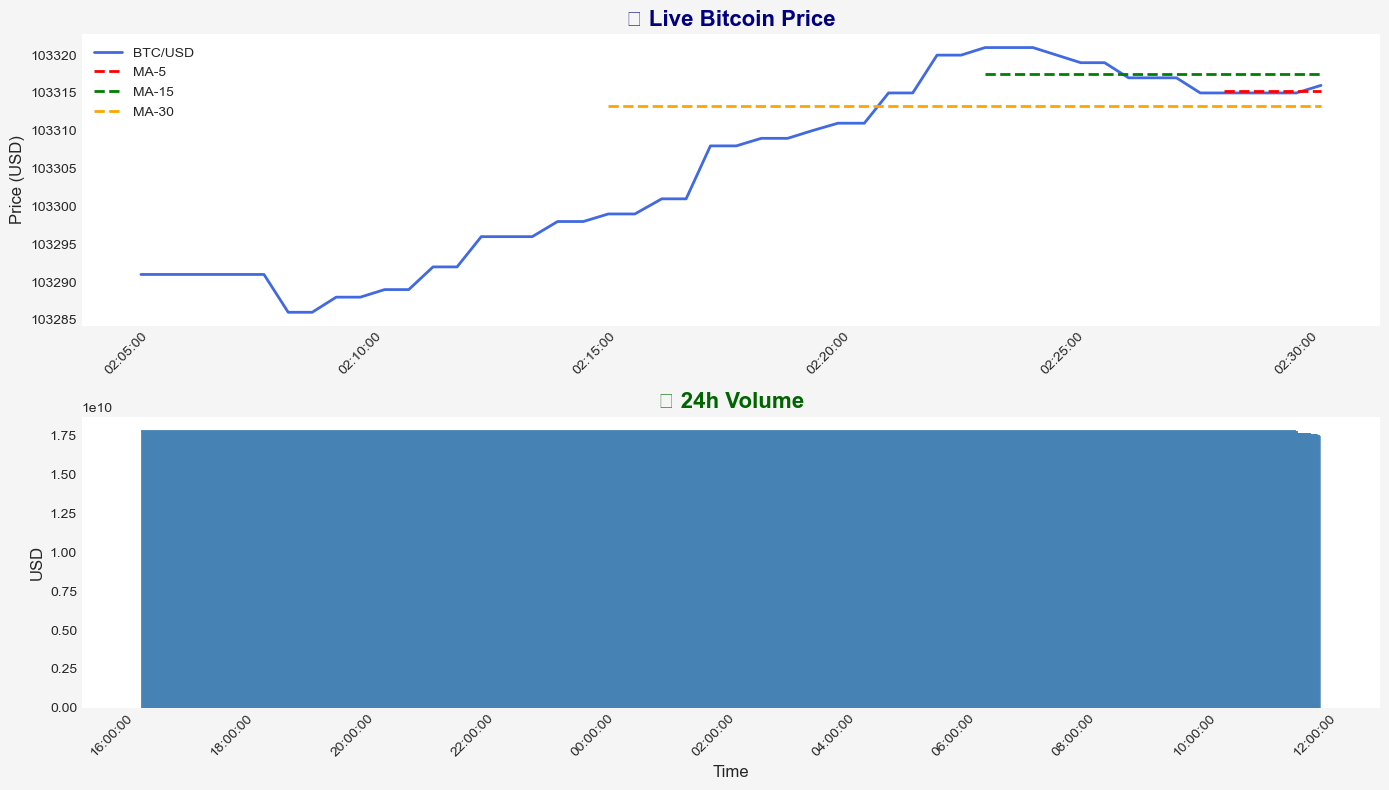


Analysis (2025-05-17 22:30:31)
Current Price: $103,316.00
5-point MA: $103,315.20
15-point MA: $103,317.53
30-point MA: $103,313.30
Volatility: 6.62
[22:30:31] Price: $103,316.00, Volatility: 6.62
[ARIMA Forecast] Next 3 BTC Prices: $103,316.20, $103,316.37, $103,316.51


/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/321638620.py:21: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'recorded_time': datetime.utcnow(),
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:45: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.pause(0.1)
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:45: U

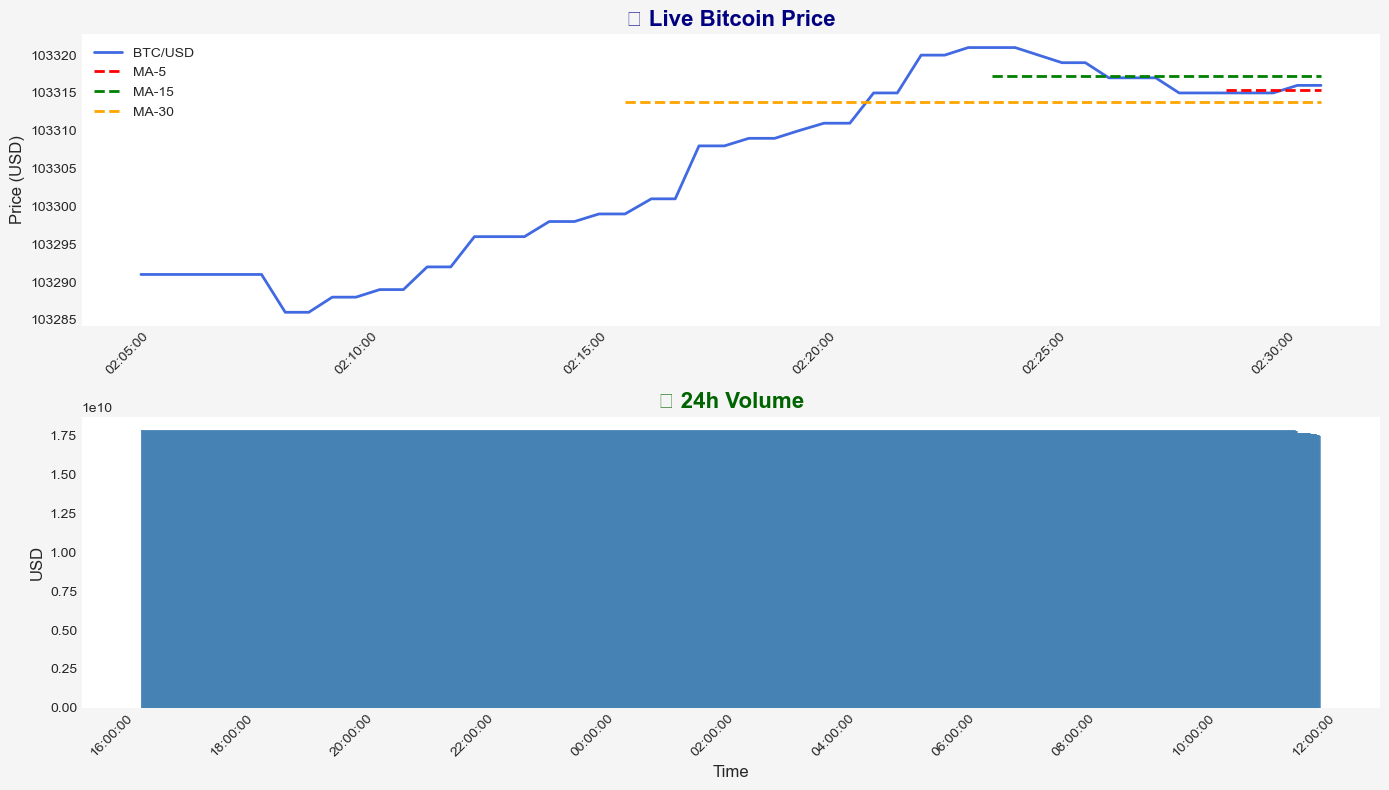


Analysis (2025-05-17 22:31:02)
Current Price: $103,316.00
5-point MA: $103,315.40
15-point MA: $103,317.20
30-point MA: $103,313.87
Volatility: 6.06
[22:31:02] Price: $103,316.00, Volatility: 6.06
[ARIMA Forecast] Next 3 BTC Prices: $103,316.05, $103,316.09, $103,316.11


/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/321638620.py:21: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'recorded_time': datetime.utcnow(),
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:45: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.pause(0.1)
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:45: U

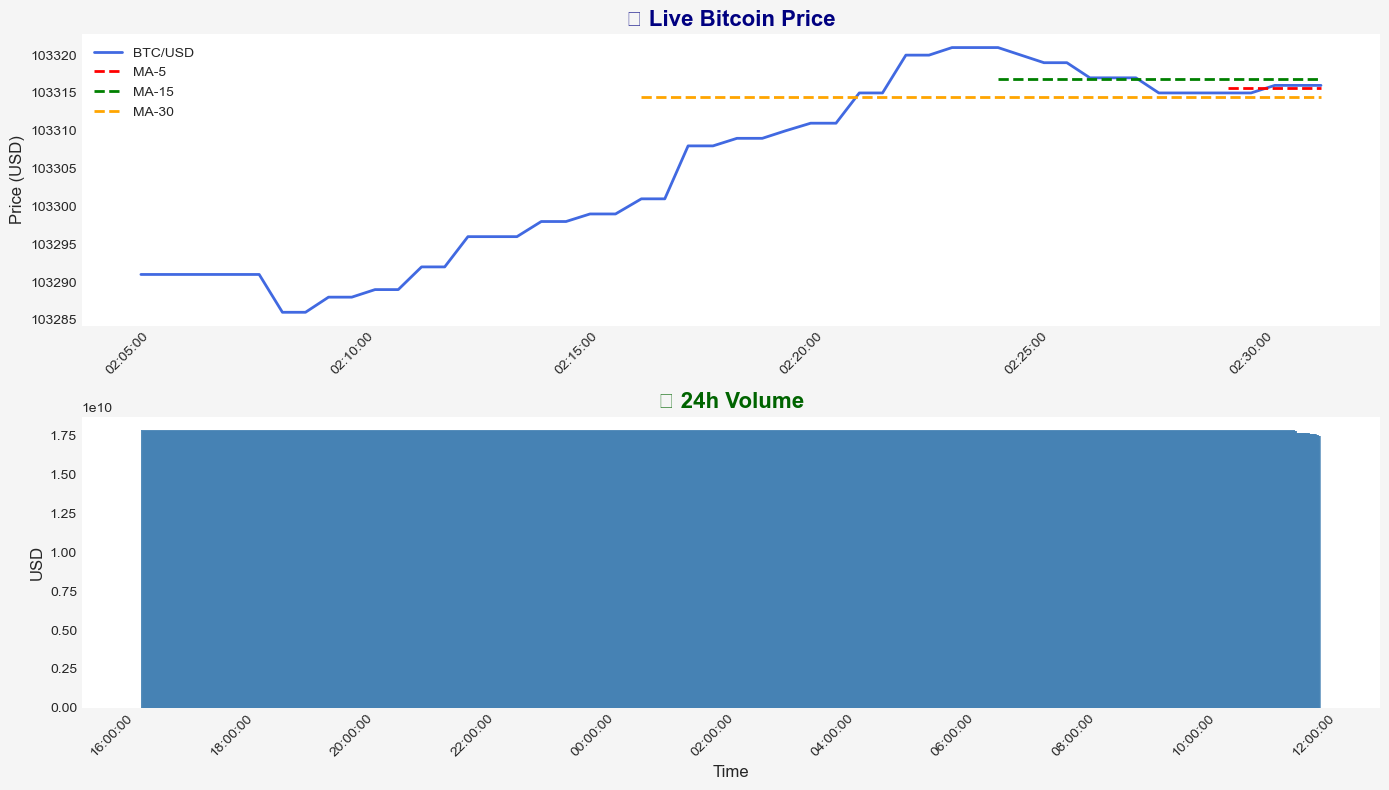


Analysis (2025-05-17 22:31:34)
Current Price: $103,316.00
5-point MA: $103,315.60
15-point MA: $103,316.87
30-point MA: $103,314.43
Volatility: 5.38
[22:31:34] Price: $103,316.00, Volatility: 5.38
[ARIMA Forecast] Next 3 BTC Prices: $103,316.05, $103,316.09, $103,316.11


/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/321638620.py:21: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'recorded_time': datetime.utcnow(),
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:45: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.pause(0.1)
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:45: U

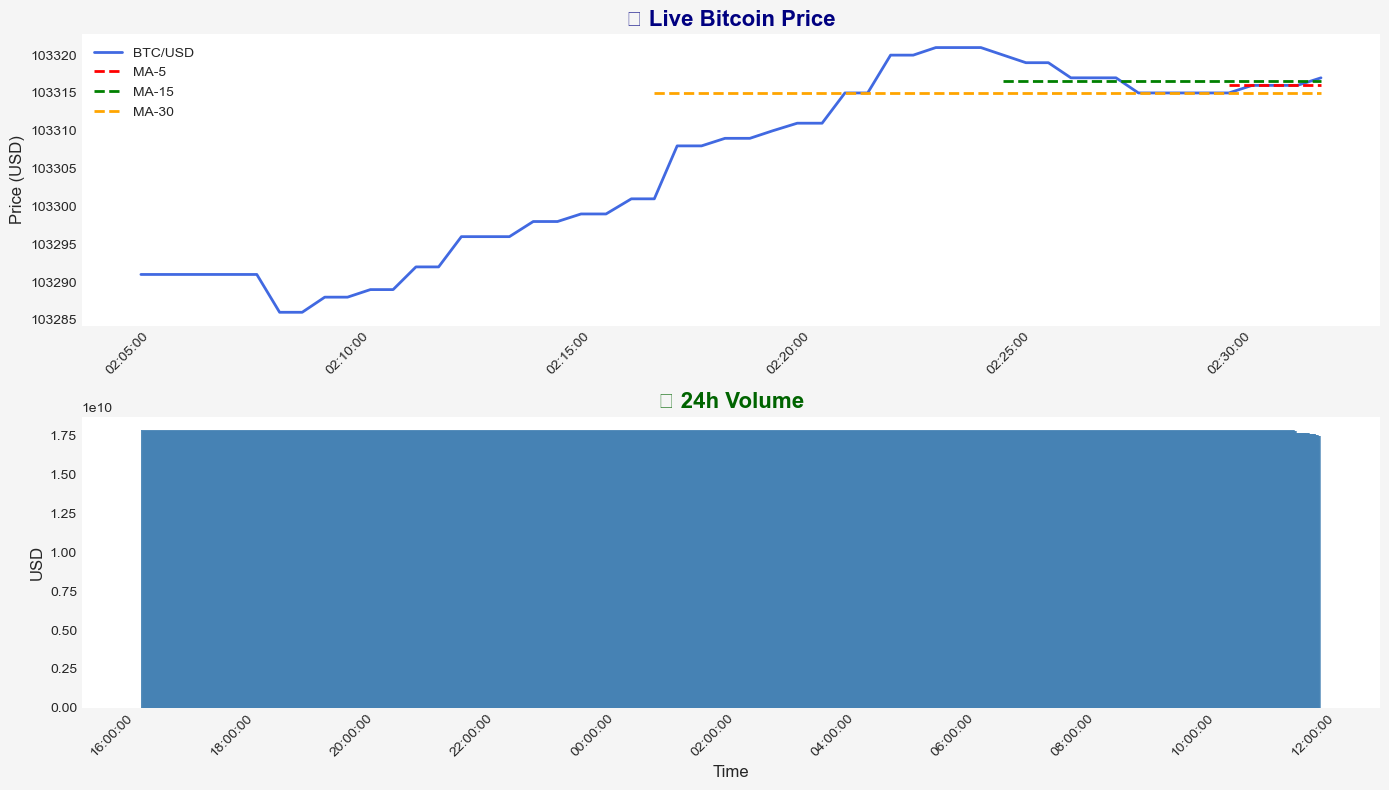


Analysis (2025-05-17 22:32:41)
Current Price: $103,317.00
5-point MA: $103,316.00
15-point MA: $103,316.60
30-point MA: $103,314.97
Volatility: 4.76
[22:32:41] Price: $103,317.00, Volatility: 4.76


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


[ARIMA Forecast] Next 3 BTC Prices: $103,317.17, $103,317.29, $103,317.38


/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/321638620.py:21: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'recorded_time': datetime.utcnow(),
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:45: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.pause(0.1)
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:45: U

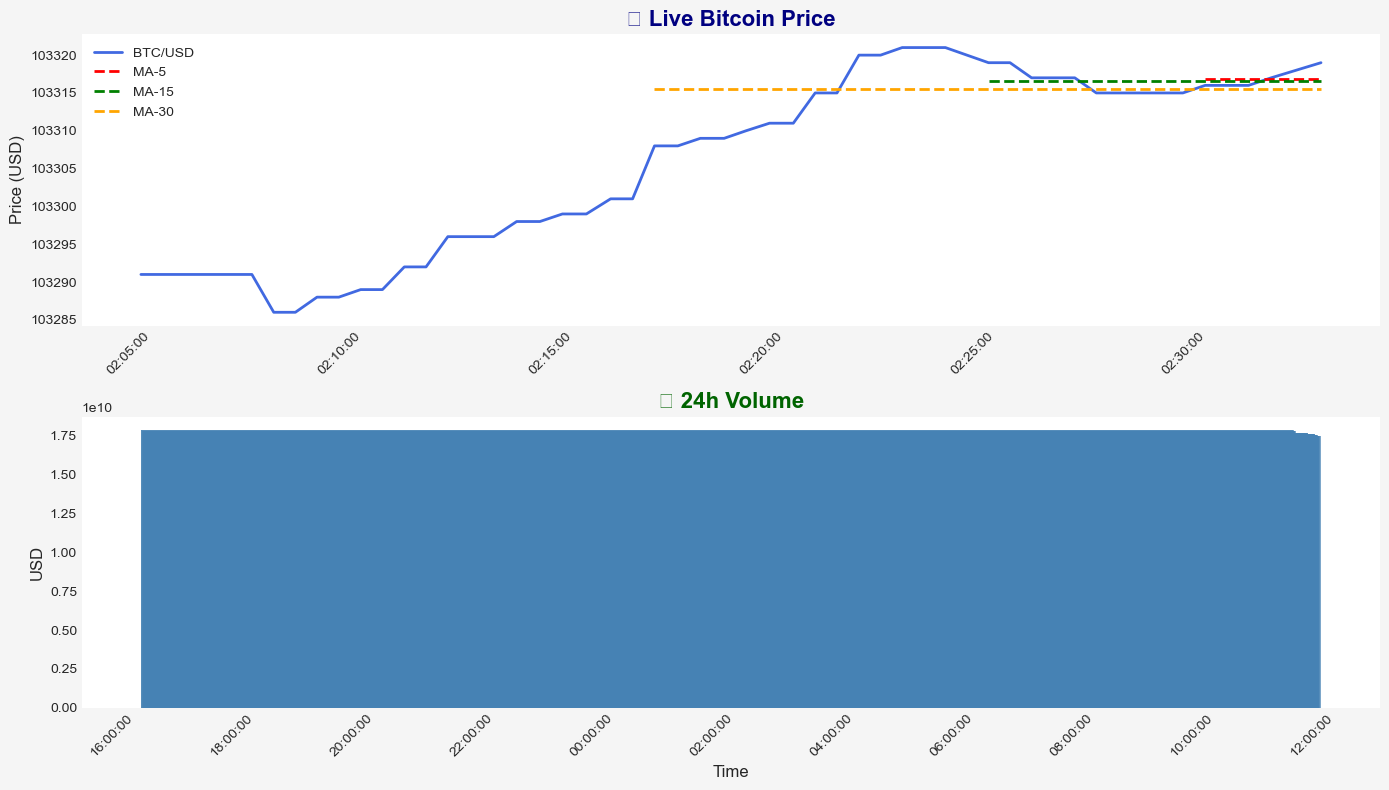


Analysis (2025-05-17 22:33:20)
Current Price: $103,319.00
5-point MA: $103,316.80
15-point MA: $103,316.53
30-point MA: $103,315.57
Volatility: 4.01
[22:33:20] Price: $103,319.00, Volatility: 4.01
[ARIMA Forecast] Next 3 BTC Prices: $103,319.60, $103,320.06, $103,320.41


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/321638620.py:21: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'recorded_time': datetime.utcnow(),
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
/

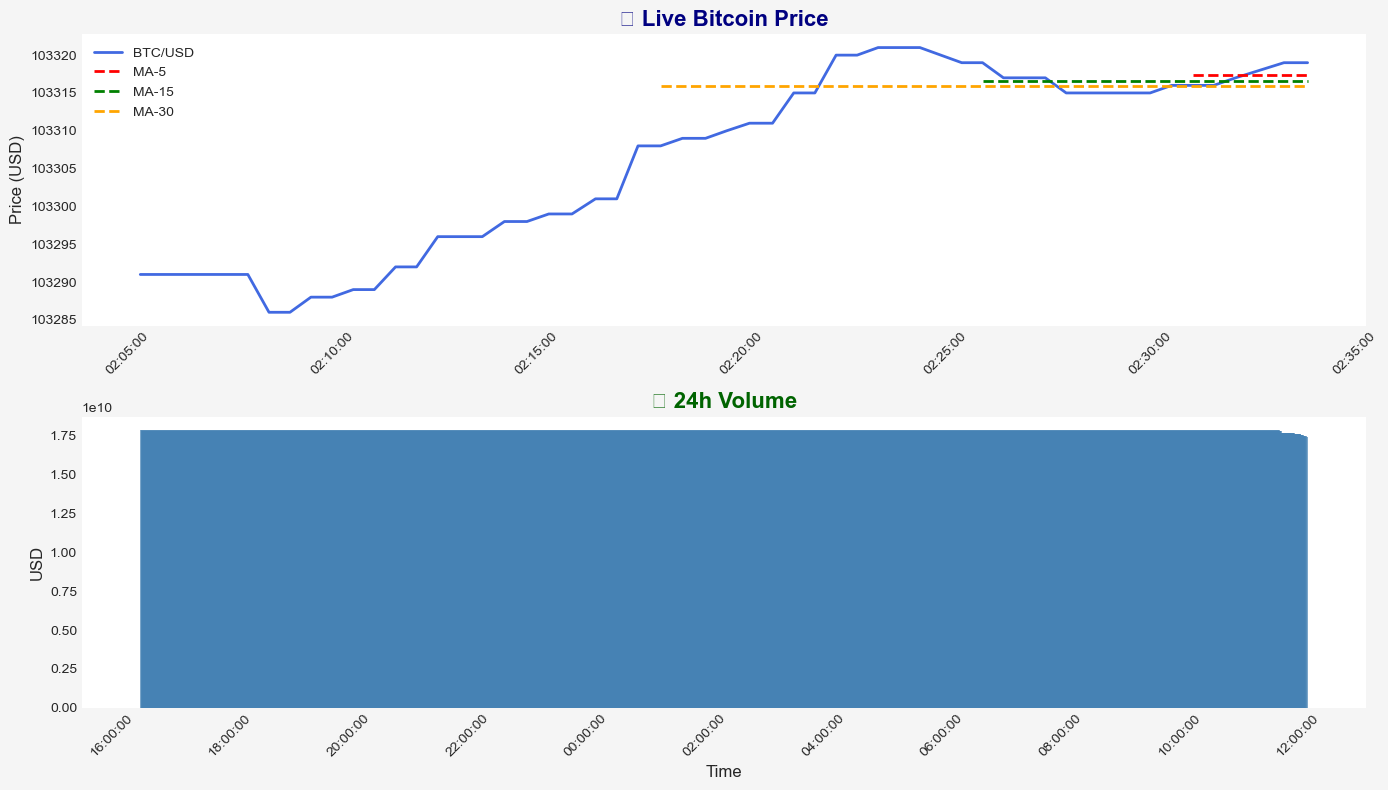


Analysis (2025-05-17 22:33:52)
Current Price: $103,319.00
5-point MA: $103,317.40
15-point MA: $103,316.53
30-point MA: $103,315.93
Volatility: 3.80
[22:33:52] Price: $103,319.00, Volatility: 3.80
[ARIMA Forecast] Next 3 BTC Prices: $103,319.31, $103,319.57, $103,319.78


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/321638620.py:21: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'recorded_time': datetime.utcnow(),
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
/

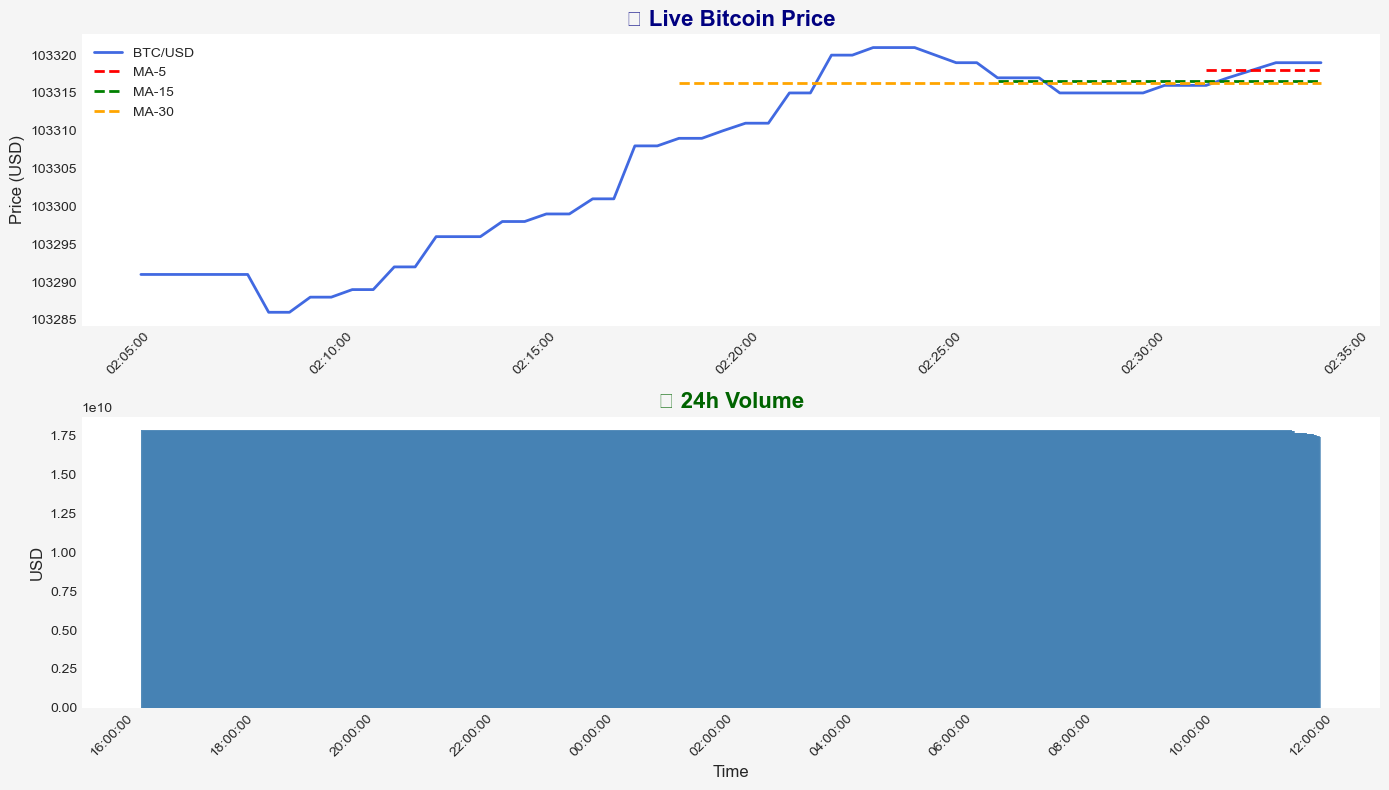


Analysis (2025-05-17 22:34:23)
Current Price: $103,319.00
5-point MA: $103,318.00
15-point MA: $103,316.53
30-point MA: $103,316.30
Volatility: 3.52
[22:34:23] Price: $103,319.00, Volatility: 3.52
[ARIMA Forecast] Next 3 BTC Prices: $103,319.20, $103,319.36, $103,319.49


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/321638620.py:21: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'recorded_time': datetime.utcnow(),
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
/

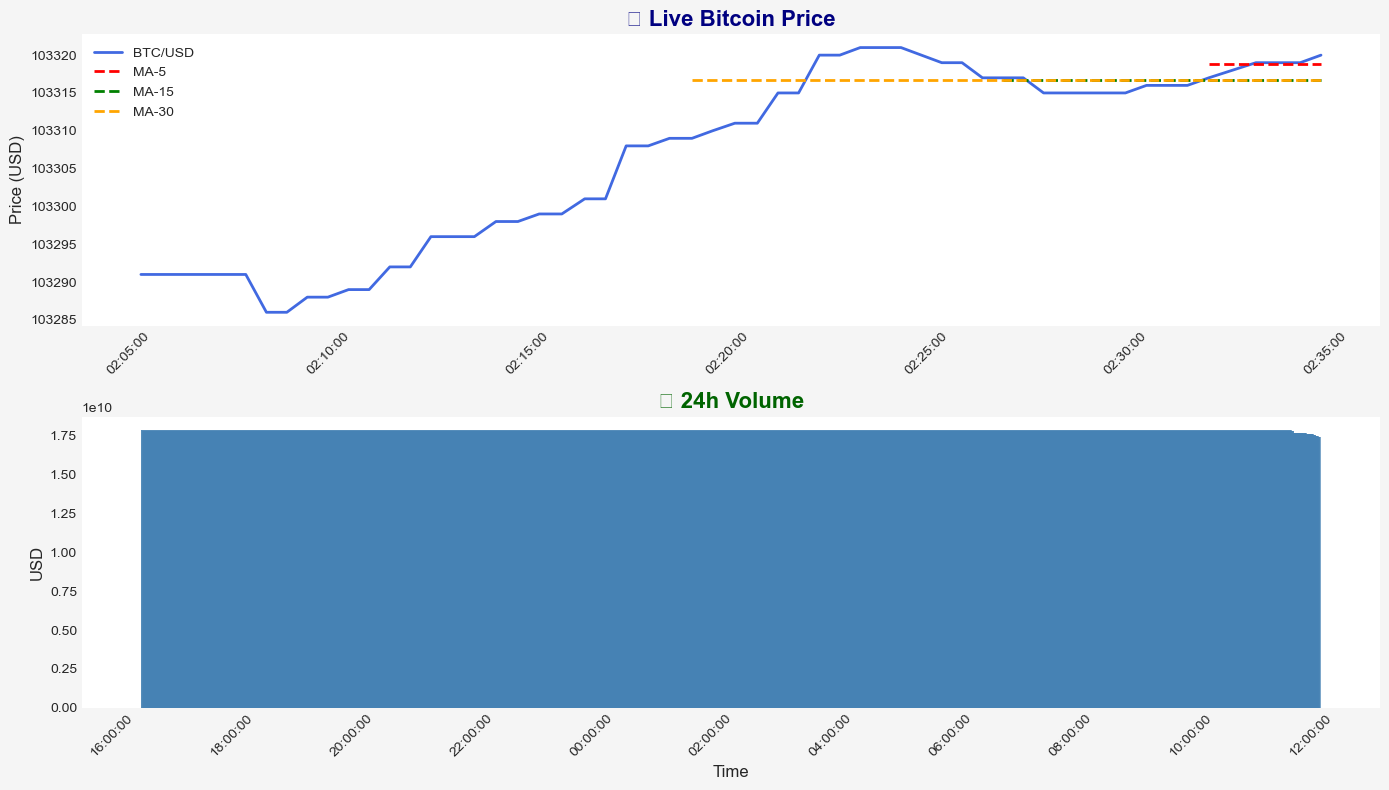


Analysis (2025-05-17 22:34:56)
Current Price: $103,320.00
5-point MA: $103,318.80
15-point MA: $103,316.73
30-point MA: $103,316.67
Volatility: 3.30
[22:34:56] Price: $103,320.00, Volatility: 3.30


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


[ARIMA Forecast] Next 3 BTC Prices: $103,320.37, $103,320.70, $103,320.98


/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/321638620.py:21: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'recorded_time': datetime.utcnow(),
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:45: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.pause(0.1)
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:45: U

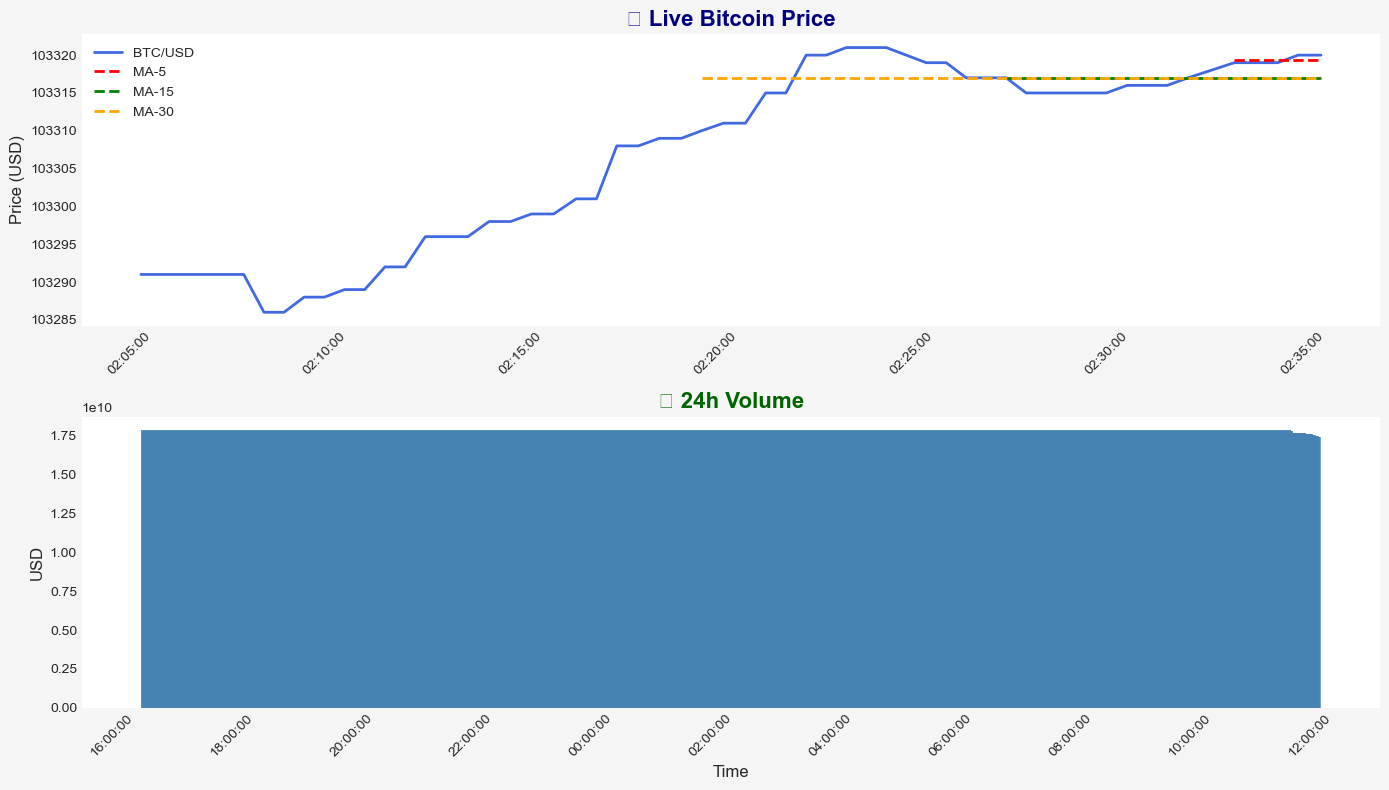


Analysis (2025-05-17 22:35:29)
Current Price: $103,320.00
5-point MA: $103,319.40
15-point MA: $103,316.93
30-point MA: $103,317.03
Volatility: 3.02
[22:35:29] Price: $103,320.00, Volatility: 3.02
[ARIMA Forecast] Next 3 BTC Prices: $103,320.20, $103,320.37, $103,320.51


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/321638620.py:21: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'recorded_time': datetime.utcnow(),
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
/

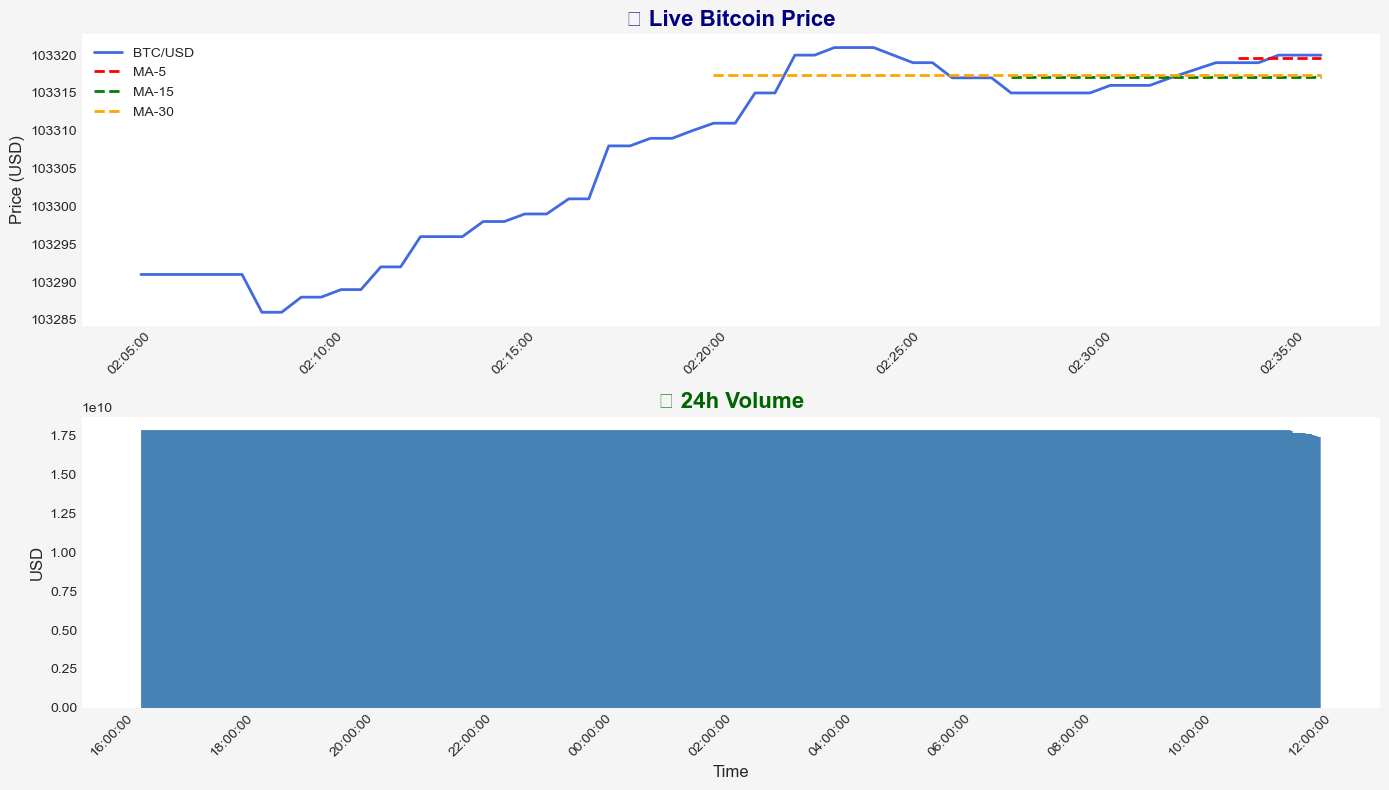


Analysis (2025-05-17 22:36:01)
Current Price: $103,320.00
5-point MA: $103,319.60
15-point MA: $103,317.13
30-point MA: $103,317.37
Volatility: 2.76
[22:36:01] Price: $103,320.00, Volatility: 2.76
[ARIMA Forecast] Next 3 BTC Prices: $103,320.02, $103,320.01, $103,320.01


/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/321638620.py:21: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'recorded_time': datetime.utcnow(),
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:44: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:45: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.pause(0.1)
/var/folders/3k/z99w1gcj7x166lswps2d2mz80000gn/T/ipykernel_92440/3067170445.py:45: U

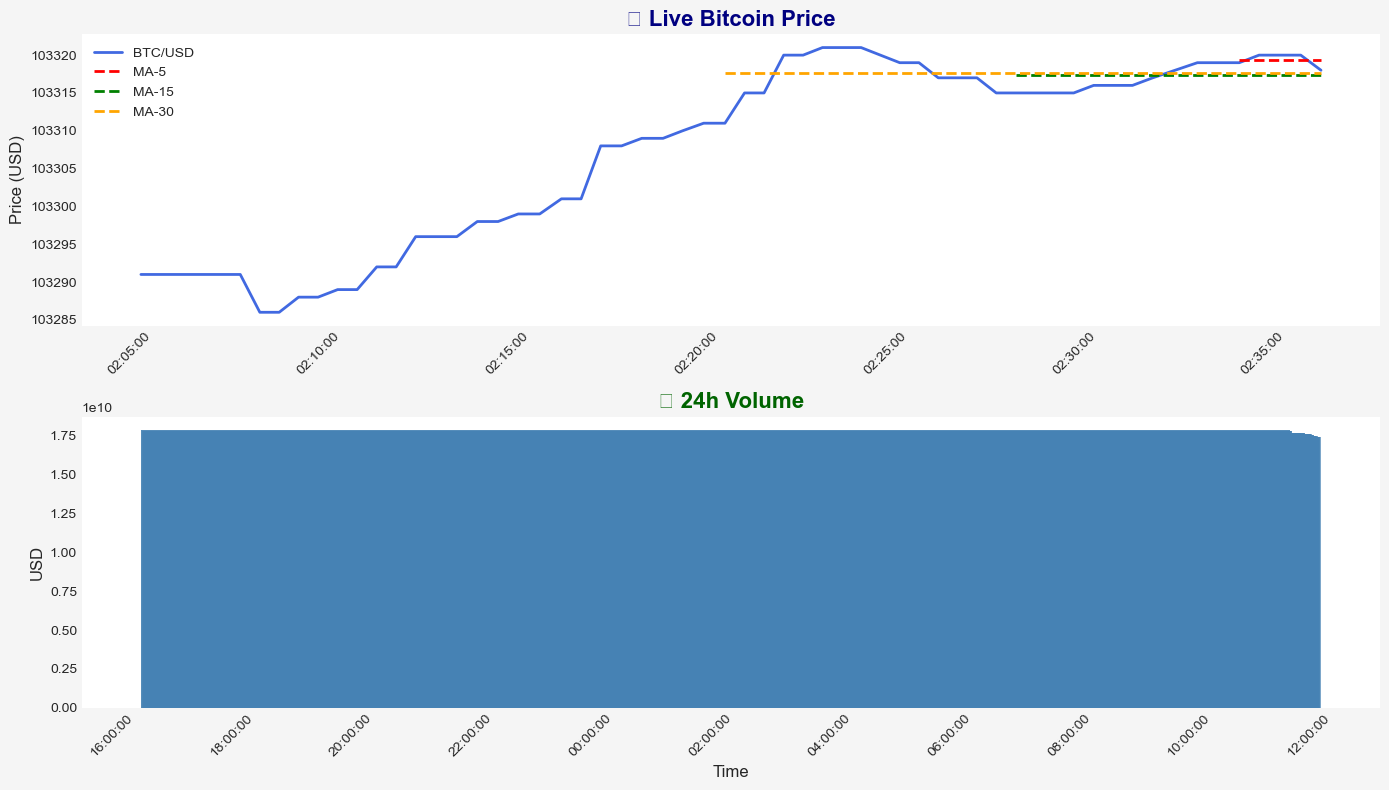


Analysis (2025-05-17 22:36:35)
Current Price: $103,318.00
5-point MA: $103,319.40
15-point MA: $103,317.33
30-point MA: $103,317.60
Volatility: 2.49
[22:36:35] Price: $103,318.00, Volatility: 2.49
[ARIMA Forecast] Next 3 BTC Prices: $103,317.72, $103,317.93, $103,317.77


In [ ]:
try:
    while True:
        datapoint = retrieve_btc_snapshot()
        if datapoint:
            time_marks.append(datapoint['recorded_time'])
            values_usd.append(datapoint['usd_value'])
            volumes_usd.append(datapoint['daily_volume'])
            price_deltas.append(datapoint['pct_shift_24h'])

            if len(values_usd) >= 2:
                ma5 = statistics.mean(values_usd[-5:]) if len(values_usd) >= 5 else values_usd[-1]
                ma15 = statistics.mean(values_usd[-15:]) if len(values_usd) >= 15 else values_usd[-1]
                ma30 = statistics.mean(values_usd[-30:]) if len(values_usd) >= 30 else values_usd[-1]
                vol = statistics.stdev(values_usd[-30:]) if len(values_usd) >= 30 else 0
                pct_chg = ((values_usd[-1] - values_usd[-2]) / values_usd[-2]) * 100

                # Plotting
                plt.clf()
                plt.subplot(2, 1, 1)
                plt.plot(time_marks, values_usd, label='BTC/USD', color='royalblue')
                if len(values_usd) >= 5:
                    plt.plot(time_marks[-5:], [ma5]*5, 'r--', label='MA-5')
                if len(values_usd) >= 15:
                    plt.plot(time_marks[-15:], [ma15]*15, 'g--', label='MA-15')
                if len(values_usd) >= 30:
                    plt.plot(time_marks[-30:], [ma30]*30, 'orange', linestyle='--', label='MA-30')

                plt.title("📈 Live Bitcoin Price", weight='bold', color='navy')
                plt.ylabel("Price (USD)")
                plt.xticks(rotation=45)
                plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
                plt.grid(True, alpha=0.3)
                plt.legend(loc='upper left')

                plt.subplot(2, 1, 2)
                plt.bar(time_marks, volumes_usd, alpha=0.7, color='steelblue')
                plt.title("🔄 24h Volume", weight='bold', color='darkgreen')
                plt.xlabel("Time")
                plt.ylabel("USD")
                plt.xticks(rotation=45)
                plt.grid(True, alpha=0.3)
                plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))

                plt.tight_layout()
                plt.pause(0.1)

                # Print formatted analysis
                print(f"\nAnalysis ({datetime.now().strftime('%Y-%m-%d %H:%M:%S')})")
                print(f"Current Price: ${values_usd[-1]:,.2f}")
                print(f"5-point MA: ${ma5:,.2f}")
                print(f"15-point MA: ${ma15:,.2f}")
                print(f"30-point MA: ${ma30:,.2f}")
                print(f"Volatility: {vol:.2f}")

                # Optional alert
                if abs(pct_chg) > 2:
                    print(f"[ALERT] Price movement > 2%: {pct_chg:.2f}%")


                print(f"[{datetime.now().strftime('%H:%M:%S')}] Price: ${values_usd[-1]:,.2f}, Volatility: {vol:.2f}")
                if abs(pct_chg) > 2:
                    print(f"[ALERT] Price movement > 2%: {pct_chg:.2f}%")

                # ARIMA Forecast
                if len(values_usd) >= 5:
                    series = pd.Series(values_usd[-20:])
                    model = ARIMA(series, order=(1, 1, 1))
                    model_fit = model.fit()
                    forecast = model_fit.forecast(steps=3)
                    print(f"[ARIMA Forecast] Next 3 BTC Prices: ${forecast.iloc[0]:,.2f}, ${forecast.iloc[1]:,.2f}, ${forecast.iloc[2]:,.2f}")


        time.sleep(30)

except KeyboardInterrupt:
    print("Stream terminated.")



## Cell 3 – Real-Time Data Processing, Plotting, and Forecasting

`Fetch Live Data:` Every 60 seconds, the script calls the CoinGecko API and appends the new price, volume, and % change to buffer lists.

`Compute Analytics:` Once enough data is available, it calculates:

`Rolling averages` (MA-5, MA-15, MA-30)

`Volatility` (standard deviation over 30 prices)

% change between latest two prices

Plot in Real-Time:

Line chart with moving averages shows price trends

Bar chart visualizes 24h trading volume

Charts refresh automatically with new data

Console Insights:

Displays live price and volatility

Triggers alerts for sharp price movements (>2%)

Forecasting with ARIMA:
When 20+ data points are available, it builds an ARIMA(1,1,1) model to forecast the next 3 prices.